In [ ]:
import numpy as np
import pandas as pd
import glob

In [ ]:
patterns = ['_619_zr', '_626_zr', '_635_zr']
for pattern in patterns:
    for unmatch_dcat_path in sorted(glob.glob(f'unmatch_dcat_cut*{pattern}*.csv')):
        unmatch_dcat = pd.read_csv(unmatch_dcat_path)
        print(unmatch_dcat_path, unmatch_dcat.shape)

In [ ]:
patterns = ['_000619_zr', '_000626_zr', '_000635_zr']
for pattern in patterns:
    for dcat_cut_path in sorted(glob.glob(f'deconvolved_cut*{pattern}*.csv')):
        dcat_cut = pd.read_csv(dcat_cut_path)
        print(dcat_cut_path, dcat_cut.shape)

In [ ]:
# Ensure unmatch deconvolved sources (after basic selection criteria) are a subset of the deconvolved source catalog (without the basic selection criteria).
_patterns1 = ['_000619_zr', '_000626_zr', '_000635_zr']
_patterns2 = ['_619_zr', '_626_zr', '_635_zr']
for i, _pattern1 in enumerate(_patterns1):
    for dcat_path in sorted(glob.glob(f'deconvolvedztf*{_pattern1}*.csv')):
        dcat = pd.read_csv(dcat_path)

        _pattern2 = _patterns2[i]
        for unmatch_dcat_cut_path in sorted(glob.glob(f'unmatch_dcat_cut*{_pattern2}*.csv')):
            unmatch_dcat_cut = pd.read_csv(unmatch_dcat_cut_path)
            assert len(unmatch_dcat_cut[['X_WORLD', 'Y_WORLD']].merge(dcat[['X_WORLD', 'Y_WORLD']])) == len(unmatch_dcat_cut[['X_WORLD', 'Y_WORLD']])

## Step 1: Cone search with DESI Legacy

In [ ]:
from astropy.io import fits

sci_imgs = [
    'https://irsa.ipac.caltech.edu/ibe/data/ztf/products/sci/2021/0502/476053/ztf_20210502476053_000233_zr_c15_o_q3_sciimg.fits',
    'https://irsa.ipac.caltech.edu/ibe/data/ztf/products/sci/2022/0706/370127/ztf_20220706370127_000829_zr_c10_o_q4_sciimg.fits',
    'https://irsa.ipac.caltech.edu/ibe/data/ztf/products/sci/2023/1021/119745/ztf_20231021119745_000635_zr_c12_o_q4_sciimg.fits',
    'https://irsa.ipac.caltech.edu/ibe/data/ztf/products/sci/2023/0127/346250/ztf_20230127346250_000619_zr_c11_o_q2_sciimg.fits',
    # 'https://irsa.ipac.caltech.edu/ibe/data/ztf/products/sci/2020/0306/404421/ztf_20200306404421_000423_zr_c07_o_q1_sciimg.fits',
    'https://irsa.ipac.caltech.edu/ibe/data/ztf/products/sci/2022/1120/493183/ztf_20221120493183_000626_zr_c12_o_q2_sciimg.fits',
    'https://irsa.ipac.caltech.edu/ibe/data/ztf/products/sci/2021/0220/218785/ztf_20210220218785_000811_zr_c16_o_q4_sciimg.fits',
    'https://irsa.ipac.caltech.edu/ibe/data/ztf/products/sci/2022/0831/366910/ztf_20220831366910_000829_zi_c10_o_q4_sciimg.fits',
    'https://irsa.ipac.caltech.edu/ibe/data/ztf/products/sci/2022/0301/372245/ztf_20220301372245_000626_zi_c12_o_q2_sciimg.fits',
    'https://irsa.ipac.caltech.edu/ibe/data/ztf/products/sci/2022/0901/326748/ztf_20220901326748_000829_zg_c10_o_q4_sciimg.fits',
    'https://irsa.ipac.caltech.edu/ibe/data/ztf/products/sci/2022/1126/507882/ztf_20221126507882_000626_zg_c12_o_q2_sciimg.fits',
    'https://irsa.ipac.caltech.edu/ibe/data/ztf/products/sci/2018/0831/500891/ztf_20180831500891_000251_zr_c16_o_q4_sciimg.fits',
    'https://irsa.ipac.caltech.edu/ibe/data/ztf/products/sci/2019/0629/424757/ztf_20190629424757_000594_zr_c04_o_q1_sciimg.fits'
]

##########
ID = '619'
##########

if ID == '626':
    sci_img = sci_imgs[4]
    assert f'000{ID}' in sci_img
elif ID == '619':
    sci_img = sci_imgs[3]
    assert f'000{ID}' in sci_img
elif ID == '635':
    sci_img = sci_imgs[2]
    assert f'000{ID}' in sci_img
elif ID == '251':
    sci_img = sci_imgs[10]
    assert f'000{ID}' in sci_img

obsjd = fits.open(sci_img)[0].header['OBSJD']
obsjd

In [ ]:
import numpy as np
from astropy.wcs import WCS

for sci_img in sci_imgs:
    if f'000{ID}' not in sci_img:
        continue

    with fits.open(sci_img) as hdul:
        header = hdul[0].header
        data = hdul[0].data

    w = WCS(header)

    ny, nx = data.shape
    center_pixel = [(nx - 1) / 2, (ny - 1) / 2]  # in 0-based coordinates because we work with 0-based coordinates throughout.

    circle_radius_touching_edges = np.sqrt(((nx - 1) / 2)**2 + ((ny - 1) / 2)**2)  # in pixels

    # Convert the center pixel coordinates to sky coordinates (RA, Dec)
    ra_dec = w.wcs_pix2world([center_pixel], 0)[0]
    ra_center, dec_center = ra_dec

    print(sci_img)
    print(ny, nx)
    print(np.round(ra_center, 3), np.round(dec_center, 3))
    # print(header['OBJRAD'], header['OBJDECD'])
    print(circle_radius_touching_edges * 1.012 / 3600)  # in degrees

635:
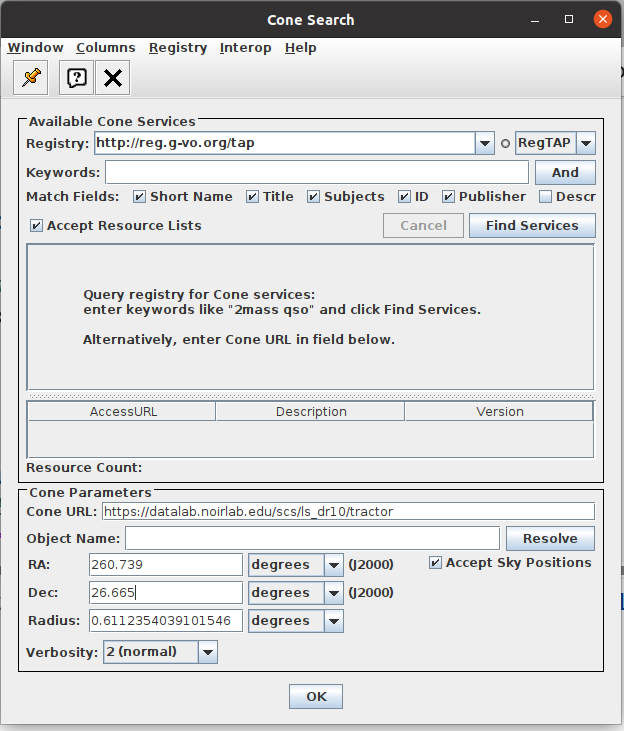

626:
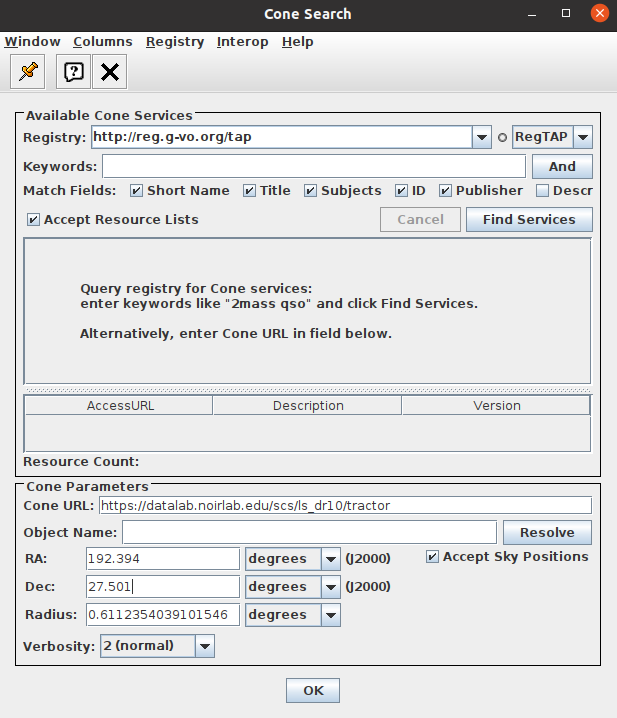

619:
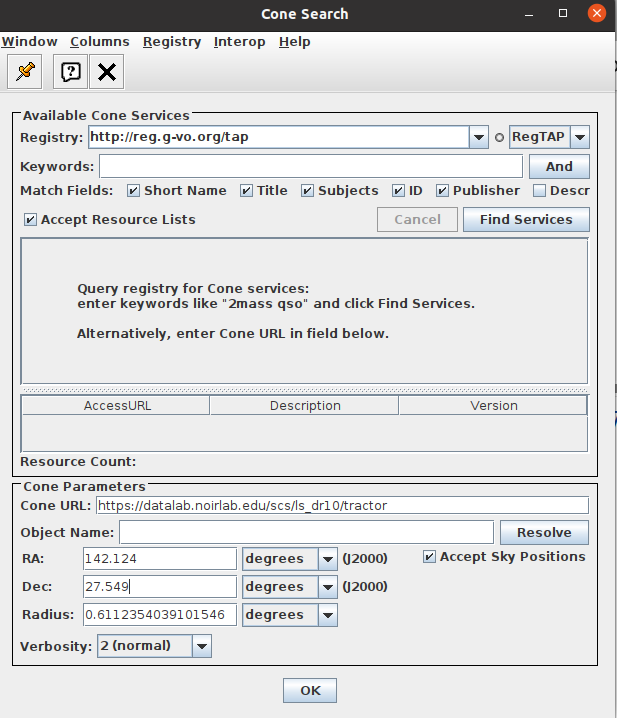

In [ ]:
for desi_legacy_path in glob.glob('desi_legacy_dr10_tractor_*.csv'):
    df = pd.read_csv(desi_legacy_path)
    print(desi_legacy_path, df.shape)

## Step 2: Crossmatch DESI catalogs with unmatched deconvolved sources

In [ ]:
import subprocess

for pattern in patterns:
    # Note: we are working with unmatch_dcat_cut_astrophysical catalogs, not just the unmatch_dcat_cut_astrophysical_faint ones.
    for unmatch_dcat_path in sorted(glob.glob(f'unmatch_dcat_cut_astrophysical{pattern}*.csv')):
        ID = pattern.split('_')[1]
        desi_cat_name = f'desi_legacy_dr10_tractor_{ID}.csv'
        basename = f'desi_unmatch_dcat_cut_astrophysical_{pattern}_{ID}'

        subprocess.run(
            [
                './topcat', '-stilts', 'tmatch2', f'in1={unmatch_dcat_path}', 'ifmt1=csv',
                f'in2={desi_cat_name}', 'ifmt2=csv',
                f'out={basename}_crossmatched_best_match_for_each_table1_row_1_and_2_stilts.csv',
                'matcher=sky', 'values1=X_WORLD Y_WORLD', 'values2=ra dec',
                'join=1and2', 'params=1.8', 'find=best1', 'progress=time'  # 1.399 = 1.383*1.012
            ]
        )

        subprocess.run(
            [
                './topcat', '-stilts', 'tmatch2', f'in1={unmatch_dcat_path}', 'ifmt1=csv',
                f'in2={desi_cat_name}', 'ifmt2=csv',
                f'out={basename}_crossmatched_best_match_for_each_table2_row_1_and_2_stilts.csv',
                'matcher=sky', 'values1=X_WORLD Y_WORLD', 'values2=ra dec',
                'join=1and2', 'params=1.8', 'find=best2', 'progress=time'
            ]
        )

        subprocess.run(
            [
                './topcat', '-stilts', 'tmatch2', f'in1={unmatch_dcat_path}', 'ifmt1=csv',
                f'in2={desi_cat_name}', 'ifmt2=csv',
                f'out={basename}_crossmatched_best_match_symmetric_1_and_2_stilts.csv',
                'matcher=sky', 'values1=X_WORLD Y_WORLD', 'values2=ra dec',
                'join=1and2', 'params=1.8', 'find=best', 'progress=time'
            ]
        )

        subprocess.run(
            [
                './topcat', '-stilts', 'tmatch2', f'in1={unmatch_dcat_path}', 'ifmt1=csv',
                f'in2={desi_cat_name}', 'ifmt2=csv',
                f'out={basename}_crossmatched_all_matches_1_and_2_stilts.csv',
                'matcher=sky', 'values1=X_WORLD Y_WORLD', 'values2=ra dec',
                'join=1and2', 'params=1.8', 'find=all', 'progress=time'
            ]
        )

        subprocess.run(
            [
                './topcat', '-stilts', 'tmatch2', f'in1={unmatch_dcat_path}', 'ifmt1=csv',
                f'in2={desi_cat_name}', 'ifmt2=csv',
                f'out={basename}_crossmatched_best_match_for_each_table1_row_1_not_2_stilts.csv',
                'matcher=sky', 'values1=X_WORLD Y_WORLD', 'values2=ra dec',
                'join=1not2', 'params=1.8', 'find=best1', 'progress=time'
            ]
        )

        subprocess.run(
            [
                './topcat', '-stilts', 'tmatch2', f'in1={unmatch_dcat_path}', 'ifmt1=csv',
                f'in2={desi_cat_name}', 'ifmt2=csv',
                f'out={basename}_crossmatched_best_match_for_each_table2_row_1_not_2_stilts.csv',
                'matcher=sky', 'values1=X_WORLD Y_WORLD', 'values2=ra dec',
                'join=1not2', 'params=1.8', 'find=best2', 'progress=time'
            ]
        )

        subprocess.run(
            [
                './topcat', '-stilts', 'tmatch2', f'in1={unmatch_dcat_path}', 'ifmt1=csv',
                f'in2={desi_cat_name}', 'ifmt2=csv',
                f'out={basename}_crossmatched_best_match_for_each_table2_row_2_not_1_stilts.csv',
                'matcher=sky', 'values1=X_WORLD Y_WORLD', 'values2=ra dec',
                'join=2not1', 'params=1.8', 'find=best2', 'progress=time'
            ]
        )

In [ ]:
import os
def cut_condition(cat):
    # Below taken from https://desitarget.readthedocs.io/en/latest/_modules/desitarget/cuts.html
    # See the function `isSTD`.
    # If we look at the mag histogram of the sources in DESI Legacy but not in deconvolved and if we see sources very faint (e.g., m > 28), then it probably implies we should impose some restriction on SNR here, like SNR>3 OR directly a mag cut, like m < 25 or something similar.
    return (
        (cat['type'] == 'PSF') &
        (cat['fracmasked_g'] < 0.6) & (cat['fracmasked_r'] < 0.6) & (cat['fracmasked_z'] < 0.6) &
        (cat['nobs_g'] > 0) & (cat['nobs_r'] > 0) & (cat['nobs_z'] > 0) &
        (cat['fracflux_g'] < 0.01) & (cat['fracflux_r'] < 0.01) & (cat['fracflux_z'] < 0.01) &
        (cat['flux_ivar_g'] > 0) & (cat['flux_ivar_r'] > 0) & (cat['flux_ivar_z'] > 0)
    )

def dcut_condition(cat):
    # No conditions on deconvolved because we're already working with astrophysical sources.
    return [True] * len(cat)

# def cut_condition2(cat):
#     return (cat['MAG_ISO_2'] >= 15) & (cat['MAG_ISO_2'] <= 20.5) & (cat['FWHM_IMAGE_2'] > 0) & (cat['FWHM_IMAGE_2'] <= 4) & (cat['ELLIPTICITY_2'] < 0.5)

def check_particular_flag(x, nth_bit_from_right=0):
    """Checks whether a particular FLAG corresponding is set or not.
    nth_bit_from_right = 0 means the rightmost bit (0th bit).
    """
    x = int(x)
    return x & (1<<nth_bit_from_right)  # nth_bit_from_right=1 corresponds to 2^1=2.

# NOTE: We also remove sources with FLAGS > 7.
# def clean_catalog_using_flags_condition(cat, colname='FLAGS'):
#     # cond1 = cat[colname].astype(int).apply(func=check_particular_flag, nth_bit_from_right=4).astype(bool)
#     # cond2 = cat[colname].astype(int).apply(func=check_particular_flag, nth_bit_from_right=5).astype(bool)
#     # cond3 = cat[colname].astype(int).apply(func=check_particular_flag, nth_bit_from_right=6).astype(bool)
#     # cond4 = cat[colname].astype(int).apply(func=check_particular_flag, nth_bit_from_right=7).astype(bool)
#     # return (~cond1) & (~cond2) & (~cond3) & (~cond4)
#     return cat[colname] <= 7

# def cut_condition_one_to_one(cat):
#     assert cat['MAG_ISO_2_x'].equals(cat['MAG_ISO_2_y'])
#     assert cat['FWHM_IMAGE_2_x'].equals(cat['FWHM_IMAGE_2_y'])
#     assert cat['ELLIPTICITY_2_x'].equals(cat['ELLIPTICITY_2_y'])
#     return (cat['MAG_ISO_2_x'] >= 15) & (cat['MAG_ISO_2_x'] <= 20.5) & (cat['FWHM_IMAGE_2_x'] >= 0) & (cat['FWHM_IMAGE_2_x'] <= 4) & (cat['ELLIPTICITY_2_x'] < 0.5)

In [ ]:
patterns = ['_619_zr', '_626_zr', '_635_zr']

import shutil
directory = 'final_catalogs_desi_unmatch_dcat_cut'
DIRNAME = './'
if os.path.exists(directory):
    shutil.rmtree(directory)
os.makedirs(directory)

for pattern in patterns:
    for unmatch_dcat_path in sorted(glob.glob(f'unmatch_dcat_cut_astrophysical{pattern}*.csv')):
        ID = pattern.split('_')[1]
        title = ID
        prefix = f'/{ID}'
        desi_cat_name = f'desi_legacy_dr10_tractor_{ID}.csv'
        basename = f'desi_unmatch_dcat_cut_astrophysical_{pattern}_{ID}'
        CROSSMATCH_PREFIX = basename
        SOURCE_CATALOGS = [
            desi_cat_name, unmatch_dcat_path
        ]

        # Remember: In crossmatched catalogs, 1 is deconvolved and 2 means DESI Legacy.
        CROSSMATCHED_CATALOG_best_match_for_each_table2_row_1_and_2 = f'{CROSSMATCH_PREFIX}_crossmatched_best_match_for_each_table2_row_1_and_2_stilts.csv'
        CROSSMATCHED_CATALOG_best_match_for_each_table1_row_1_and_2 = f'{CROSSMATCH_PREFIX}_crossmatched_best_match_for_each_table1_row_1_and_2_stilts.csv'
        CROSSMATCHED_CATALOG_best_match_symmetric_1_and_2 = f'{CROSSMATCH_PREFIX}_crossmatched_best_match_symmetric_1_and_2_stilts.csv'
        CROSSMATCHED_CATALOG_all_matches = f'{CROSSMATCH_PREFIX}_crossmatched_all_matches_1_and_2_stilts.csv'

        CROSSMATCHED_CATALOGS = [
            CROSSMATCHED_CATALOG_best_match_for_each_table2_row_1_and_2,
            CROSSMATCHED_CATALOG_best_match_symmetric_1_and_2,
            CROSSMATCHED_CATALOG_best_match_for_each_table1_row_1_and_2,
            CROSSMATCHED_CATALOG_all_matches
        ]
        CROSSMATCHED_CATALOGS_NAMES = [
            'best_match_for_each_table2_row_1_and_2',
            'best_match_symmetric_1_and_2',
            'best_match_for_each_table1_row_1_and_2',
            'all_matches_1_and_2'
        ]

        CROSSMATCHED_CATALOGS_2_not_1 = f'{CROSSMATCH_PREFIX}_crossmatched_best_match_for_each_table2_row_2_not_1_stilts.csv'
        CROSSMATCHED_CATALOGS_1_not_2 = f'{CROSSMATCH_PREFIX}_crossmatched_best_match_for_each_table1_row_1_not_2_stilts.csv'

        NAMES = [CROSSMATCH_PREFIX] * len(CROSSMATCHED_CATALOGS)

        catname = CROSSMATCHED_CATALOGS
        mcat1 = pd.read_csv(os.path.join(DIRNAME, catname[0]))  # best_match_for_each_table2_row_1_and_2 (Each row from table 2 will appear a maximum of once in the result, but rows from table 1 may appear multiple times.)
        mcat2 = pd.read_csv(os.path.join(DIRNAME, catname[1]))  # best_match_symmetric_1_and_2
        mcat3 = pd.read_csv(os.path.join(DIRNAME, catname[2]))  # best_match_for_each_table1_row_1_and_2 (Each row from table 1 will appear a maximum of once in the result, but rows from table 2 may appear multiple times.)
        # mcat4 is all matches, but that is not used for the plot here.
        mcat4 = pd.read_csv(os.path.join(DIRNAME, catname[3]))  # all_matches

        catname = [CROSSMATCHED_CATALOGS_2_not_1, CROSSMATCHED_CATALOGS_1_not_2, CROSSMATCHED_CATALOGS[2], SOURCE_CATALOGS]
        um_ocat = pd.read_csv(os.path.join(DIRNAME, catname[0]))
        um_dcat = pd.read_csv(os.path.join(DIRNAME, catname[1]))
        ocat = pd.read_csv(os.path.join(DIRNAME, catname[3][0]))
        dcat = pd.read_csv(os.path.join(DIRNAME, catname[3][1]))

        #### Extra preprocessing: adding col1_1-like unique identifier for DESI catalogs.
        # combination of release, brickid and objid is a unique identifier: see https://www.legacysurvey.org/dr10/catalogs/
        ocat['col1_1a'] = ocat[['release', 'brickid', 'objid']].apply(
            lambda x: ','.join(x.dropna().astype(str)),
            axis=1
        )
        um_ocat['col1_1a'] = um_ocat[['release', 'brickid', 'objid']].apply(
            lambda x: ','.join(x.dropna().astype(str)),
            axis=1
        )
        mcat1['col1_1a'] = mcat1[['release', 'brickid', 'objid']].apply(
            lambda x: ','.join(x.dropna().astype(str)),
            axis=1
        )
        mcat2['col1_1a'] = mcat2[['release', 'brickid', 'objid']].apply(
            lambda x: ','.join(x.dropna().astype(str)),
            axis=1
        )
        mcat3['col1_1a'] = mcat3[['release', 'brickid', 'objid']].apply(
            lambda x: ','.join(x.dropna().astype(str)),
            axis=1
        )
        mcat4['col1_1a'] = mcat4[['release', 'brickid', 'objid']].apply(
            lambda x: ','.join(x.dropna().astype(str)),
            axis=1
        )
        ################################################################

        many_to_one = []
        one_to_one1 = []
        for mcat3_col1_1a in mcat3['col1_1a'].unique():
            mcat3_subset = mcat3[mcat3['col1_1a'] == mcat3_col1_1a]
            if len(mcat3_subset) == 1:
                one_to_one1.append(mcat3_subset)
            elif len(mcat3_subset) > 1:
                many_to_one.append(mcat3_subset)
                # one_to_one1.append(mcat3_subset[mcat3_subset['Separation'] == mcat3_subset['Separation'].min()])
    
        one_to_many = []
        one_to_one2 = []
        for mcat1_col1_1 in mcat1['col1_1'].unique():
            mcat1_subset = mcat1[mcat1['col1_1'] == mcat1_col1_1]
            if len(mcat1_subset) == 1:
                one_to_one2.append(mcat1_subset)
            elif len(mcat1_subset) > 1:
                one_to_many.append(mcat1_subset)
                # one_to_one2.append(mcat1_subset[mcat1_subset['Separation'] == mcat1_subset['Separation'].min()])
    
        # one_to_one = pd.merge(pd.concat((one_to_one1)), pd.concat((one_to_one2)), how='inner', on=['X_IMAGE_DBL_2', 'Y_IMAGE_DBL_2', 'X_IMAGE_DBL_1', 'Y_IMAGE_DBL_1'])
    
        one_to_one1 = pd.concat((one_to_one1))
        one_to_one2 = pd.concat((one_to_one2))
        # NOTE: One can use the merge option to create one to one as well, but perhaps the concat followed by removal of duplicates is better suited.
        # one_to_one = pd.merge(one_to_one1, one_to_one2, how='inner', on=['col1_1a', 'col1_1'])
        one_to_one = pd.concat((one_to_one1, one_to_one2)).drop_duplicates(subset=['col1_1a', 'col1_1'])
    
        # assert len(one_to_one) == len(mcat2)  # NOTE: This wouldn't be equal to mcat2 unless we uncomment the below two lines above:
        """
        # one_to_one1.append(mcat3_subset[mcat3_subset['Separation'] == mcat3_subset['Separation'].min()])
        # one_to_one2.append(mcat1_subset[mcat1_subset['Separation'] == mcat1_subset['Separation'].min()])
        """
    
        # many_to_one = pd.DataFrame(np.vstack((many_to_one)))
        # many_to_one.columns = mcat3.columns
        # one_to_many = pd.DataFrame(np.vstack((one_to_many)))
        # one_to_many.columns = mcat1.columns
    
        all_zero_dataframe_indicator_many_to_one = False
        all_zero_dataframe_indicator_one_to_many = False
    
        if len(many_to_one) > 0:
            many_to_one = pd.DataFrame(np.vstack((many_to_one)))
            many_to_one.columns = mcat3.columns
        else:
            _dummy = np.zeros_like(mcat3)
            # _dummy[:] = np.nan
            many_to_one = pd.DataFrame(_dummy)
            many_to_one.columns = mcat3.columns
            all_zero_dataframe_indicator_many_to_one = True
        if len(one_to_many) > 0:
            one_to_many = pd.DataFrame(np.vstack((one_to_many)))
            one_to_many.columns = mcat1.columns
        else:
            _dummy = np.zeros_like(mcat1)
            # _dummy[:] = np.nan
            one_to_many = pd.DataFrame(_dummy)
            one_to_many.columns = mcat1.columns
            all_zero_dataframe_indicator_one_to_many = True
    
        # many_to_one = many_to_one.drop_duplicates(subset=['X_IMAGE_DBL_2', 'Y_IMAGE_DBL_2'])
        # one_to_many = one_to_many.drop_duplicates(subset=['X_IMAGE_DBL_1', 'Y_IMAGE_DBL_1'])
    
        # Initialize the 1-many and many-1 cut dataframes.
        many_to_one_cut = many_to_one.copy(deep=True)
        one_to_many_cut = one_to_many.copy(deep=True)
    
        # For one-to-many and many-to-one, we cannot simply apply the cut conditions since post that, this could become one-to-one.
        # Note that those that are converted from 1-many/many-1 to 1-1 are still not included in 1-1 for simplicity.
        # So we need a slightly modified machinery.
        # First for many-to-one.
        previously_many_to_one_but_not_now = 0
        previously_one_to_many_but_not_now = 0
        for m2o_col1_1a in many_to_one['col1_1a'].unique():
            many_to_one_subset = many_to_one[many_to_one['col1_1a'] == m2o_col1_1a]
            mosc = many_to_one_subset[cut_condition(many_to_one_subset)]
            if len(mosc) < len(many_to_one_subset):  # Then this means one of the matches was removed, so we remove the entire many-1 match.
                # assert one_to_one.shape[1] == many_to_one_subset_cut.shape[1]  # No. of columns must be same.
                # Add it to one-to-one.
                # one_to_one = pd.concat((one_to_one, many_to_one_subset_cut))
                # and remove from many-to-one. But don't directly remove from many_to_one but instead remove from many_to_one_cut.
                many_to_one_cut = many_to_one_cut[many_to_one_cut['col1_1a'] != m2o_col1_1a]
                previously_many_to_one_but_not_now = previously_many_to_one_but_not_now + 1
        # Now for one-to-many.
        for o2m_col1_1 in one_to_many['col1_1'].unique():
            one_to_many_subset = one_to_many[one_to_many['col1_1'] == o2m_col1_1]
            omsc = one_to_many_subset[cut_condition(one_to_many_subset)]
            if len(omsc) < len(one_to_many_subset):  # Then this means one of the matches was removed, so we remove the entire 1-many match.
                # assert one_to_one.shape[1] == one_to_many_subset_cut.shape[1]  # No. of columns must be same.
                # Add it to one-to-one.
                # one_to_one = pd.concat((one_to_one, one_to_many_subset_cut))
                # and remove from one-to-many. But don't directly remove from one_to_many but instead remove from one_to_many_cut.
                one_to_many_cut = one_to_many_cut[one_to_many_cut['col1_1'] != o2m_col1_1]
                previously_one_to_many_but_not_now = previously_one_to_many_but_not_now + 1
    
        ocat_cut = ocat[cut_condition(ocat)]
        # ocat_cut = ocat_cut[clean_catalog_using_flags_condition(ocat_cut)]
        dcat_cut = dcat[dcut_condition(dcat)]
        one_to_one_cut = one_to_one[(cut_condition(one_to_one))]
        # one_to_one_cut = one_to_one_cut[clean_catalog_using_flags_condition(one_to_one_cut, colname='FLAGS_2')]
        # Note that we cannot simply apply the cut conditions as below. See above.
        # many_to_one_cut = many_to_one[cut_condition(many_to_one)]
        # one_to_many_cut = one_to_many[cut_condition(one_to_many)]
        unmatches_original_cut = um_ocat[cut_condition(um_ocat)]; #unmatches_original_cut = unmatches_original_cut[clean_catalog_using_flags_condition(unmatches_original_cut)]
        unmatches_deconvolved_cut = um_dcat[dcut_condition(um_dcat)]

        # We can simply remove based on FLAGS_2 only for many_to_one_cut but not for one_to_many. So we have another for loop below.
        # many_to_one_cut = many_to_one_cut[clean_catalog_using_flags_condition(many_to_one_cut, colname='FLAGS_2')]
        # one_to_many_cut = one_to_many_cut[clean_catalog_using_flags_condition(one_to_many_cut, colname='FLAGS_2')]
        for o2m_col1_1 in one_to_many_cut['col1_1'].unique():
            one_to_many_cut_subset = one_to_many_cut[one_to_many_cut['col1_1'] == o2m_col1_1]
            if (len(one_to_many_cut_subset) % 2) != 0:  # means at least one orig source is removed due to the FLAGS condition, so remove all instances.
                one_to_many_cut = one_to_many_cut[one_to_many_cut['col1_1'] != o2m_col1_1]
                previously_one_to_many_but_not_now = previously_one_to_many_but_not_now + 1
    
        # x = pd.merge(
        #     many_to_one.drop_duplicates(subset=['X_IMAGE_DBL_2', 'Y_IMAGE_DBL_2']),
        #     one_to_one.drop_duplicates(subset=['X_IMAGE_DBL_2', 'Y_IMAGE_DBL_2']),
        #     on=['X_IMAGE_DBL_2', 'Y_IMAGE_DBL_2']
    
        # )
        # y = pd.merge(
        #     many_to_one.drop_duplicates(subset=['X_IMAGE_DBL_2', 'Y_IMAGE_DBL_2']),
        #     one_to_many.drop_duplicates(subset=['X_IMAGE_DBL_2', 'Y_IMAGE_DBL_2']),
        #     on=['X_IMAGE_DBL_2', 'Y_IMAGE_DBL_2']
    
        # )
        # z = pd.merge(
        #     one_to_many.drop_duplicates(subset=['X_IMAGE_DBL_2', 'Y_IMAGE_DBL_2']),
        #     one_to_one.drop_duplicates(subset=['X_IMAGE_DBL_2', 'Y_IMAGE_DBL_2']),
        #     on=['X_IMAGE_DBL_2', 'Y_IMAGE_DBL_2']
    
        # )
    
        # assert one_to_one['col1_1a_x'].equals(one_to_one['col1_1a_y'])
    
        x2 = pd.merge(
            many_to_one.drop_duplicates(subset=['col1_1a']),
            one_to_one.drop_duplicates(subset=['col1_1a']),#.rename(columns={'col1_1a_x': 'col1_1a'}),
            on=['col1_1a']
        )
        y2 = pd.merge(
            many_to_one.drop_duplicates(subset=['col1_1a']),
            one_to_many.drop_duplicates(subset=['col1_1a']),
            on=['col1_1a']
        )
        z2 = pd.merge(
            one_to_many.drop_duplicates(subset=['col1_1a']),
            one_to_one.drop_duplicates(subset=['col1_1a']),#.rename(columns={'col1_1a_x': 'col1_1a'}),
            on=['col1_1a']
        )
        x1 = pd.merge(
            many_to_one.drop_duplicates(subset=['col1_1']),
            one_to_one.drop_duplicates(subset=['col1_1']),#.rename(columns={'col1_1a_x': 'col1_1a'}),
            on=['col1_1']
        )
        y1 = pd.merge(
            many_to_one.drop_duplicates(subset=['col1_1']),
            one_to_many.drop_duplicates(subset=['col1_1']),
            on=['col1_1']
        )
        z1 = pd.merge(
            one_to_many.drop_duplicates(subset=['col1_1']),
            one_to_one.drop_duplicates(subset=['col1_1']),#.rename(columns={'col1_1a_x': 'col1_1a'}),
            on=['col1_1']
        )
        # xyz = pd.merge(
        #     one_to_many.drop_duplicates(subset=['col1_1a']),
        #     one_to_one.drop_duplicates(subset=['col1_1a']),#.rename(columns={'col1_1a_x': 'col1_1a'}),
        #     on=['col1_1a']
        # ).merge(
        #     one_to_one.drop_duplicates(subset=['col1_1a']),
        #     on=['col1_1a']
        # )
    
        w1 = pd.merge(
            one_to_many.drop_duplicates(subset=['col1_1a']),
            um_ocat.rename(columns={'col1': 'col1_1a'}),
            on=['col1_1a']
        )
        w2 = pd.merge(
            one_to_one.drop_duplicates(subset=['col1_1a']),
            um_ocat.rename(columns={'col1': 'col1_1a'}),
            on=['col1_1a']
        )
        w3 = pd.merge(
            many_to_one.drop_duplicates(subset=['col1_1a']),
            um_ocat.rename(columns={'col1': 'col1_1a'}),
            on=['col1_1a']
        )
        assert len(w1) == 0
        assert len(w2) == 0
        assert len(w3) == 0
    
        if not len(ocat) == len(one_to_one) + len(um_ocat) + len(many_to_one['col1_1a'].unique()) + len(one_to_many['col1_1a'].unique()) - (len(x2) + len(y2) + len(z2)):
            print(f"ocat assertion error for {title}\t{len(ocat)} vs. {len(one_to_one) + len(um_ocat) + len(many_to_one['col1_1a'].unique()) + len(one_to_many['col1_1a'].unique()) - (len(x2) + len(y2) + len(z2))}")
        if not len(dcat) == len(one_to_one) + len(um_dcat) + len(many_to_one['col1_1'].unique()) + len(one_to_many['col1_1'].unique()) - (len(x1) + len(y1) + len(z1)):
            print(f"dcat assertion error for {title}\t{len(dcat)} vs. {len(one_to_one) + len(um_dcat) + len(many_to_one['col1_1'].unique()) + len(one_to_many['col1_1'].unique()) - (len(x1) + len(y1) + len(z1))}")
        # print(len(xyz), len(x), len(y), len(z), len(many_to_one['col1_1a'].unique()), len(one_to_many['col1_1a'].unique()), len(um_ocat['col1'].unique()), len(w1), len(w2), len(w3))
    
        ############### Assertion for one to many and many to one matches ###############
        for m2o_col1_1a in many_to_one['col1_1a'].unique():
            many_to_one_subset = many_to_one[many_to_one['col1_1a'] == m2o_col1_1a]
            assert len(many_to_one_subset) > 1
    
        for o2m_col1_1 in one_to_many['col1_1'].unique():
            one_to_many_subset = one_to_many[one_to_many['col1_1'] == o2m_col1_1]
            assert len(one_to_many_subset) > 1
        #################################################################################
        ############### Assertion for one to one matches ###############
        assert len(one_to_one['col1_1']) == len(one_to_one['col1_1'].unique())
        assert len(one_to_one['col1_1a']) == len(one_to_one['col1_1a'].unique())
        ################################################################
    
        #################################################################################

        #################################################################################
        # Extra processing
        # Since we extract DESI Legacy sources in a circular region touching the rectangle images,
        # here we exclude those sources outside the rectangle but inside the circle.
        # For this, we perform direct cuts based on min and max ra and dec of the rectangle image corners.
        # This is done for both types of catalogs: with and without the cuts.

        # First, get the science image
        if ID == '626':
            sci_img = sci_imgs[4]
            assert f'000{ID}' in sci_img
        elif ID == '619':
            sci_img = sci_imgs[3]
            assert f'000{ID}' in sci_img
        elif ID == '635':
            sci_img = sci_imgs[2]
            assert f'000{ID}' in sci_img
        elif ID == '251':
            sci_img = sci_imgs[10]
            assert f'000{ID}' in sci_img

        with fits.open(sci_img) as hdul:
            header = hdul[0].header
            data = hdul[0].data

        w = WCS(header)

        ny, nx = data.shape
        center_pixel = [(nx - 1) / 2, (ny - 1) / 2]  # in 0-based coordinates because we work with 0-based coordinates throughout.

        # Convert the center pixel coordinates to sky coordinates (RA, Dec)
        ra_dec = w.wcs_pix2world([center_pixel], 0)[0]
        ra_center, dec_center = ra_dec

        # Define the rectangle region.
        from astropy.coordinates import SkyCoord
        from astropy import units as u

        center = SkyCoord(ra=ra_center * u.deg, dec=dec_center * u.deg, frame='icrs')

        # Convert width and height from arcseconds to degrees
        width = (nx - 1) * 1.012
        height = (ny - 1) * 1.012
        width_deg = (width / 3600.0)
        height_deg = (height / 3600.0)
        d_ra = width_deg / 2.0
        d_dec = height_deg / 2.0

        # Calculate corner coordinates
        top_left = center.spherical_offsets_by(-d_ra * u.deg, d_dec * u.deg)
        top_right = center.spherical_offsets_by(d_ra * u.deg, d_dec * u.deg)
        bottom_left = center.spherical_offsets_by(-d_ra * u.deg, -d_dec * u.deg)
        bottom_right = center.spherical_offsets_by(d_ra * u.deg, -d_dec * u.deg)

        # Perform ra, dec cuts
        def ra_dec_filter_catalog(catalog, ra_min, ra_max, dec_min, dec_max):
            """Filters a catalog using ra and dec bounds."""
            filtered_catalog = catalog[
                (catalog["ra"] >= ra_min) & (catalog["ra"] <= ra_max) &
                (catalog["dec"] >= dec_min) & (catalog["dec"] <= dec_max)
            ]
            print(f'{len(filtered_catalog)}/{len(catalog)} rows remaining after (ra, dec) cuts')

            return filtered_catalog

        ocat = ra_dec_filter_catalog(ocat, bottom_left.ra.deg, top_right.ra.deg, bottom_left.dec.deg, top_right.dec.deg)
        one_to_one = ra_dec_filter_catalog(one_to_one, bottom_left.ra.deg, top_right.ra.deg, bottom_left.dec.deg, top_right.dec.deg)
        many_to_one = ra_dec_filter_catalog(many_to_one, bottom_left.ra.deg, top_right.ra.deg, bottom_left.dec.deg, top_right.dec.deg)
        one_to_many = ra_dec_filter_catalog(one_to_many, bottom_left.ra.deg, top_right.ra.deg, bottom_left.dec.deg, top_right.dec.deg)
        um_ocat = ra_dec_filter_catalog(um_ocat, bottom_left.ra.deg, top_right.ra.deg, bottom_left.dec.deg, top_right.dec.deg)

        ocat_cut = ra_dec_filter_catalog(ocat_cut, bottom_left.ra.deg, top_right.ra.deg, bottom_left.dec.deg, top_right.dec.deg)
        one_to_one_cut = ra_dec_filter_catalog(one_to_one_cut, bottom_left.ra.deg, top_right.ra.deg, bottom_left.dec.deg, top_right.dec.deg)
        many_to_one_cut = ra_dec_filter_catalog(many_to_one_cut, bottom_left.ra.deg, top_right.ra.deg, bottom_left.dec.deg, top_right.dec.deg)
        one_to_many_cut = ra_dec_filter_catalog(one_to_many_cut, bottom_left.ra.deg, top_right.ra.deg, bottom_left.dec.deg, top_right.dec.deg)
        unmatches_original_cut = ra_dec_filter_catalog(unmatches_original_cut, bottom_left.ra.deg, top_right.ra.deg, bottom_left.dec.deg, top_right.dec.deg)

        #################################################################################

        #################### SAVE CATALOGS #############################################################################
        ocat.to_csv(os.path.join(directory, 'desi' + prefix.split('/')[-1] + '.csv'))
        dcat.to_csv(os.path.join(directory, 'deconvolved' + prefix.split('/')[-1] + '.csv'))
        one_to_one.to_csv(os.path.join(directory, 'one_to_one' + prefix.split('/')[-1] + '.csv'))
        many_to_one.to_csv(os.path.join(directory, 'many_to_one' + prefix.split('/')[-1] + '.csv'))
        one_to_many.to_csv(os.path.join(directory, 'one_to_many' + prefix.split('/')[-1] + '.csv'))
        um_ocat.to_csv(os.path.join(directory, 'unmatches_desi' + prefix.split('/')[-1] + '.csv'))
        um_dcat.to_csv(os.path.join(directory, 'unmatches_deconvolved' + prefix.split('/')[-1] + '.csv'))

        ocat_cut.to_csv(os.path.join(directory, 'desi_cut_' + prefix.split('/')[-1] + '.csv'))
        dcat_cut.to_csv(os.path.join(directory, 'deconvolved_cut_' + prefix.split('/')[-1] + '.csv'))
        one_to_one_cut.to_csv(os.path.join(directory, 'one_to_one_cut_' + prefix.split('/')[-1] + '.csv'))
        many_to_one_cut.to_csv(os.path.join(directory, 'many_to_one_cut_' + prefix.split('/')[-1] + '.csv'))
        one_to_many_cut.to_csv(os.path.join(directory, 'one_to_many_cut_' + prefix.split('/')[-1] + '.csv'))
        unmatches_original_cut.to_csv(os.path.join(directory, 'unmatches_desi_cut_' + prefix.split('/')[-1] + '.csv'))
        unmatches_deconvolved_cut.to_csv(os.path.join(directory, 'unmatches_deconvolved_cut_' + prefix.split('/')[-1] + '.csv'))
        ################################################################################################################

        print(
            f"{prefix.split('/')[-1]}, {len(ocat)} ({len(ocat_cut)}), {len(dcat)} ({len(dcat_cut)}), {len(one_to_one)} ({len(one_to_one_cut)}), {len(many_to_one)} ({len(many_to_one_cut)}), {len(one_to_many)} ({len(one_to_many_cut)}), {len(um_ocat)} ({len(unmatches_original_cut)}), {len(um_dcat)} ({len(unmatches_deconvolved_cut)})"
        )
        one_to_many_vc = one_to_many_cut['col1_1'].value_counts()
        print(f'1-many: two matches = {len(one_to_many_vc[one_to_many_vc == 2])}, three matches = {len(one_to_many_vc[one_to_many_vc == 3])}, four matches = {len(one_to_many_vc[one_to_many_vc == 4])}')
        many_to_one_vc = many_to_one_cut['col1_1a'].value_counts()
        print(f'many-1: two matches = {len(many_to_one_vc[many_to_one_vc == 2])}, three matches = {len(many_to_one_vc[many_to_one_vc == 3])}, four matches = {len(many_to_one_vc[many_to_one_vc == 4])}')

## Step 3: Make some plots analyzing crossmatches between deconvolved and DESI Legacy

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('ticks')
sns.set_context('paper')  # change to 'paper' later.

# import scienceplots
# plt.style.use('science')

gen_gt_color = '#FC9272'
ip_gt_color = '#1C9099'
ip_gen_color = '#2ca25f'

ticklabelsize = 26
axeslabelsize = 27
titlesize = 30

linewidth = 4

### Step 3.1 Crossmatch DESI catalogs with only unmatched deconvolved sources

In [ ]:
patterns = ['_619_zr', '_626_zr', '_635_zr']
directory = 'final_catalogs_desi_unmatch_dcat_cut'
DIRNAME = './'
_fig_number = 0

directory_plots = 'final_catalogs_for_plots'
os.makedirs(directory_plots, exist_ok=True)

for pattern in patterns:
    for unmatch_dcat_path in sorted(glob.glob(f'unmatch_dcat_cut_astrophysical{pattern}*.csv')):
        ID = pattern.split('_')[1]
        title = ID
        prefix = f'/{ID}'
        desi_cat_name = f'desi_legacy_dr10_tractor_{ID}.csv'
        basename = f'desi_unmatch_dcat_cut_astrophysical_{pattern}_{ID}'
        CROSSMATCH_PREFIX = basename
        SOURCE_CATALOGS = [
            desi_cat_name, unmatch_dcat_path
        ]

        one_to_one = pd.read_csv(os.path.join(directory, f'one_to_one{ID}.csv'))
        one_to_one_cut = pd.read_csv(os.path.join(directory, f'one_to_one_cut_{ID}.csv'))
        unmatch_dcat_cut = pd.read_csv(os.path.join(directory, f'unmatches_deconvolved_cut_{ID}.csv'))
        unmatches_desi_cut = pd.read_csv(os.path.join(directory, f'unmatches_desi_cut_{ID}.csv'))

        # FINAL SAVE
        one_to_one_cut.to_csv(f'./final_catalogs_for_plots/one_to_one_cut_Dastrophysical_LS_notin_O_{ID}.csv')
        one_to_one.to_csv(f'./final_catalogs_for_plots/one_to_one_Dastrophysical_LS_notin_O_{ID}.csv')

        print(f'No. of 1-1 matches with dcut_astrophysical but no desi cuts: {len(one_to_one)}')
        one_to_many = pd.read_csv(os.path.join(directory, f'one_to_many{ID}.csv'))
        many_to_one = pd.read_csv(os.path.join(directory, f'many_to_one{ID}.csv'))
        print(f'No. of 1-many matches with dcut_astrophysical but no desi cuts: {len(one_to_many)}')
        print(f'No. of many-1 matches with dcut_astrophysical but no desi cuts: {len(many_to_one)}')

        fig, ax = plt.subplots(2, 1, figsize=(5, 5), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
        fig.subplots_adjust(hspace=0)
        ax[0].scatter(one_to_one_cut['mag_r'], one_to_one_cut['MAG_ISO'])
        _extent = [one_to_one_cut['mag_r'].min(), one_to_one_cut['mag_r'].max()]
        ax[0].plot(_extent, _extent, linestyle='--')
        ax[1].set_xlabel('mag_r [DESI Legacy]')
        ax[0].set_ylabel('mag_iso_r [ZTF]')
        ax[0].set_title(f'[Fig. 3.1.{_fig_number}]: 1-1 matches ID: {ID}'); _fig_number += 1
        ax[1].scatter(one_to_one_cut['mag_r'], one_to_one_cut['mag_r'] - one_to_one_cut['MAG_ISO'])
        ax[1].set_ylabel('mag_r - mag_iso_r')
        ax[1].axhline(y=0, linestyle='--')
        plt.text(
            0.75, 0.75, f'{len(one_to_one_cut["MAG_ISO"])} sources',
            ha='right', va='top',
            transform = ax[0].transAxes
        )
        plt.show()

        fig, ax = plt.subplots(1, 1, figsize=(5, 5))
        ax.scatter(one_to_one_cut['psfsize_r'], one_to_one_cut['FWHM_IMAGE']*1.012)
        ax.set_xlabel('psf_size_r [DESI Legacy]')
        ax.set_ylabel('fwhm_r [ZTF]')
        ax.set_title(f'[Fig. 3.1.{_fig_number}]: 1-1 matches ID: {ID}'); _fig_number += 1
        plt.show()

        fig, ax = plt.subplots(1, 1, figsize=(5, 5))
        ax.hist(one_to_one_cut['Separation'])
        ax.set_xlabel('separation (arcsec)')
        ax.set_ylabel('counts')
        ax.set_title(f'[Fig. 3.1.{_fig_number}]: 1-1 matches ID: {ID}'); _fig_number += 1
        plt.show()

        fig, ax = plt.subplots(1, 1, figsize=(5, 5))
        ax.hist(unmatch_dcat_cut['MAG_ISO'])
        ax.set_xlabel('mag_iso_r [ZTF]')
        ax.set_ylabel('counts')
        plt.text(
            0.75, 0.75, f'{len(unmatch_dcat_cut["MAG_ISO"])} sources',
            ha='right', va='top',
            transform = ax.transAxes
        )
        ax.set_title(f'[Fig. 3.1.{_fig_number}]: Unmatched deconvolved ID: {ID}'); _fig_number += 1
        plt.show()

        # FINAL SAVE
        unmatch_dcat_cut.to_csv(f'./final_catalogs_for_plots/in_D_notin_LS_O_{ID}.csv')

        # This histogram might show sources with a wide range of mag, including the bright ones.
        # The presence of bright ones isn't a problem because we only consider those deconvolved sources unmatched with science image, not the full catalog of deconvolved sources.
        # The presence of faint ones also may not be a problem because it's possible those were matched to a source in the science image, so those obviously wouldn't be in the set of deconvolved sources considered here and hence cannot be matched to a DESI Legacy source.
        # One could consider the full set of deconvolved sources (not just those unmatched with science) - in that case, crossmatch with DESI Legacy again, save the resulting catalogs, and make a plot here.
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))

        # Sometimes gave "ValueError: supplied range of [0.0, inf] is not finite"
        # But I'm bypassing it.
        try:
            ax.hist(unmatches_desi_cut['mag_r'])
        except:
            pass
        ax.set_xlabel('mag_r [DESI Legacy]')
        ax.set_ylabel('counts')
        ax.set_yscale('log')
        plt.text(
            0.75, 0.75, f'{len(unmatches_desi_cut["mag_r"])} sources\n{len(unmatches_desi_cut[unmatches_desi_cut["mag_r"] < 24])} sources with m < 24\n{len(unmatches_desi_cut[unmatches_desi_cut["mag_r"] < 21.5])} sources with m < 21.5',
            ha='right', va='top',
            transform = ax.transAxes
        )
        ax.set_title(f'[Fig. 3.1.{_fig_number}]: Unmatched DESI Legacy ID: {ID}'); _fig_number += 1
        plt.show()

        # Comparing properties of deconvolved sources matched and unmatched with DESI Legacy.
        for property in ['MAG_ISO', 'FWHM_IMAGE', 'ELLIPTICITY']:
            fig, ax = plt.subplots(1, 1, figsize=(5, 5))
            ax.hist(unmatch_dcat_cut[property], histtype='step', color='black', label='unmatch')
            ax.hist(one_to_one_cut[property], histtype='step', color='blue', label='1-1 match')
            ax.set_xlabel(f'{property}_r [ZTF]')
            ax.set_ylabel('counts')
            ax.set_yscale('log')
            ax.legend()
            ax.axvline(x=np.median(unmatch_dcat_cut[property]), linestyle='--', color='black')
            ax.axvline(x=np.median(one_to_one_cut[property]), linestyle='--', color='blue')
            ax.set_title(f'[Fig. 3.1.{_fig_number}]: 1-1 matches vs. Unmatched deconvolved ID: {ID}'); _fig_number += 1
            plt.show()

        # Color-Magnitude diagram.
        # See an example plot here: https://allendowney.github.io/AstronomicalData/06_photo.html
        # The choice of g-r and r-z is because it's in https://academic.oup.com/mnras/article/536/3/2260/7919747
        fig, ax = plt.subplots(1, 2, figsize=(10, 5))
        ax[0].scatter(one_to_one_cut['mag_g'] - one_to_one_cut['mag_r'], one_to_one_cut['mag_g'])
        ax[1].scatter(one_to_one_cut['mag_r'] - one_to_one_cut['mag_z'], one_to_one_cut['mag_r'])
        ax[0].set_xlabel('mag_g - mag_r [DESI Legacy]')
        ax[1].set_xlabel('mag_r - mag_z [DESI Legacy]')
        ax[0].set_ylabel('mag_g [DESI Legacy]')
        ax[1].set_ylabel('mag_r [DESI Legacy]')

        for a in ax:
            a.set_title(f'[Fig. 3.1.{_fig_number}]: CMD for 1-1 matches ID: {ID}'); _fig_number += 1

        plt.show()

<!--
# todo: WOULD PLOTTING MAG_ISO VS. COLOR OF SOURCES FROM DESI LEGACY BE USEFUL? WHAT ABT REDSHIFT?
# todo: Do the outlier points in mag 1-1 plots seem like bad matches? check...NO if their mags are similar -- in
-->

### Step 3.2 Crossmatch DESI catalogs with all deconvolved sources

In [ ]:
import subprocess

patterns = ['_000619_zr', '_000626_zr', '_000635_zr']
for pattern in patterns:
    for dcat_cut_path in sorted(glob.glob(f'deconvolved_cut*{pattern}*.csv')):
        ID = pattern.split('_')[1][3:]
        desi_cat_name = f'desi_legacy_dr10_tractor_{ID}.csv'
        basename = f'desi_dcat_cut_{pattern}_{ID}'

        subprocess.run(
            [
                './topcat', '-stilts', 'tmatch2', f'in1={dcat_cut_path}', 'ifmt1=csv',
                f'in2={desi_cat_name}', 'ifmt2=csv',
                f'out={basename}_crossmatched_best_match_for_each_table1_row_1_and_2_stilts.csv',
                'matcher=sky', 'values1=X_WORLD Y_WORLD', 'values2=ra dec',
                'join=1and2', 'params=1.8', 'find=best1', 'progress=time'  # 1.399 = 1.383*1.012
            ]
        )

        subprocess.run(
            [
                './topcat', '-stilts', 'tmatch2', f'in1={dcat_cut_path}', 'ifmt1=csv',
                f'in2={desi_cat_name}', 'ifmt2=csv',
                f'out={basename}_crossmatched_best_match_for_each_table2_row_1_and_2_stilts.csv',
                'matcher=sky', 'values1=X_WORLD Y_WORLD', 'values2=ra dec',
                'join=1and2', 'params=1.8', 'find=best2', 'progress=time'
            ]
        )

        subprocess.run(
            [
                './topcat', '-stilts', 'tmatch2', f'in1={dcat_cut_path}', 'ifmt1=csv',
                f'in2={desi_cat_name}', 'ifmt2=csv',
                f'out={basename}_crossmatched_best_match_symmetric_1_and_2_stilts.csv',
                'matcher=sky', 'values1=X_WORLD Y_WORLD', 'values2=ra dec',
                'join=1and2', 'params=1.8', 'find=best', 'progress=time'
            ]
        )

        subprocess.run(
            [
                './topcat', '-stilts', 'tmatch2', f'in1={unmatch_dcat_path}', 'ifmt1=csv',
                f'in2={desi_cat_name}', 'ifmt2=csv',
                f'out={basename}_crossmatched_all_matches_1_and_2_stilts.csv',
                'matcher=sky', 'values1=X_WORLD Y_WORLD', 'values2=ra dec',
                'join=1and2', 'params=1.8', 'find=all', 'progress=time'
            ]
        )

        subprocess.run(
            [
                './topcat', '-stilts', 'tmatch2', f'in1={dcat_cut_path}', 'ifmt1=csv',
                f'in2={desi_cat_name}', 'ifmt2=csv',
                f'out={basename}_crossmatched_best_match_for_each_table1_row_1_not_2_stilts.csv',
                'matcher=sky', 'values1=X_WORLD Y_WORLD', 'values2=ra dec',
                'join=1not2', 'params=1.8', 'find=best1', 'progress=time'
            ]
        )

        subprocess.run(
            [
                './topcat', '-stilts', 'tmatch2', f'in1={dcat_cut_path}', 'ifmt1=csv',
                f'in2={desi_cat_name}', 'ifmt2=csv',
                f'out={basename}_crossmatched_best_match_for_each_table2_row_1_not_2_stilts.csv',
                'matcher=sky', 'values1=X_WORLD Y_WORLD', 'values2=ra dec',
                'join=1not2', 'params=1.8', 'find=best2', 'progress=time'
            ]
        )

        subprocess.run(
            [
                './topcat', '-stilts', 'tmatch2', f'in1={dcat_cut_path}', 'ifmt1=csv',
                f'in2={desi_cat_name}', 'ifmt2=csv',
                f'out={basename}_crossmatched_best_match_for_each_table2_row_2_not_1_stilts.csv',
                'matcher=sky', 'values1=X_WORLD Y_WORLD', 'values2=ra dec',
                'join=2not1', 'params=1.8', 'find=best2', 'progress=time'
            ]
        )

In [ ]:
import shutil
directory = 'final_catalogs_desi_dcat_cut'
DIRNAME = './'
patterns = ['_000619_zr', '_000626_zr', '_000635_zr']

if os.path.exists(directory):
    shutil.rmtree(directory)
os.makedirs(directory)

for pattern in patterns:
    for dcat_cut_path in sorted(glob.glob(f'deconvolved_cut*{pattern}*.csv')):
        ID = pattern.split('_')[1][3:]
        title = ID
        prefix = f'/{ID}'
        desi_cat_name = f'desi_legacy_dr10_tractor_{ID}.csv'
        basename = f'desi_dcat_cut_{pattern}_{ID}'
        CROSSMATCH_PREFIX = basename
        SOURCE_CATALOGS = [
            desi_cat_name, dcat_cut_path
        ]

        # Remember: In crossmatched catalogs, 1 is deconvolved and 2 means DESI Legacy.
        CROSSMATCHED_CATALOG_best_match_for_each_table2_row_1_and_2 = f'{CROSSMATCH_PREFIX}_crossmatched_best_match_for_each_table2_row_1_and_2_stilts.csv'
        CROSSMATCHED_CATALOG_best_match_for_each_table1_row_1_and_2 = f'{CROSSMATCH_PREFIX}_crossmatched_best_match_for_each_table1_row_1_and_2_stilts.csv'
        CROSSMATCHED_CATALOG_best_match_symmetric_1_and_2 = f'{CROSSMATCH_PREFIX}_crossmatched_best_match_symmetric_1_and_2_stilts.csv'
        CROSSMATCHED_CATALOG_all_matches = f'{CROSSMATCH_PREFIX}_crossmatched_all_matches_1_and_2_stilts.csv'

        CROSSMATCHED_CATALOGS = [
            CROSSMATCHED_CATALOG_best_match_for_each_table2_row_1_and_2,
            CROSSMATCHED_CATALOG_best_match_symmetric_1_and_2,
            CROSSMATCHED_CATALOG_best_match_for_each_table1_row_1_and_2,
            CROSSMATCHED_CATALOG_all_matches
        ]
        CROSSMATCHED_CATALOGS_NAMES = [
            'best_match_for_each_table2_row_1_and_2',
            'best_match_symmetric_1_and_2',
            'best_match_for_each_table1_row_1_and_2',
            'all_matches_1_and_2'
        ]

        CROSSMATCHED_CATALOGS_2_not_1 = f'{CROSSMATCH_PREFIX}_crossmatched_best_match_for_each_table2_row_2_not_1_stilts.csv'
        CROSSMATCHED_CATALOGS_1_not_2 = f'{CROSSMATCH_PREFIX}_crossmatched_best_match_for_each_table1_row_1_not_2_stilts.csv'

        NAMES = [CROSSMATCH_PREFIX] * len(CROSSMATCHED_CATALOGS)

        catname = CROSSMATCHED_CATALOGS
        mcat1 = pd.read_csv(os.path.join(DIRNAME, catname[0]))  # best_match_for_each_table2_row_1_and_2 (Each row from table 2 will appear a maximum of once in the result, but rows from table 1 may appear multiple times.)
        mcat2 = pd.read_csv(os.path.join(DIRNAME, catname[1]))  # best_match_symmetric_1_and_2
        mcat3 = pd.read_csv(os.path.join(DIRNAME, catname[2]))  # best_match_for_each_table1_row_1_and_2 (Each row from table 1 will appear a maximum of once in the result, but rows from table 2 may appear multiple times.)
        # mcat4 is all matches, but that is not used for the plot here.
        mcat4 = pd.read_csv(os.path.join(DIRNAME, catname[3]))  # all_matches

        catname = [CROSSMATCHED_CATALOGS_2_not_1, CROSSMATCHED_CATALOGS_1_not_2, CROSSMATCHED_CATALOGS[2], SOURCE_CATALOGS]
        um_ocat = pd.read_csv(os.path.join(DIRNAME, catname[0]))
        um_dcat = pd.read_csv(os.path.join(DIRNAME, catname[1]))
        ocat = pd.read_csv(os.path.join(DIRNAME, catname[3][0]))
        dcat = pd.read_csv(os.path.join(DIRNAME, catname[3][1]))

        #### Extra preprocessing: adding col1_1-like unique identifier for DESI catalogs.
        # combination of release, brickid and objid is a unique identifier: see https://www.legacysurvey.org/dr10/catalogs/
        ocat['col1_1a'] = ocat[['release', 'brickid', 'objid']].apply(
            lambda x: ','.join(x.dropna().astype(str)),
            axis=1
        )
        um_ocat['col1_1a'] = um_ocat[['release', 'brickid', 'objid']].apply(
            lambda x: ','.join(x.dropna().astype(str)),
            axis=1
        )
        mcat1['col1_1a'] = mcat1[['release', 'brickid', 'objid']].apply(
            lambda x: ','.join(x.dropna().astype(str)),
            axis=1
        )
        mcat2['col1_1a'] = mcat2[['release', 'brickid', 'objid']].apply(
            lambda x: ','.join(x.dropna().astype(str)),
            axis=1
        )
        mcat3['col1_1a'] = mcat3[['release', 'brickid', 'objid']].apply(
            lambda x: ','.join(x.dropna().astype(str)),
            axis=1
        )
        mcat4['col1_1a'] = mcat4[['release', 'brickid', 'objid']].apply(
            lambda x: ','.join(x.dropna().astype(str)),
            axis=1
        )
        ################################################################

        many_to_one = []
        one_to_one1 = []
        for mcat3_col1_1a in mcat3['col1_1a'].unique():
            mcat3_subset = mcat3[mcat3['col1_1a'] == mcat3_col1_1a]
            if len(mcat3_subset) == 1:
                one_to_one1.append(mcat3_subset)
            elif len(mcat3_subset) > 1:
                many_to_one.append(mcat3_subset)
                # one_to_one1.append(mcat3_subset[mcat3_subset['Separation'] == mcat3_subset['Separation'].min()])
    
        one_to_many = []
        one_to_one2 = []
        for mcat1_col1_1 in mcat1['col1'].unique():
            mcat1_subset = mcat1[mcat1['col1'] == mcat1_col1_1]
            if len(mcat1_subset) == 1:
                one_to_one2.append(mcat1_subset)
            elif len(mcat1_subset) > 1:
                one_to_many.append(mcat1_subset)
                # one_to_one2.append(mcat1_subset[mcat1_subset['Separation'] == mcat1_subset['Separation'].min()])
    
        # one_to_one = pd.merge(pd.concat((one_to_one1)), pd.concat((one_to_one2)), how='inner', on=['X_IMAGE_DBL_2', 'Y_IMAGE_DBL_2', 'X_IMAGE_DBL_1', 'Y_IMAGE_DBL_1'])
    
        one_to_one1 = pd.concat((one_to_one1))
        one_to_one2 = pd.concat((one_to_one2))
        # NOTE: One can use the merge option to create one to one as well, but perhaps the concat followed by removal of duplicates is better suited.
        # one_to_one = pd.merge(one_to_one1, one_to_one2, how='inner', on=['col1_1a', 'col1'])
        one_to_one = pd.concat((one_to_one1, one_to_one2)).drop_duplicates(subset=['col1_1a', 'col1'])
    
        # assert len(one_to_one) == len(mcat2)  # NOTE: This wouldn't be equal to mcat2 unless we uncomment the below two lines above:
        """
        # one_to_one1.append(mcat3_subset[mcat3_subset['Separation'] == mcat3_subset['Separation'].min()])
        # one_to_one2.append(mcat1_subset[mcat1_subset['Separation'] == mcat1_subset['Separation'].min()])
        """
    
        # many_to_one = pd.DataFrame(np.vstack((many_to_one)))
        # many_to_one.columns = mcat3.columns
        # one_to_many = pd.DataFrame(np.vstack((one_to_many)))
        # one_to_many.columns = mcat1.columns
    
        all_zero_dataframe_indicator_many_to_one = False
        all_zero_dataframe_indicator_one_to_many = False
    
        if len(many_to_one) > 0:
            many_to_one = pd.DataFrame(np.vstack((many_to_one)))
            many_to_one.columns = mcat3.columns
        else:
            _dummy = np.zeros_like(mcat3)
            # _dummy[:] = np.nan
            many_to_one = pd.DataFrame(_dummy)
            many_to_one.columns = mcat3.columns
            all_zero_dataframe_indicator_many_to_one = True
        if len(one_to_many) > 0:
            one_to_many = pd.DataFrame(np.vstack((one_to_many)))
            one_to_many.columns = mcat1.columns
        else:
            _dummy = np.zeros_like(mcat1)
            # _dummy[:] = np.nan
            one_to_many = pd.DataFrame(_dummy)
            one_to_many.columns = mcat1.columns
            all_zero_dataframe_indicator_one_to_many = True
    
        # many_to_one = many_to_one.drop_duplicates(subset=['X_IMAGE_DBL_2', 'Y_IMAGE_DBL_2'])
        # one_to_many = one_to_many.drop_duplicates(subset=['X_IMAGE_DBL_1', 'Y_IMAGE_DBL_1'])
    
        # Initialize the 1-many and many-1 cut dataframes.
        many_to_one_cut = many_to_one.copy(deep=True)
        one_to_many_cut = one_to_many.copy(deep=True)
    
        # For one-to-many and many-to-one, we cannot simply apply the cut conditions since post that, this could become one-to-one.
        # Note that those that are converted from 1-many/many-1 to 1-1 are still not included in 1-1 for simplicity.
        # So we need a slightly modified machinery.
        # First for many-to-one.
        previously_many_to_one_but_not_now = 0
        previously_one_to_many_but_not_now = 0
        for m2o_col1_1a in many_to_one['col1_1a'].unique():
            many_to_one_subset = many_to_one[many_to_one['col1_1a'] == m2o_col1_1a]
            mosc = many_to_one_subset[cut_condition(many_to_one_subset)]
            if len(mosc) < len(many_to_one_subset):  # Then this means one of the matches was removed, so we remove the entire many-1 match.
                # assert one_to_one.shape[1] == many_to_one_subset_cut.shape[1]  # No. of columns must be same.
                # Add it to one-to-one.
                # one_to_one = pd.concat((one_to_one, many_to_one_subset_cut))
                # and remove from many-to-one. But don't directly remove from many_to_one but instead remove from many_to_one_cut.
                many_to_one_cut = many_to_one_cut[many_to_one_cut['col1_1a'] != m2o_col1_1a]
                previously_many_to_one_but_not_now = previously_many_to_one_but_not_now + 1
        # Now for one-to-many.
        for o2m_col1_1 in one_to_many['col1'].unique():
            one_to_many_subset = one_to_many[one_to_many['col1'] == o2m_col1_1]
            omsc = one_to_many_subset[cut_condition(one_to_many_subset)]
            if len(omsc) < len(one_to_many_subset):  # Then this means one of the matches was removed, so we remove the entire 1-many match.
                # assert one_to_one.shape[1] == one_to_many_subset_cut.shape[1]  # No. of columns must be same.
                # Add it to one-to-one.
                # one_to_one = pd.concat((one_to_one, one_to_many_subset_cut))
                # and remove from one-to-many. But don't directly remove from one_to_many but instead remove from one_to_many_cut.
                one_to_many_cut = one_to_many_cut[one_to_many_cut['col1'] != o2m_col1_1]
                previously_one_to_many_but_not_now = previously_one_to_many_but_not_now + 1
    
        ocat_cut = ocat[cut_condition(ocat)]
        # ocat_cut = ocat_cut[clean_catalog_using_flags_condition(ocat_cut)]
        dcat_cut = dcat[dcut_condition(dcat)]
        one_to_one_cut = one_to_one[(cut_condition(one_to_one))]
        # one_to_one_cut = one_to_one_cut[clean_catalog_using_flags_condition(one_to_one_cut, colname='FLAGS_2')]
        # Note that we cannot simply apply the cut conditions as below. See above.
        # many_to_one_cut = many_to_one[cut_condition(many_to_one)]
        # one_to_many_cut = one_to_many[cut_condition(one_to_many)]
        unmatches_original_cut = um_ocat[cut_condition(um_ocat)]; #unmatches_original_cut = unmatches_original_cut[clean_catalog_using_flags_condition(unmatches_original_cut)]
        unmatches_deconvolved_cut = um_dcat[dcut_condition(um_dcat)]
    
        # We can simply remove based on FLAGS_2 only for many_to_one_cut but not for one_to_many. So we have another for loop below.
        # many_to_one_cut = many_to_one_cut[clean_catalog_using_flags_condition(many_to_one_cut, colname='FLAGS_2')]
        # one_to_many_cut = one_to_many_cut[clean_catalog_using_flags_condition(one_to_many_cut, colname='FLAGS_2')]
        for o2m_col1_1 in one_to_many_cut['col1'].unique():
            one_to_many_cut_subset = one_to_many_cut[one_to_many_cut['col1'] == o2m_col1_1]
            if (len(one_to_many_cut_subset) % 2) != 0:  # means at least one orig source is removed due to the FLAGS condition, so remove all instances.
                one_to_many_cut = one_to_many_cut[one_to_many_cut['col1'] != o2m_col1_1]
                previously_one_to_many_but_not_now = previously_one_to_many_but_not_now + 1
    
        # x = pd.merge(
        #     many_to_one.drop_duplicates(subset=['X_IMAGE_DBL_2', 'Y_IMAGE_DBL_2']),
        #     one_to_one.drop_duplicates(subset=['X_IMAGE_DBL_2', 'Y_IMAGE_DBL_2']),
        #     on=['X_IMAGE_DBL_2', 'Y_IMAGE_DBL_2']
    
        # )
        # y = pd.merge(
        #     many_to_one.drop_duplicates(subset=['X_IMAGE_DBL_2', 'Y_IMAGE_DBL_2']),
        #     one_to_many.drop_duplicates(subset=['X_IMAGE_DBL_2', 'Y_IMAGE_DBL_2']),
        #     on=['X_IMAGE_DBL_2', 'Y_IMAGE_DBL_2']
    
        # )
        # z = pd.merge(
        #     one_to_many.drop_duplicates(subset=['X_IMAGE_DBL_2', 'Y_IMAGE_DBL_2']),
        #     one_to_one.drop_duplicates(subset=['X_IMAGE_DBL_2', 'Y_IMAGE_DBL_2']),
        #     on=['X_IMAGE_DBL_2', 'Y_IMAGE_DBL_2']
    
        # )
    
        # assert one_to_one['col1_1a_x'].equals(one_to_one['col1_1a_y'])
    
        x2 = pd.merge(
            many_to_one.drop_duplicates(subset=['col1_1a']),
            one_to_one.drop_duplicates(subset=['col1_1a']),#.rename(columns={'col1_1a_x': 'col1_1a'}),
            on=['col1_1a']
        )
        y2 = pd.merge(
            many_to_one.drop_duplicates(subset=['col1_1a']),
            one_to_many.drop_duplicates(subset=['col1_1a']),
            on=['col1_1a']
        )
        z2 = pd.merge(
            one_to_many.drop_duplicates(subset=['col1_1a']),
            one_to_one.drop_duplicates(subset=['col1_1a']),#.rename(columns={'col1_1a_x': 'col1_1a'}),
            on=['col1_1a']
        )
        x1 = pd.merge(
            many_to_one.drop_duplicates(subset=['col1']),
            one_to_one.drop_duplicates(subset=['col1']),#.rename(columns={'col1_1a_x': 'col1_1a'}),
            on=['col1']
        )
        y1 = pd.merge(
            many_to_one.drop_duplicates(subset=['col1']),
            one_to_many.drop_duplicates(subset=['col1']),
            on=['col1']
        )
        z1 = pd.merge(
            one_to_many.drop_duplicates(subset=['col1']),
            one_to_one.drop_duplicates(subset=['col1']),#.rename(columns={'col1_1a_x': 'col1_1a'}),
            on=['col1']
        )
        # xyz = pd.merge(
        #     one_to_many.drop_duplicates(subset=['col1_1a']),
        #     one_to_one.drop_duplicates(subset=['col1_1a']),#.rename(columns={'col1_1a_x': 'col1_1a'}),
        #     on=['col1_1a']
        # ).merge(
        #     one_to_one.drop_duplicates(subset=['col1_1a']),
        #     on=['col1_1a']
        # )
    
        w1 = pd.merge(
            one_to_many.drop_duplicates(subset=['col1_1a']),
            um_ocat.rename(columns={'col1': 'col1_1a'}),
            on=['col1_1a']
        )
        w2 = pd.merge(
            one_to_one.drop_duplicates(subset=['col1_1a']),
            um_ocat.rename(columns={'col1': 'col1_1a'}),
            on=['col1_1a']
        )
        w3 = pd.merge(
            many_to_one.drop_duplicates(subset=['col1_1a']),
            um_ocat.rename(columns={'col1': 'col1_1a'}),
            on=['col1_1a']
        )
        assert len(w1) == 0
        assert len(w2) == 0
        assert len(w3) == 0
    
        if not len(ocat) == len(one_to_one) + len(um_ocat) + len(many_to_one['col1_1a'].unique()) + len(one_to_many['col1_1a'].unique()) - (len(x2) + len(y2) + len(z2)):
            print(f"ocat assertion error for {title}\t{len(ocat)} vs. {len(one_to_one) + len(um_ocat) + len(many_to_one['col1_1a'].unique()) + len(one_to_many['col1_1a'].unique()) - (len(x2) + len(y2) + len(z2))}")
        if not len(dcat) == len(one_to_one) + len(um_dcat) + len(many_to_one['col1'].unique()) + len(one_to_many['col1'].unique()) - (len(x1) + len(y1) + len(z1)):
            print(f"dcat assertion error for {title}\t{len(dcat)} vs. {len(one_to_one) + len(um_dcat) + len(many_to_one['col1'].unique()) + len(one_to_many['col1'].unique()) - (len(x1) + len(y1) + len(z1))}")
        # print(len(xyz), len(x), len(y), len(z), len(many_to_one['col1_1a'].unique()), len(one_to_many['col1_1a'].unique()), len(um_ocat['col1'].unique()), len(w1), len(w2), len(w3))
    
        ############### Assertion for one to many and many to one matches ###############
        for m2o_col1_1a in many_to_one['col1_1a'].unique():
            many_to_one_subset = many_to_one[many_to_one['col1_1a'] == m2o_col1_1a]
            assert len(many_to_one_subset) > 1
    
        for o2m_col1_1 in one_to_many['col1'].unique():
            one_to_many_subset = one_to_many[one_to_many['col1'] == o2m_col1_1]
            assert len(one_to_many_subset) > 1
        #################################################################################
        ############### Assertion for one to one matches ###############
        assert len(one_to_one['col1']) == len(one_to_one['col1'].unique())
        assert len(one_to_one['col1_1a']) == len(one_to_one['col1_1a'].unique())
        ################################################################
    
        #################################################################################

        #################################################################################
        # Extra processing
        # Since we extract DESI Legacy sources in a circular region touching the rectangle images,
        # here we exclude those sources outside the rectangle but inside the circle.
        # For this, we perform direct cuts based on min and max ra and dec of the rectangle image corners.
        # This is done for both types of catalogs: with and without the cuts.

        # First, get the science image
        if ID == '626':
            sci_img = sci_imgs[4]
            assert f'000{ID}' in sci_img
        elif ID == '619':
            sci_img = sci_imgs[3]
            assert f'000{ID}' in sci_img
        elif ID == '635':
            sci_img = sci_imgs[2]
            assert f'000{ID}' in sci_img
        elif ID == '251':
            sci_img = sci_imgs[10]
            assert f'000{ID}' in sci_img

        with fits.open(sci_img) as hdul:
            header = hdul[0].header
            data = hdul[0].data

        from astropy.wcs import WCS
        w = WCS(header)

        ny, nx = data.shape
        center_pixel = [(nx - 1) / 2, (ny - 1) / 2]  # in 0-based coordinates because we work with 0-based coordinates throughout.

        # Convert the center pixel coordinates to sky coordinates (RA, Dec)
        ra_dec = w.wcs_pix2world([center_pixel], 0)[0]
        ra_center, dec_center = ra_dec

        # Define the rectangle region.
        from astropy.coordinates import SkyCoord
        from astropy import units as u

        center = SkyCoord(ra=ra_center * u.deg, dec=dec_center * u.deg, frame='icrs')

        # Convert width and height from arcseconds to degrees
        width = (nx - 1) * 1.012
        height = (ny - 1) * 1.012
        width_deg = (width / 3600.0)
        height_deg = (height / 3600.0)
        d_ra = width_deg / 2.0
        d_dec = height_deg / 2.0

        # Calculate corner coordinates
        top_left = center.spherical_offsets_by(-d_ra * u.deg, d_dec * u.deg)
        top_right = center.spherical_offsets_by(d_ra * u.deg, d_dec * u.deg)
        bottom_left = center.spherical_offsets_by(-d_ra * u.deg, -d_dec * u.deg)
        bottom_right = center.spherical_offsets_by(d_ra * u.deg, -d_dec * u.deg)

        # Perform ra, dec cuts
        def ra_dec_filter_catalog(catalog, ra_min, ra_max, dec_min, dec_max):
            """Filters a catalog using ra and dec bounds."""
            filtered_catalog = catalog[
                (catalog["ra"] >= ra_min) & (catalog["ra"] <= ra_max) &
                (catalog["dec"] >= dec_min) & (catalog["dec"] <= dec_max)
            ]
            print(f'{len(filtered_catalog)}/{len(catalog)} rows remaining after (ra, dec) cuts')
            return filtered_catalog

        ocat = ra_dec_filter_catalog(ocat, bottom_left.ra.deg, top_right.ra.deg, bottom_left.dec.deg, top_right.dec.deg)
        one_to_one = ra_dec_filter_catalog(one_to_one, bottom_left.ra.deg, top_right.ra.deg, bottom_left.dec.deg, top_right.dec.deg)
        many_to_one = ra_dec_filter_catalog(many_to_one, bottom_left.ra.deg, top_right.ra.deg, bottom_left.dec.deg, top_right.dec.deg)
        one_to_many = ra_dec_filter_catalog(one_to_many, bottom_left.ra.deg, top_right.ra.deg, bottom_left.dec.deg, top_right.dec.deg)
        um_ocat = ra_dec_filter_catalog(um_ocat, bottom_left.ra.deg, top_right.ra.deg, bottom_left.dec.deg, top_right.dec.deg)

        ocat_cut = ra_dec_filter_catalog(ocat_cut, bottom_left.ra.deg, top_right.ra.deg, bottom_left.dec.deg, top_right.dec.deg)
        one_to_one_cut = ra_dec_filter_catalog(one_to_one_cut, bottom_left.ra.deg, top_right.ra.deg, bottom_left.dec.deg, top_right.dec.deg)
        many_to_one_cut = ra_dec_filter_catalog(many_to_one_cut, bottom_left.ra.deg, top_right.ra.deg, bottom_left.dec.deg, top_right.dec.deg)
        one_to_many_cut = ra_dec_filter_catalog(one_to_many_cut, bottom_left.ra.deg, top_right.ra.deg, bottom_left.dec.deg, top_right.dec.deg)
        unmatches_original_cut = ra_dec_filter_catalog(unmatches_original_cut, bottom_left.ra.deg, top_right.ra.deg, bottom_left.dec.deg, top_right.dec.deg)

        #################################################################################

        #################### SAVE CATALOGS #############################################################################
        ocat.to_csv(os.path.join(directory, 'desi' + prefix.split('/')[-1] + '.csv'))
        dcat.to_csv(os.path.join(directory, 'deconvolved' + prefix.split('/')[-1] + '.csv'))
        one_to_one.to_csv(os.path.join(directory, 'one_to_one' + prefix.split('/')[-1] + '.csv'))
        many_to_one.to_csv(os.path.join(directory, 'many_to_one' + prefix.split('/')[-1] + '.csv'))
        one_to_many.to_csv(os.path.join(directory, 'one_to_many' + prefix.split('/')[-1] + '.csv'))
        um_ocat.to_csv(os.path.join(directory, 'unmatches_desi' + prefix.split('/')[-1] + '.csv'))
        um_dcat.to_csv(os.path.join(directory, 'unmatches_deconvolved' + prefix.split('/')[-1] + '.csv'))

        ocat_cut.to_csv(os.path.join(directory, 'desi_cut_' + prefix.split('/')[-1] + '.csv'))
        dcat_cut.to_csv(os.path.join(directory, 'deconvolved_cut_' + prefix.split('/')[-1] + '.csv'))
        one_to_one_cut.to_csv(os.path.join(directory, 'one_to_one_cut_' + prefix.split('/')[-1] + '.csv'))
        many_to_one_cut.to_csv(os.path.join(directory, 'many_to_one_cut_' + prefix.split('/')[-1] + '.csv'))
        one_to_many_cut.to_csv(os.path.join(directory, 'one_to_many_cut_' + prefix.split('/')[-1] + '.csv'))
        unmatches_original_cut.to_csv(os.path.join(directory, 'unmatches_desi_cut_' + prefix.split('/')[-1] + '.csv'))
        unmatches_deconvolved_cut.to_csv(os.path.join(directory, 'unmatches_deconvolved_cut_' + prefix.split('/')[-1] + '.csv'))
        ################################################################################################################

        print(
            f"{prefix.split('/')[-1]}, {len(ocat)} ({len(ocat_cut)}), {len(dcat)} ({len(dcat_cut)}), {len(one_to_one)} ({len(one_to_one_cut)}), {len(many_to_one)} ({len(many_to_one_cut)}), {len(one_to_many)} ({len(one_to_many_cut)}), {len(um_ocat)} ({len(unmatches_original_cut)}), {len(um_dcat)} ({len(unmatches_deconvolved_cut)})"
        )
        one_to_many_vc = one_to_many_cut['col1'].value_counts()
        print(f'1-many: two matches = {len(one_to_many_vc[one_to_many_vc == 2])}, three matches = {len(one_to_many_vc[one_to_many_vc == 3])}, four matches = {len(one_to_many_vc[one_to_many_vc == 4])}')
        many_to_one_vc = many_to_one_cut['col1_1a'].value_counts()
        print(f'many-1: two matches = {len(many_to_one_vc[many_to_one_vc == 2])}, three matches = {len(many_to_one_vc[many_to_one_vc == 3])}, four matches = {len(many_to_one_vc[many_to_one_vc == 4])}')

In [ ]:
directory = 'final_catalogs_desi_dcat_cut'
DIRNAME = './'
patterns = ['_000619_zr', '_000626_zr', '_000635_zr']
_fig_number = 0

for pattern in patterns:
    for dcat_cut_path in sorted(glob.glob(f'deconvolved_cut*{pattern}*.csv')):
        ID = pattern.split('_')[1][3:]
        title = ID
        prefix = f'/{ID}'
        desi_cat_name = f'desi_legacy_dr10_tractor_{ID}.csv'
        basename = f'desi_dcat_cut_{pattern}_{ID}'
        CROSSMATCH_PREFIX = basename
        SOURCE_CATALOGS = [
            desi_cat_name, dcat_cut_path
        ]

        one_to_one_cut = pd.read_csv(os.path.join(directory, f'one_to_one_cut_{ID}.csv'))
        unmatch_dcat_cut = pd.read_csv(os.path.join(directory, f'unmatches_deconvolved_cut_{ID}.csv'))
        unmatches_desi_cut = pd.read_csv(os.path.join(directory, f'unmatches_desi_cut_{ID}.csv'))

        ####################################################
        one_to_one_cut_decon_sci_path = glob.glob(f'one_to_one_cut_ztf_*_{pattern.split("_")[1]}_{pattern.split("_")[2]}_*.csv')
        assert len(one_to_one_cut_decon_sci_path) == 1
        one_to_one_cut_decon_sci = pd.read_csv(one_to_one_cut_decon_sci_path[0])

        one_to_one_cut_decon_sci['present_in_desi_indicator'] = ((one_to_one_cut_decon_sci['X_WORLD_1'].isin(one_to_one_cut['X_WORLD'])) & (one_to_one_cut_decon_sci['Y_WORLD_1'].isin(one_to_one_cut['Y_WORLD']))).astype(int)
        one_to_one_cut['present_in_orig_indicator'] = ((one_to_one_cut['X_WORLD'].isin(one_to_one_cut_decon_sci['X_WORLD_1'])) & (one_to_one_cut['Y_WORLD'].isin(one_to_one_cut_decon_sci['Y_WORLD_1']))).astype(int)
        unmatch_dcat_cut['present_in_orig_indicator'] = ((unmatch_dcat_cut['X_WORLD'].isin(one_to_one_cut_decon_sci['X_WORLD_1'])) & (unmatch_dcat_cut['Y_WORLD'].isin(one_to_one_cut_decon_sci['Y_WORLD_1']))).astype(int)
        # plt.hist(one_to_one_cut['present_in_orig_indicator']); plt.show()
        ####################################################

        fig, ax = plt.subplots(2, 1, figsize=(5, 5), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
        fig.subplots_adjust(hspace=0)
        # color_dict = {0: '#FF0000', 1: '#0000FF'}
        # ax[0].scatter(one_to_one_cut['mag_r'], one_to_one_cut['MAG_ISO'], c=[color_dict.get(x, 'gray') for x in one_to_one_cut['present_in_orig_indicator']])
        condition = one_to_one_cut['present_in_orig_indicator'] == 1
        ax[0].scatter(one_to_one_cut['mag_r'][condition], one_to_one_cut['MAG_ISO'][condition], c='gray', label='in orig')
        ax[0].scatter(one_to_one_cut['mag_r'][~condition], one_to_one_cut['MAG_ISO'][~condition], c='blue', alpha=0.45, label='not in orig')
        _extent = [one_to_one_cut['mag_r'].min(), one_to_one_cut['mag_r'].max()]
        ax[0].plot(_extent, _extent, linestyle='--')
        ax[1].set_xlabel('mag_r [DESI Legacy]')
        ax[0].set_ylabel('mag_iso_r [ZTF]')
        ax[0].set_title(f'[Fig. 3.2.{_fig_number}]: 1-1 matches ID: {ID}'); _fig_number += 1
        ax[1].scatter(one_to_one_cut['mag_r'], one_to_one_cut['mag_r'] - one_to_one_cut['MAG_ISO'])
        ax[1].set_ylabel('mag_r - mag_iso_r')
        ax[1].axhline(y=0, linestyle='--')

        ######
        # finding astrophysical ones from these
        from scipy.stats import median_abs_deviation
        robust_zscores = (one_to_one_cut['FWHM_IMAGE'] - np.median(one_to_one_cut_decon_sci["FWHM_IMAGE_1"])) / (1.4826 * median_abs_deviation(one_to_one_cut_decon_sci["FWHM_IMAGE_1"]))
        # Here, the robust zscores cut may not make much sense, so not using it.
        one_to_one_cut_astrophysical = one_to_one_cut[(one_to_one_cut['FLAGS'] <= 7) & (one_to_one_cut['ELLIPTICITY'] < 0.8)].copy()
        # condition4 = one_to_one_cut_astrophysical['present_in_orig_indicator'] == 1

        # FINAL SAVE
        print('=========+++++++++++++++===================++++++++++++')
        _one_to_one_cut_decon_sci_indesi = one_to_one_cut_decon_sci[one_to_one_cut_decon_sci['present_in_desi_indicator'] == 1]
        _one_to_one_cut_inorig = one_to_one_cut[one_to_one_cut["present_in_orig_indicator"] == 1]
        print(_one_to_one_cut_decon_sci_indesi.shape, _one_to_one_cut_inorig.shape)
        print(
            np.all(_one_to_one_cut_decon_sci_indesi.sort_values('X_WORLD_1')['X_WORLD_1'].values == _one_to_one_cut_inorig.sort_values('X_WORLD')['X_WORLD'].values),
            np.all(_one_to_one_cut_decon_sci_indesi.sort_values('Y_WORLD_1')['Y_WORLD_1'].values == _one_to_one_cut_inorig.sort_values('Y_WORLD')['Y_WORLD'].values)
        )
        # print(_one_to_one_cut_decon_sci_indesi[['X_WORLD_1', 'Y_WORLD_1']].sort_values('X_WORLD_1').head())
        # print(_one_to_one_cut_inorig[['X_WORLD', 'Y_WORLD']].sort_values('X_WORLD').head())
        print('=========+++++++++++++++===================++++++++++++')

        one_to_one_cut[one_to_one_cut["present_in_orig_indicator"] == 1].to_csv(f'./final_catalogs_for_plots/one_to_one_cut_D_LS_in_O_{ID}.csv')
        one_to_one_cut[one_to_one_cut["present_in_orig_indicator"] == 0].to_csv(f'./final_catalogs_for_plots/one_to_one_cut_D_LS_notin_O_{ID}.csv')

        plt.text(
            0.75, 0.75, f'{len(one_to_one_cut["MAG_ISO"])} sources\n{one_to_one_cut["present_in_orig_indicator"].sum()} sources in orig\n{one_to_one_cut_astrophysical["present_in_orig_indicator"].sum()} sources in orig with decon_astrophysical',
            ha='right', va='top',
            transform = ax[0].transAxes
        )
        ax[0].legend()
        plt.show()

        # TODO: Color the plots based on whether present in orig or not (like the above) wherever applicable for other plots.

        fig, ax = plt.subplots(1, 1, figsize=(5, 5))
        ax.scatter(one_to_one_cut['psfsize_r'], one_to_one_cut['FWHM_IMAGE']*1.012)
        ax.set_xlabel('psf_size_r [DESI Legacy]')
        ax.set_ylabel('fwhm_r [ZTF]')
        ax.set_title(f'[Fig. 3.2.{_fig_number}]: 1-1 matches ID: {ID}'); _fig_number += 1
        plt.show()

        fig, ax = plt.subplots(1, 1, figsize=(5, 5))
        ax.hist(one_to_one_cut['Separation'])
        ax.set_xlabel('separation (arcsec)')
        ax.set_ylabel('counts')
        ax.set_title(f'[Fig. 3.2.{_fig_number}]: 1-1 matches ID: {ID}'); _fig_number += 1
        plt.show()

        fig, ax = plt.subplots(1, 1, figsize=(5, 5))
        ax.hist(unmatch_dcat_cut['MAG_ISO'])
        ax.set_xlabel('mag_iso_r [ZTF]')
        ax.set_ylabel('counts')

        condition2 = unmatch_dcat_cut['present_in_orig_indicator'] == 1

        # finding astrophysical ones from these
        from scipy.stats import median_abs_deviation
        robust_zscores = (unmatch_dcat_cut['FWHM_IMAGE'] - np.median(one_to_one_cut_decon_sci["FWHM_IMAGE_1"])) / (1.4826 * median_abs_deviation(one_to_one_cut_decon_sci["FWHM_IMAGE_1"]))
        unmatch_dcat_cut_astrophysical = unmatch_dcat_cut[(unmatch_dcat_cut['FLAGS'] <= 7) & (robust_zscores >= -3.5) & (robust_zscores <= 3.5) & (unmatch_dcat_cut['ELLIPTICITY'] < 0.8)].copy()
        condition3 = unmatch_dcat_cut_astrophysical['present_in_orig_indicator'] == 0

        unmatch_dcat_cut_with_orig = pd.read_csv(f'./unmatch_dcat_cut_{ID}_zr.csv')
        unmatch_dcat_cut['not_present_in_orig_indicator'] = ((unmatch_dcat_cut['X_WORLD'].isin(unmatch_dcat_cut_with_orig['X_WORLD'])) & (unmatch_dcat_cut['Y_WORLD'].isin(unmatch_dcat_cut_with_orig['Y_WORLD']))).astype(int)
        print(f'{len(unmatch_dcat_cut[unmatch_dcat_cut["not_present_in_orig_indicator"] == 0])} sources in O, D but not LS')

        # FINAL SAVE
        unmatch_dcat_cut[unmatch_dcat_cut["not_present_in_orig_indicator"] == 0].to_csv(f'./final_catalogs_for_plots/in_O_D_notin_LS_{ID}.csv')

        ######################################################################
        unmatch_dcat_cut_astrophysical['present_in_orig_indicator'] = ((unmatch_dcat_cut_astrophysical['X_WORLD'].isin(one_to_one_cut_decon_sci['X_WORLD_1'])) & (unmatch_dcat_cut_astrophysical['Y_WORLD'].isin(one_to_one_cut_decon_sci['Y_WORLD_1']))).astype(int)
        ######################################################################

        plt.text(
            0.75, 0.75, f'{len(unmatch_dcat_cut["MAG_ISO"])} sources\n{condition2.sum()} in orig, out of which {unmatch_dcat_cut_astrophysical["present_in_orig_indicator"].sum()} are deconv_astrophysical\n{condition3.sum()} of the remaining {len(unmatch_dcat_cut["MAG_ISO"]) - condition2.sum()} are astrophysical',
            ha='right', va='top',
            transform = ax.transAxes
        )
        ax.set_title(f'[Fig. 3.2.{_fig_number}]: Unmatched deconvolved ID: {ID}'); _fig_number += 1
        plt.show()

        # This plot considers the full set of deconvolved sources (not just those unmatched with science).
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))
        ax.hist(unmatches_desi_cut['mag_r'])
        ax.set_xlabel('mag_r [DESI Legacy]')
        ax.set_ylabel('counts')
        ax.set_yscale('log')

        ######################################################################3
        unmatches_desi_cut_subset = unmatches_desi_cut[unmatches_desi_cut["mag_r"] < 21.5].copy()
        unmatches_desi_cut_orig = pd.read_csv(os.path.join(f'./final_catalogs_desi_ocat_cut/unmatches_desi_cut_{ID}.csv'))
        unmatches_desi_cut_subset['not_present_in_orig_indicator'] = (unmatches_desi_cut_subset['ra'].isin(unmatches_desi_cut_orig['ra'])) & (unmatches_desi_cut_subset['dec'].isin(unmatches_desi_cut_orig['dec'])).astype(int)
        ######################################################################

        # FINAL SAVE
        # print('+++++++++++++++++++++++=============================================')
        print(unmatches_desi_cut_subset[unmatches_desi_cut_subset['not_present_in_orig_indicator'] == 0].shape)
        um_ocat_cut_scidecon = pd.read_csv(glob.glob(f'unmatches_original_cut_ztf*_000{ID}*.csv')[0])
        one_to_one_cut_desi_ocat = pd.read_csv(f'./final_catalogs_desi_ocat_cut/one_to_one_cut_{ID}.csv')
        um_ocat_cut_scidecon['in_desi_indicator'] = ((um_ocat_cut_scidecon['X_WORLD'].isin(one_to_one_cut_desi_ocat['X_WORLD'])) & (um_ocat_cut_scidecon['Y_WORLD'].isin(one_to_one_cut_desi_ocat['Y_WORLD']))).astype(int)
        print(um_ocat_cut_scidecon[um_ocat_cut_scidecon['in_desi_indicator'] == 1].shape)
        # print('+++++++++++++++++++++++=============================================')

        # unmatches_desi_cut_subset[unmatches_desi_cut_subset['not_present_in_orig_indicator'] == 0].to_csv(f'./final_catalogs_for_plots/in_LS_O_notin_D_{ID}.csv')
        um_ocat_cut_scidecon[um_ocat_cut_scidecon['in_desi_indicator'] == 1].to_csv(f'./final_catalogs_for_plots/in_LS_O_notin_D_{ID}.csv')
        unmatches_desi_cut_subset[unmatches_desi_cut_subset['not_present_in_orig_indicator'] == 1].to_csv(f'./final_catalogs_for_plots/in_LS_notin_O_D_{ID}.csv')

        plt.text(
            0.75, 0.75, f'{len(unmatches_desi_cut["mag_r"])} sources\n{len(unmatches_desi_cut[unmatches_desi_cut["mag_r"] < 24])} sources with m < 24\n{len(unmatches_desi_cut[unmatches_desi_cut["mag_r"] < 21.5])} sources with m < 21.5\n{unmatches_desi_cut_subset["not_present_in_orig_indicator"].sum()} sources with m < 21.5 and not in orig',
            ha='right', va='top',
            transform = ax.transAxes
        )
        ax.set_title(f'[Fig. 3.2.{_fig_number}]: Unmatched DESI Legacy ID: {ID}'); _fig_number += 1
        plt.show()

        # Comparing properties of deconvolved sources matched and unmatched with DESI Legacy.
        for property in ['MAG_ISO', 'FWHM_IMAGE', 'ELLIPTICITY']:
            fig, ax = plt.subplots(1, 1, figsize=(5, 5))
            ax.hist(unmatch_dcat_cut[property], histtype='step', color='black', label='unmatch')
            ax.hist(one_to_one_cut[property], histtype='step', color='blue', label='1-1 match')
            ax.set_xlabel(f'{property}_r [ZTF]')
            ax.set_ylabel('counts')
            ax.set_yscale('log')
            ax.legend()
            ax.axvline(x=np.median(unmatch_dcat_cut[property]), linestyle='--', color='black')
            ax.axvline(x=np.median(one_to_one_cut[property]), linestyle='--', color='blue')
            ax.set_title(f'[Fig. 3.2.{_fig_number}]: 1-1 matches vs. Unmatched deconvolved ID: {ID}'); _fig_number += 1
            plt.show()

        # Color-Magnitude diagram.
        # See an example plot here: https://allendowney.github.io/AstronomicalData/06_photo.html
        # The choice of g-r and r-z is because it's in https://academic.oup.com/mnras/article/536/3/2260/7919747
        fig, ax = plt.subplots(1, 2, figsize=(10, 5))
        ax[0].scatter(one_to_one_cut['mag_g'] - one_to_one_cut['mag_r'], one_to_one_cut['mag_g'])
        ax[1].scatter(one_to_one_cut['mag_r'] - one_to_one_cut['mag_z'], one_to_one_cut['mag_r'])
        ax[0].set_xlabel('mag_g - mag_r [DESI Legacy]')
        ax[1].set_xlabel('mag_r - mag_z [DESI Legacy]')
        ax[0].set_ylabel('mag_g [DESI Legacy]')
        ax[1].set_ylabel('mag_r [DESI Legacy]')

        for a in ax:
            a.set_title(f'[Fig. 3.2.{_fig_number}]: CMD for 1-1 matches ID: {ID}'); _fig_number += 1

        ##########################################################################
        # One final check: How many in ZTF (orig) and neither in decon nor in DESI
        unmatches_original_cut_orig_desi = pd.read_csv(f'./final_catalogs_desi_ocat_cut/unmatches_orig_cut_{ID}.csv')
        unmatches_original_cut_orig_desi['present_in_decon_indicator'] = (unmatches_original_cut_orig_desi['X_WORLD'].isin(one_to_one_cut_decon_sci['X_WORLD_2'])) & (unmatches_original_cut_orig_desi['Y_WORLD'].isin(one_to_one_cut_decon_sci['Y_WORLD_2']))
        print(f'Out of {len(unmatches_original_cut_orig_desi)} sources in orig but not in DESI, {unmatches_original_cut_orig_desi["present_in_decon_indicator"].sum()} are in decon')
        ##########################################################################

        ######
        # um_ocat_cut_scidecon = pd.read_csv(glob.glob(f'unmatches_original_cut_*_000{ID}*.csv')[0])
        um_ocat_cut_scidesi = pd.read_csv(f'./final_catalogs_desi_ocat_cut/unmatches_orig_cut_{ID}.csv')
        print(um_ocat_cut_scidesi.shape)
        um_ocat_cut_scidecon['indicator'] = ((um_ocat_cut_scidecon['X_WORLD'].isin(um_ocat_cut_scidesi['X_WORLD'])) & (um_ocat_cut_scidecon['Y_WORLD'].isin(um_ocat_cut_scidesi['Y_WORLD']))).astype(int)
        print(f'{um_ocat_cut_scidecon["indicator"].sum()} sources in O, but not D and LS')
        ######

        plt.show()

#### Step 3.2.1 One-time run: crossmatching of DESI and original ZTF catalogs

In [ ]:
import subprocess

patterns = ['_000619_zr', '_000626_zr', '_000635_zr']
for pattern in patterns:
    for ocat_cut_path in sorted(glob.glob(f'orig_cut*{pattern}*.csv')):
        ID = pattern.split('_')[1][3:]
        desi_cat_name = f'desi_legacy_dr10_tractor_{ID}.csv'
        basename = f'desi_ocat_cut_{pattern}_{ID}'

        subprocess.run(
            [
                './topcat', '-stilts', 'tmatch2', f'in1={ocat_cut_path}', 'ifmt1=csv',
                f'in2={desi_cat_name}', 'ifmt2=csv',
                f'out={basename}_crossmatched_best_match_for_each_table1_row_1_and_2_stilts.csv',
                'matcher=sky', 'values1=X_WORLD Y_WORLD', 'values2=ra dec',
                'join=1and2', 'params=1.8', 'find=best1', 'progress=time'  # 1.399 = 1.383*1.012
            ]
        )

        subprocess.run(
            [
                './topcat', '-stilts', 'tmatch2', f'in1={ocat_cut_path}', 'ifmt1=csv',
                f'in2={desi_cat_name}', 'ifmt2=csv',
                f'out={basename}_crossmatched_best_match_for_each_table2_row_1_and_2_stilts.csv',
                'matcher=sky', 'values1=X_WORLD Y_WORLD', 'values2=ra dec',
                'join=1and2', 'params=1.8', 'find=best2', 'progress=time'
            ]
        )

        subprocess.run(
            [
                './topcat', '-stilts', 'tmatch2', f'in1={ocat_cut_path}', 'ifmt1=csv',
                f'in2={desi_cat_name}', 'ifmt2=csv',
                f'out={basename}_crossmatched_best_match_symmetric_1_and_2_stilts.csv',
                'matcher=sky', 'values1=X_WORLD Y_WORLD', 'values2=ra dec',
                'join=1and2', 'params=1.8', 'find=best', 'progress=time'
            ]
        )

        subprocess.run(
            [
                './topcat', '-stilts', 'tmatch2', f'in1={ocat_cut_path}', 'ifmt1=csv',
                f'in2={desi_cat_name}', 'ifmt2=csv',
                f'out={basename}_crossmatched_all_matches_1_and_2_stilts.csv',
                'matcher=sky', 'values1=X_WORLD Y_WORLD', 'values2=ra dec',
                'join=1and2', 'params=1.8', 'find=all', 'progress=time'
            ]
        )

        subprocess.run(
            [
                './topcat', '-stilts', 'tmatch2', f'in1={ocat_cut_path}', 'ifmt1=csv',
                f'in2={desi_cat_name}', 'ifmt2=csv',
                f'out={basename}_crossmatched_best_match_for_each_table1_row_1_not_2_stilts.csv',
                'matcher=sky', 'values1=X_WORLD Y_WORLD', 'values2=ra dec',
                'join=1not2', 'params=1.8', 'find=best1', 'progress=time'
            ]
        )

        subprocess.run(
            [
                './topcat', '-stilts', 'tmatch2', f'in1={ocat_cut_path}', 'ifmt1=csv',
                f'in2={desi_cat_name}', 'ifmt2=csv',
                f'out={basename}_crossmatched_best_match_for_each_table2_row_1_not_2_stilts.csv',
                'matcher=sky', 'values1=X_WORLD Y_WORLD', 'values2=ra dec',
                'join=1not2', 'params=1.8', 'find=best2', 'progress=time'
            ]
        )

        subprocess.run(
            [
                './topcat', '-stilts', 'tmatch2', f'in1={ocat_cut_path}', 'ifmt1=csv',
                f'in2={desi_cat_name}', 'ifmt2=csv',
                f'out={basename}_crossmatched_best_match_for_each_table2_row_2_not_1_stilts.csv',
                'matcher=sky', 'values1=X_WORLD Y_WORLD', 'values2=ra dec',
                'join=2not1', 'params=1.8', 'find=best2', 'progress=time'
            ]
        )

In [ ]:
import shutil
directory = 'final_catalogs_desi_ocat_cut'
DIRNAME = './'
patterns = ['_000619_zr', '_000626_zr', '_000635_zr']

if os.path.exists(directory):
    shutil.rmtree(directory)
os.makedirs(directory)

for pattern in patterns:
    for ocat_cut_path in sorted(glob.glob(f'orig_cut*{pattern}*.csv')):
        ID = pattern.split('_')[1][3:]
        title = ID
        prefix = f'/{ID}'
        desi_cat_name = f'desi_legacy_dr10_tractor_{ID}.csv'
        basename = f'desi_ocat_cut_{pattern}_{ID}'
        CROSSMATCH_PREFIX = basename
        SOURCE_CATALOGS = [
            desi_cat_name, ocat_cut_path
        ]

        # Remember: In crossmatched catalogs, 1 is deconvolved and 2 means DESI Legacy.
        CROSSMATCHED_CATALOG_best_match_for_each_table2_row_1_and_2 = f'{CROSSMATCH_PREFIX}_crossmatched_best_match_for_each_table2_row_1_and_2_stilts.csv'
        CROSSMATCHED_CATALOG_best_match_for_each_table1_row_1_and_2 = f'{CROSSMATCH_PREFIX}_crossmatched_best_match_for_each_table1_row_1_and_2_stilts.csv'
        CROSSMATCHED_CATALOG_best_match_symmetric_1_and_2 = f'{CROSSMATCH_PREFIX}_crossmatched_best_match_symmetric_1_and_2_stilts.csv'
        CROSSMATCHED_CATALOG_all_matches = f'{CROSSMATCH_PREFIX}_crossmatched_all_matches_1_and_2_stilts.csv'

        CROSSMATCHED_CATALOGS = [
            CROSSMATCHED_CATALOG_best_match_for_each_table2_row_1_and_2,
            CROSSMATCHED_CATALOG_best_match_symmetric_1_and_2,
            CROSSMATCHED_CATALOG_best_match_for_each_table1_row_1_and_2,
            CROSSMATCHED_CATALOG_all_matches
        ]
        CROSSMATCHED_CATALOGS_NAMES = [
            'best_match_for_each_table2_row_1_and_2',
            'best_match_symmetric_1_and_2',
            'best_match_for_each_table1_row_1_and_2',
            'all_matches_1_and_2'
        ]

        CROSSMATCHED_CATALOGS_2_not_1 = f'{CROSSMATCH_PREFIX}_crossmatched_best_match_for_each_table2_row_2_not_1_stilts.csv'
        CROSSMATCHED_CATALOGS_1_not_2 = f'{CROSSMATCH_PREFIX}_crossmatched_best_match_for_each_table1_row_1_not_2_stilts.csv'

        NAMES = [CROSSMATCH_PREFIX] * len(CROSSMATCHED_CATALOGS)

        catname = CROSSMATCHED_CATALOGS
        mcat1 = pd.read_csv(os.path.join(DIRNAME, catname[0]))  # best_match_for_each_table2_row_1_and_2 (Each row from table 2 will appear a maximum of once in the result, but rows from table 1 may appear multiple times.)
        mcat2 = pd.read_csv(os.path.join(DIRNAME, catname[1]))  # best_match_symmetric_1_and_2
        mcat3 = pd.read_csv(os.path.join(DIRNAME, catname[2]))  # best_match_for_each_table1_row_1_and_2 (Each row from table 1 will appear a maximum of once in the result, but rows from table 2 may appear multiple times.)
        # mcat4 is all matches, but that is not used for the plot here.
        mcat4 = pd.read_csv(os.path.join(DIRNAME, catname[3]))  # all_matches

        catname = [CROSSMATCHED_CATALOGS_2_not_1, CROSSMATCHED_CATALOGS_1_not_2, CROSSMATCHED_CATALOGS[2], SOURCE_CATALOGS]
        um_ocat = pd.read_csv(os.path.join(DIRNAME, catname[0]))
        um_dcat = pd.read_csv(os.path.join(DIRNAME, catname[1]))
        ocat = pd.read_csv(os.path.join(DIRNAME, catname[3][0]))
        dcat = pd.read_csv(os.path.join(DIRNAME, catname[3][1]))

        #### Extra preprocessing: adding col1_1-like unique identifier for DESI catalogs.
        # combination of release, brickid and objid is a unique identifier: see https://www.legacysurvey.org/dr10/catalogs/
        ocat['col1_1a'] = ocat[['release', 'brickid', 'objid']].apply(
            lambda x: ','.join(x.dropna().astype(str)),
            axis=1
        )
        um_ocat['col1_1a'] = um_ocat[['release', 'brickid', 'objid']].apply(
            lambda x: ','.join(x.dropna().astype(str)),
            axis=1
        )
        mcat1['col1_1a'] = mcat1[['release', 'brickid', 'objid']].apply(
            lambda x: ','.join(x.dropna().astype(str)),
            axis=1
        )
        mcat2['col1_1a'] = mcat2[['release', 'brickid', 'objid']].apply(
            lambda x: ','.join(x.dropna().astype(str)),
            axis=1
        )
        mcat3['col1_1a'] = mcat3[['release', 'brickid', 'objid']].apply(
            lambda x: ','.join(x.dropna().astype(str)),
            axis=1
        )
        mcat4['col1_1a'] = mcat4[['release', 'brickid', 'objid']].apply(
            lambda x: ','.join(x.dropna().astype(str)),
            axis=1
        )
        ################################################################

        many_to_one = []
        one_to_one1 = []
        for mcat3_col1_1a in mcat3['col1_1a'].unique():
            mcat3_subset = mcat3[mcat3['col1_1a'] == mcat3_col1_1a]
            if len(mcat3_subset) == 1:
                one_to_one1.append(mcat3_subset)
            elif len(mcat3_subset) > 1:
                many_to_one.append(mcat3_subset)
                # one_to_one1.append(mcat3_subset[mcat3_subset['Separation'] == mcat3_subset['Separation'].min()])
    
        one_to_many = []
        one_to_one2 = []
        for mcat1_col1_1 in mcat1['col1'].unique():
            mcat1_subset = mcat1[mcat1['col1'] == mcat1_col1_1]
            if len(mcat1_subset) == 1:
                one_to_one2.append(mcat1_subset)
            elif len(mcat1_subset) > 1:
                one_to_many.append(mcat1_subset)
                # one_to_one2.append(mcat1_subset[mcat1_subset['Separation'] == mcat1_subset['Separation'].min()])
    
        # one_to_one = pd.merge(pd.concat((one_to_one1)), pd.concat((one_to_one2)), how='inner', on=['X_IMAGE_DBL_2', 'Y_IMAGE_DBL_2', 'X_IMAGE_DBL_1', 'Y_IMAGE_DBL_1'])
    
        one_to_one1 = pd.concat((one_to_one1))
        one_to_one2 = pd.concat((one_to_one2))
        # NOTE: One can use the merge option to create one to one as well, but perhaps the concat followed by removal of duplicates is better suited.
        # one_to_one = pd.merge(one_to_one1, one_to_one2, how='inner', on=['col1_1a', 'col1'])
        one_to_one = pd.concat((one_to_one1, one_to_one2)).drop_duplicates(subset=['col1_1a', 'col1'])
    
        # assert len(one_to_one) == len(mcat2)  # NOTE: This wouldn't be equal to mcat2 unless we uncomment the below two lines above:
        """
        # one_to_one1.append(mcat3_subset[mcat3_subset['Separation'] == mcat3_subset['Separation'].min()])
        # one_to_one2.append(mcat1_subset[mcat1_subset['Separation'] == mcat1_subset['Separation'].min()])
        """
    
        # many_to_one = pd.DataFrame(np.vstack((many_to_one)))
        # many_to_one.columns = mcat3.columns
        # one_to_many = pd.DataFrame(np.vstack((one_to_many)))
        # one_to_many.columns = mcat1.columns
    
        all_zero_dataframe_indicator_many_to_one = False
        all_zero_dataframe_indicator_one_to_many = False
    
        if len(many_to_one) > 0:
            many_to_one = pd.DataFrame(np.vstack((many_to_one)))
            many_to_one.columns = mcat3.columns
        else:
            _dummy = np.zeros_like(mcat3)
            # _dummy[:] = np.nan
            many_to_one = pd.DataFrame(_dummy)
            many_to_one.columns = mcat3.columns
            all_zero_dataframe_indicator_many_to_one = True
        if len(one_to_many) > 0:
            one_to_many = pd.DataFrame(np.vstack((one_to_many)))
            one_to_many.columns = mcat1.columns
        else:
            _dummy = np.zeros_like(mcat1)
            # _dummy[:] = np.nan
            one_to_many = pd.DataFrame(_dummy)
            one_to_many.columns = mcat1.columns
            all_zero_dataframe_indicator_one_to_many = True
    
        # many_to_one = many_to_one.drop_duplicates(subset=['X_IMAGE_DBL_2', 'Y_IMAGE_DBL_2'])
        # one_to_many = one_to_many.drop_duplicates(subset=['X_IMAGE_DBL_1', 'Y_IMAGE_DBL_1'])
    
        # Initialize the 1-many and many-1 cut dataframes.
        many_to_one_cut = many_to_one.copy(deep=True)
        one_to_many_cut = one_to_many.copy(deep=True)
    
        # For one-to-many and many-to-one, we cannot simply apply the cut conditions since post that, this could become one-to-one.
        # Note that those that are converted from 1-many/many-1 to 1-1 are still not included in 1-1 for simplicity.
        # So we need a slightly modified machinery.
        # First for many-to-one.
        previously_many_to_one_but_not_now = 0
        previously_one_to_many_but_not_now = 0
        for m2o_col1_1a in many_to_one['col1_1a'].unique():
            many_to_one_subset = many_to_one[many_to_one['col1_1a'] == m2o_col1_1a]
            mosc = many_to_one_subset[cut_condition(many_to_one_subset)]
            if len(mosc) < len(many_to_one_subset):  # Then this means one of the matches was removed, so we remove the entire many-1 match.
                # assert one_to_one.shape[1] == many_to_one_subset_cut.shape[1]  # No. of columns must be same.
                # Add it to one-to-one.
                # one_to_one = pd.concat((one_to_one, many_to_one_subset_cut))
                # and remove from many-to-one. But don't directly remove from many_to_one but instead remove from many_to_one_cut.
                many_to_one_cut = many_to_one_cut[many_to_one_cut['col1_1a'] != m2o_col1_1a]
                previously_many_to_one_but_not_now = previously_many_to_one_but_not_now + 1
        # Now for one-to-many.
        for o2m_col1_1 in one_to_many['col1'].unique():
            one_to_many_subset = one_to_many[one_to_many['col1'] == o2m_col1_1]
            omsc = one_to_many_subset[cut_condition(one_to_many_subset)]
            if len(omsc) < len(one_to_many_subset):  # Then this means one of the matches was removed, so we remove the entire 1-many match.
                # assert one_to_one.shape[1] == one_to_many_subset_cut.shape[1]  # No. of columns must be same.
                # Add it to one-to-one.
                # one_to_one = pd.concat((one_to_one, one_to_many_subset_cut))
                # and remove from one-to-many. But don't directly remove from one_to_many but instead remove from one_to_many_cut.
                one_to_many_cut = one_to_many_cut[one_to_many_cut['col1'] != o2m_col1_1]
                previously_one_to_many_but_not_now = previously_one_to_many_but_not_now + 1
    
        ocat_cut = ocat[cut_condition(ocat)]
        # ocat_cut = ocat_cut[clean_catalog_using_flags_condition(ocat_cut)]
        dcat_cut = dcat[dcut_condition(dcat)]
        one_to_one_cut = one_to_one[(cut_condition(one_to_one))]
        # one_to_one_cut = one_to_one_cut[clean_catalog_using_flags_condition(one_to_one_cut, colname='FLAGS_2')]
        # Note that we cannot simply apply the cut conditions as below. See above.
        # many_to_one_cut = many_to_one[cut_condition(many_to_one)]
        # one_to_many_cut = one_to_many[cut_condition(one_to_many)]
        unmatches_original_cut = um_ocat[cut_condition(um_ocat)]; #unmatches_original_cut = unmatches_original_cut[clean_catalog_using_flags_condition(unmatches_original_cut)]
        unmatches_deconvolved_cut = um_dcat[dcut_condition(um_dcat)]
    
        # We can simply remove based on FLAGS_2 only for many_to_one_cut but not for one_to_many. So we have another for loop below.
        # many_to_one_cut = many_to_one_cut[clean_catalog_using_flags_condition(many_to_one_cut, colname='FLAGS_2')]
        # one_to_many_cut = one_to_many_cut[clean_catalog_using_flags_condition(one_to_many_cut, colname='FLAGS_2')]
        for o2m_col1_1 in one_to_many_cut['col1'].unique():
            one_to_many_cut_subset = one_to_many_cut[one_to_many_cut['col1'] == o2m_col1_1]
            if (len(one_to_many_cut_subset) % 2) != 0:  # means at least one orig source is removed due to the FLAGS condition, so remove all instances.
                one_to_many_cut = one_to_many_cut[one_to_many_cut['col1'] != o2m_col1_1]
                previously_one_to_many_but_not_now = previously_one_to_many_but_not_now + 1
    
        # x = pd.merge(
        #     many_to_one.drop_duplicates(subset=['X_IMAGE_DBL_2', 'Y_IMAGE_DBL_2']),
        #     one_to_one.drop_duplicates(subset=['X_IMAGE_DBL_2', 'Y_IMAGE_DBL_2']),
        #     on=['X_IMAGE_DBL_2', 'Y_IMAGE_DBL_2']
    
        # )
        # y = pd.merge(
        #     many_to_one.drop_duplicates(subset=['X_IMAGE_DBL_2', 'Y_IMAGE_DBL_2']),
        #     one_to_many.drop_duplicates(subset=['X_IMAGE_DBL_2', 'Y_IMAGE_DBL_2']),
        #     on=['X_IMAGE_DBL_2', 'Y_IMAGE_DBL_2']
    
        # )
        # z = pd.merge(
        #     one_to_many.drop_duplicates(subset=['X_IMAGE_DBL_2', 'Y_IMAGE_DBL_2']),
        #     one_to_one.drop_duplicates(subset=['X_IMAGE_DBL_2', 'Y_IMAGE_DBL_2']),
        #     on=['X_IMAGE_DBL_2', 'Y_IMAGE_DBL_2']
    
        # )
    
        # assert one_to_one['col1_1a_x'].equals(one_to_one['col1_1a_y'])
    
        x2 = pd.merge(
            many_to_one.drop_duplicates(subset=['col1_1a']),
            one_to_one.drop_duplicates(subset=['col1_1a']),#.rename(columns={'col1_1a_x': 'col1_1a'}),
            on=['col1_1a']
        )
        y2 = pd.merge(
            many_to_one.drop_duplicates(subset=['col1_1a']),
            one_to_many.drop_duplicates(subset=['col1_1a']),
            on=['col1_1a']
        )
        z2 = pd.merge(
            one_to_many.drop_duplicates(subset=['col1_1a']),
            one_to_one.drop_duplicates(subset=['col1_1a']),#.rename(columns={'col1_1a_x': 'col1_1a'}),
            on=['col1_1a']
        )
        x1 = pd.merge(
            many_to_one.drop_duplicates(subset=['col1']),
            one_to_one.drop_duplicates(subset=['col1']),#.rename(columns={'col1_1a_x': 'col1_1a'}),
            on=['col1']
        )
        y1 = pd.merge(
            many_to_one.drop_duplicates(subset=['col1']),
            one_to_many.drop_duplicates(subset=['col1']),
            on=['col1']
        )
        z1 = pd.merge(
            one_to_many.drop_duplicates(subset=['col1']),
            one_to_one.drop_duplicates(subset=['col1']),#.rename(columns={'col1_1a_x': 'col1_1a'}),
            on=['col1']
        )
        # xyz = pd.merge(
        #     one_to_many.drop_duplicates(subset=['col1_1a']),
        #     one_to_one.drop_duplicates(subset=['col1_1a']),#.rename(columns={'col1_1a_x': 'col1_1a'}),
        #     on=['col1_1a']
        # ).merge(
        #     one_to_one.drop_duplicates(subset=['col1_1a']),
        #     on=['col1_1a']
        # )
    
        w1 = pd.merge(
            one_to_many.drop_duplicates(subset=['col1_1a']),
            um_ocat.rename(columns={'col1': 'col1_1a'}),
            on=['col1_1a']
        )
        w2 = pd.merge(
            one_to_one.drop_duplicates(subset=['col1_1a']),
            um_ocat.rename(columns={'col1': 'col1_1a'}),
            on=['col1_1a']
        )
        w3 = pd.merge(
            many_to_one.drop_duplicates(subset=['col1_1a']),
            um_ocat.rename(columns={'col1': 'col1_1a'}),
            on=['col1_1a']
        )
        assert len(w1) == 0
        assert len(w2) == 0
        assert len(w3) == 0
    
        if not len(ocat) == len(one_to_one) + len(um_ocat) + len(many_to_one['col1_1a'].unique()) + len(one_to_many['col1_1a'].unique()) - (len(x2) + len(y2) + len(z2)):
            print(f"ocat assertion error for {title}\t{len(ocat)} vs. {len(one_to_one) + len(um_ocat) + len(many_to_one['col1_1a'].unique()) + len(one_to_many['col1_1a'].unique()) - (len(x2) + len(y2) + len(z2))}")
        if not len(dcat) == len(one_to_one) + len(um_dcat) + len(many_to_one['col1'].unique()) + len(one_to_many['col1'].unique()) - (len(x1) + len(y1) + len(z1)):
            print(f"dcat assertion error for {title}\t{len(dcat)} vs. {len(one_to_one) + len(um_dcat) + len(many_to_one['col1'].unique()) + len(one_to_many['col1'].unique()) - (len(x1) + len(y1) + len(z1))}")
        # print(len(xyz), len(x), len(y), len(z), len(many_to_one['col1_1a'].unique()), len(one_to_many['col1_1a'].unique()), len(um_ocat['col1'].unique()), len(w1), len(w2), len(w3))
    
        ############### Assertion for one to many and many to one matches ###############
        for m2o_col1_1a in many_to_one['col1_1a'].unique():
            many_to_one_subset = many_to_one[many_to_one['col1_1a'] == m2o_col1_1a]
            assert len(many_to_one_subset) > 1
    
        for o2m_col1_1 in one_to_many['col1'].unique():
            one_to_many_subset = one_to_many[one_to_many['col1'] == o2m_col1_1]
            assert len(one_to_many_subset) > 1
        #################################################################################
        ############### Assertion for one to one matches ###############
        assert len(one_to_one['col1']) == len(one_to_one['col1'].unique())
        assert len(one_to_one['col1_1a']) == len(one_to_one['col1_1a'].unique())
        ################################################################
    
        #################################################################################

        #################################################################################
        # Extra processing
        # Since we extract DESI Legacy sources in a circular region touching the rectangle images,
        # here we exclude those sources outside the rectangle but inside the circle.
        # For this, we perform direct cuts based on min and max ra and dec of the rectangle image corners.
        # This is done for both types of catalogs: with and without the cuts.

        # First, get the science image
        if ID == '626':
            sci_img = sci_imgs[4]
            assert f'000{ID}' in sci_img
        elif ID == '619':
            sci_img = sci_imgs[3]
            assert f'000{ID}' in sci_img
        elif ID == '635':
            sci_img = sci_imgs[2]
            assert f'000{ID}' in sci_img
        elif ID == '251':
            sci_img = sci_imgs[10]
            assert f'000{ID}' in sci_img

        with fits.open(sci_img) as hdul:
            header = hdul[0].header
            data = hdul[0].data

        from astropy.wcs import WCS
        w = WCS(header)

        ny, nx = data.shape
        center_pixel = [(nx - 1) / 2, (ny - 1) / 2]  # in 0-based coordinates because we work with 0-based coordinates throughout.

        # Convert the center pixel coordinates to sky coordinates (RA, Dec)
        ra_dec = w.wcs_pix2world([center_pixel], 0)[0]
        ra_center, dec_center = ra_dec

        # Define the rectangle region.
        from astropy.coordinates import SkyCoord
        from astropy import units as u

        center = SkyCoord(ra=ra_center * u.deg, dec=dec_center * u.deg, frame='icrs')

        # Convert width and height from arcseconds to degrees
        width = (nx - 1) * 1.012
        height = (ny - 1) * 1.012
        width_deg = (width / 3600.0)
        height_deg = (height / 3600.0)
        d_ra = width_deg / 2.0
        d_dec = height_deg / 2.0

        # Calculate corner coordinates
        top_left = center.spherical_offsets_by(-d_ra * u.deg, d_dec * u.deg)
        top_right = center.spherical_offsets_by(d_ra * u.deg, d_dec * u.deg)
        bottom_left = center.spherical_offsets_by(-d_ra * u.deg, -d_dec * u.deg)
        bottom_right = center.spherical_offsets_by(d_ra * u.deg, -d_dec * u.deg)

        # Perform ra, dec cuts
        def ra_dec_filter_catalog(catalog, ra_min, ra_max, dec_min, dec_max):
            """Filters a catalog using ra and dec bounds."""
            filtered_catalog = catalog[
                (catalog["ra"] >= ra_min) & (catalog["ra"] <= ra_max) &
                (catalog["dec"] >= dec_min) & (catalog["dec"] <= dec_max)
            ]
            print(f'{len(filtered_catalog)}/{len(catalog)} rows remaining after (ra, dec) cuts')
            return filtered_catalog

        ocat = ra_dec_filter_catalog(ocat, bottom_left.ra.deg, top_right.ra.deg, bottom_left.dec.deg, top_right.dec.deg)
        one_to_one = ra_dec_filter_catalog(one_to_one, bottom_left.ra.deg, top_right.ra.deg, bottom_left.dec.deg, top_right.dec.deg)
        many_to_one = ra_dec_filter_catalog(many_to_one, bottom_left.ra.deg, top_right.ra.deg, bottom_left.dec.deg, top_right.dec.deg)
        one_to_many = ra_dec_filter_catalog(one_to_many, bottom_left.ra.deg, top_right.ra.deg, bottom_left.dec.deg, top_right.dec.deg)
        um_ocat = ra_dec_filter_catalog(um_ocat, bottom_left.ra.deg, top_right.ra.deg, bottom_left.dec.deg, top_right.dec.deg)

        ocat_cut = ra_dec_filter_catalog(ocat_cut, bottom_left.ra.deg, top_right.ra.deg, bottom_left.dec.deg, top_right.dec.deg)
        one_to_one_cut = ra_dec_filter_catalog(one_to_one_cut, bottom_left.ra.deg, top_right.ra.deg, bottom_left.dec.deg, top_right.dec.deg)
        many_to_one_cut = ra_dec_filter_catalog(many_to_one_cut, bottom_left.ra.deg, top_right.ra.deg, bottom_left.dec.deg, top_right.dec.deg)
        one_to_many_cut = ra_dec_filter_catalog(one_to_many_cut, bottom_left.ra.deg, top_right.ra.deg, bottom_left.dec.deg, top_right.dec.deg)
        unmatches_original_cut = ra_dec_filter_catalog(unmatches_original_cut, bottom_left.ra.deg, top_right.ra.deg, bottom_left.dec.deg, top_right.dec.deg)

        #################################################################################

        #################### SAVE CATALOGS #############################################################################
        ocat.to_csv(os.path.join(directory, 'desi' + prefix.split('/')[-1] + '.csv'))
        dcat.to_csv(os.path.join(directory, 'orig' + prefix.split('/')[-1] + '.csv'))
        one_to_one.to_csv(os.path.join(directory, 'one_to_one' + prefix.split('/')[-1] + '.csv'))
        many_to_one.to_csv(os.path.join(directory, 'many_to_one' + prefix.split('/')[-1] + '.csv'))
        one_to_many.to_csv(os.path.join(directory, 'one_to_many' + prefix.split('/')[-1] + '.csv'))
        um_ocat.to_csv(os.path.join(directory, 'unmatches_desi' + prefix.split('/')[-1] + '.csv'))
        um_dcat.to_csv(os.path.join(directory, 'unmatches_orig' + prefix.split('/')[-1] + '.csv'))

        ocat_cut.to_csv(os.path.join(directory, 'desi_cut_' + prefix.split('/')[-1] + '.csv'))
        dcat_cut.to_csv(os.path.join(directory, 'orig_cut_' + prefix.split('/')[-1] + '.csv'))
        one_to_one_cut.to_csv(os.path.join(directory, 'one_to_one_cut_' + prefix.split('/')[-1] + '.csv'))
        many_to_one_cut.to_csv(os.path.join(directory, 'many_to_one_cut_' + prefix.split('/')[-1] + '.csv'))
        one_to_many_cut.to_csv(os.path.join(directory, 'one_to_many_cut_' + prefix.split('/')[-1] + '.csv'))
        unmatches_original_cut.to_csv(os.path.join(directory, 'unmatches_desi_cut_' + prefix.split('/')[-1] + '.csv'))
        unmatches_deconvolved_cut.to_csv(os.path.join(directory, 'unmatches_orig_cut_' + prefix.split('/')[-1] + '.csv'))
        ################################################################################################################

        print(
            f"{prefix.split('/')[-1]}, {len(ocat)} ({len(ocat_cut)}), {len(dcat)} ({len(dcat_cut)}), {len(one_to_one)} ({len(one_to_one_cut)}), {len(many_to_one)} ({len(many_to_one_cut)}), {len(one_to_many)} ({len(one_to_many_cut)}), {len(um_ocat)} ({len(unmatches_original_cut)}), {len(um_dcat)} ({len(unmatches_deconvolved_cut)})"
        )
        one_to_many_vc = one_to_many_cut['col1'].value_counts()
        print(f'1-many: two matches = {len(one_to_many_vc[one_to_many_vc == 2])}, three matches = {len(one_to_many_vc[one_to_many_vc == 3])}, four matches = {len(one_to_many_vc[one_to_many_vc == 4])}')
        many_to_one_vc = many_to_one_cut['col1_1a'].value_counts()
        print(f'many-1: two matches = {len(many_to_one_vc[many_to_one_vc == 2])}, three matches = {len(many_to_one_vc[many_to_one_vc == 3])}, four matches = {len(many_to_one_vc[many_to_one_vc == 4])}')

## Step 3.3: Make plots

In [ ]:
directory_plots = './final_catalogs_for_plots/'

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import seaborn as sns
# sns.set_style('ticks')
# sns.set_context('paper')  # change to 'paper' later.

import scienceplots
plt.style.use('science')

gen_gt_color = '#FC9272'
ip_gt_color = '#1C9099'
ip_gen_color = '#2ca25f'

ticklabelsize = 26
axeslabelsize = 27
titlesize = 30

linewidth = 4

In [ ]:
for ID in [619, 626, 635]:
    one_to_one_cut_D_LS_in_O = pd.read_csv(os.path.join(directory_plots, f'one_to_one_cut_D_LS_in_O_{ID}.csv'))

    gridsize1 = 20
    extent = (15, 21.5, 0, 4)
    # gridsize2 = 5
    #################
    fig, ax = plt.subplots(1, 1, figsize=(9, 9))
    mappable = ax.hexbin(one_to_one_cut_D_LS_in_O['mag_r'], one_to_one_cut_D_LS_in_O['psfsize_r'], gridsize=gridsize1, extent=extent, edgecolor='grey', mincnt=1, cmap='OrRd')
    ax.set_xlabel(r'$m_{\mathrm{r}}$ [LS]', fontsize=axeslabelsize)
    ax.set_ylabel(r'$\mathrm{FWHM}_{\mathrm{r}}$ [LS]', fontsize=axeslabelsize)

    ax.text(
        0.05, 0.95, f'{len(one_to_one_cut_D_LS_in_O["mag_r"])} sources',
        ha='left', va='top', transform=ax.transAxes, fontsize=axeslabelsize
    )

    ax.tick_params(axis='x', labelsize=ticklabelsize)
    ax.tick_params(axis='y', labelsize=ticklabelsize)
    ax.set_xticks([0,1,2,3,4])
    ax.set_xticklabels([0,1,2,3,4])
    ax.set_ylim([-5, +5])
    ax.set_xlim([0, 4])
    ax.set_yticks(np.arange(-5, +5, 2))
    
    ax.set_title(fr'{ID}-$r$', fontsize=titlesize)
    
    cbar = plt.colorbar(mappable, ax=ax, orientation='vertical', pad=0.02, fraction=0.1)
    cbar.ax.tick_params(labelsize=ticklabelsize-2)
    
    ax.tick_params(which='major', axis='x', labelsize=ticklabelsize, length=6)
    ax.tick_params(which='minor', axis='x', labelsize=ticklabelsize, length=3)
    ax.tick_params(which='major', axis='y', labelsize=ticklabelsize, length=6)
    ax.tick_params(which='minor', axis='y', labelsize=ticklabelsize, length=3)

    ax.axvline(x=np.median(one_to_one_cut_D_LS_in_O['mag_r']), linestyle='--', linewidth=linewidth-2, color='#0a0a0a', alpha=0.9)
    ax.axhline(y=np.median(one_to_one_cut_D_LS_in_O['psfsize_r']), linestyle='--', linewidth=linewidth-2, color='#0a0a0a', alpha=0.9)

    ax.set_xticks([15, 16, 17, 18, 19, 20, 21])
    ax.set_xticklabels([15, 16, 17, 18, 19, 20, 21])
    ax.set_xlim([15, 21.5])
    ax.set_yticks([0,1,2,3,4])
    ax.set_yticklabels([0,1,2,3,4])
    ax.set_ylim([0, 4])

    plt.show()
    #################

    fig, ax = plt.subplots(2, 1, figsize=(9, 9), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
    fig.subplots_adjust(hspace=0)

    extent1 = (15, 21.5, 15, 21.5)
    extent2 = (15, 21.5, -0.75, +0.75)
    gridsize1 = 20
    gridsize2 = 5

    mappable = ax[0].hexbin(one_to_one_cut_D_LS_in_O['mag_r'], one_to_one_cut_D_LS_in_O['MAG_ISO'], gridsize=gridsize1, extent=extent1, edgecolor='grey', mincnt=1, cmap='OrRd')
    _extent = [one_to_one_cut_D_LS_in_O['mag_r'].min(), one_to_one_cut_D_LS_in_O['mag_r'].max()]
    ax[0].plot(_extent, _extent, c='#0a0a0a')
    ax[1].set_xlabel(r'$m_{\mathrm{r}}$ [LS]', fontsize=axeslabelsize)
    ax[0].set_ylabel(r'$m_{\mathrm{d, r}}$ [ZTF]', fontsize=axeslabelsize)
    ax[0].set_title(fr'{ID}-$r$', fontsize=titlesize)
    ax[0].set_yticks([15, 16, 17, 18, 19, 20, 21])
    ax[0].set_xticks([15, 16, 17, 18, 19, 20, 21])
    ax[1].set_yticks(np.arange(-0.7, +0.7, 0.2))
    counts = mappable.get_array()
    ax[1].hexbin(one_to_one_cut_D_LS_in_O['mag_r'], one_to_one_cut_D_LS_in_O['mag_r'] - one_to_one_cut_D_LS_in_O['MAG_ISO'], gridsize=(gridsize2*4, gridsize2), extent=extent2, mincnt=1, edgecolor='grey', cmap='OrRd', vmin=counts.min(), vmax=counts.max())
    ax[1].set_ylabel(r'$m_{\mathrm{r}}$ - $m_{\mathrm{d, r}}$', fontsize=axeslabelsize)
    ax[1].axhline(y=0, linestyle='--')
    ax[0].text(
        0.04, 0.95, f'{len(one_to_one_cut_D_LS_in_O["MAG_ISO"])} sources',
        ha='left', va='top', transform=ax[0].transAxes,
        fontsize=axeslabelsize, #weight='bold', family='sans-serif', linespacing=1.5
    )

    cbar = plt.colorbar(mappable, ax=ax, orientation='vertical', pad=0.02, fraction=0.1)
    cbar.ax.tick_params(labelsize=ticklabelsize-2)
    cbar.set_label('Counts', fontsize=ticklabelsize, labelpad=10)

    for a in ax:
        a.tick_params(which='major', axis='x', labelsize=ticklabelsize, length=6)
        a.tick_params(which='minor', axis='x', labelsize=ticklabelsize, length=3)
        a.tick_params(which='major', axis='y', labelsize=ticklabelsize, length=6)
        a.tick_params(which='minor', axis='y', labelsize=ticklabelsize, length=3)

    plt.show()
    
    fig, ax = plt.subplots(2, 1, figsize=(9, 9), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
    fig.subplots_adjust(hspace=0)
    extent1 = (0, 4, 0, 4)
    extent2 = (0, 4, -5, 5)
    gridsize1 = 20
    gridsize2 = 15

    mappable = ax[0].hexbin(one_to_one_cut_D_LS_in_O['psfsize_r'], one_to_one_cut_D_LS_in_O['FWHM_IMAGE']*1.012, gridsize=gridsize1, extent=extent1, edgecolor='grey', mincnt=1, cmap='OrRd')
    ax[0].plot([extent1[0], extent1[1]], [extent1[2], extent1[3]], c='#0a0a0a')
    ax[0].set_ylim([0, 4])
    ax[0].set_xlim([0, 4])
    ax[0].tick_params(axis='x', labelsize=ticklabelsize)
    ax[0].tick_params(axis='y', labelsize=ticklabelsize)
    ax[1].set_xlabel(r'$\mathrm{FWHM}_{\mathrm{r}}$ (arcsec) [LS]', fontsize=axeslabelsize)
    ax[0].set_ylabel(r'$\mathrm{FWHM}_{\mathrm{d, r}}$ (arcsec) [ZTF]', fontsize=axeslabelsize)

    ax[0].text(
        0.04, 0.95, f'{len(one_to_one_cut_D_LS_in_O["FWHM_IMAGE"])} sources',
        ha='left', va='top', transform=ax[0].transAxes,
        fontsize=axeslabelsize, #weight='bold', family='sans-serif', linespacing=1.5
    )
    counts = mappable.get_array()

    ax[1].hexbin(one_to_one_cut_D_LS_in_O['psfsize_r'], one_to_one_cut_D_LS_in_O['FWHM_IMAGE']*1.012 - one_to_one_cut_D_LS_in_O['psfsize_r'], gridsize=(gridsize2*3-20-5-1+1, gridsize2-20+9+1), extent=extent2, edgecolor='grey', mincnt=1, cmap='OrRd', vmin=counts.min(), vmax=counts.max())#, vmin=vmin_1_1, vmax=vmax_1_1)
    ax[1].axhline(y=0, c='#0a0a0a', linestyle='dotted', linewidth=linewidth-2, alpha=0.9)
    ax[1].set_ylabel(r'$\mathrm{FWHM}_{\mathrm{r}}$ - $\mathrm{FWHM}_{\mathrm{d, r}}$', fontsize=axeslabelsize)
    ax[1].tick_params(axis='x', labelsize=ticklabelsize)
    ax[1].tick_params(axis='y', labelsize=ticklabelsize)
    ax[1].set_xticks([0,1,2,3,4])
    ax[1].set_xticklabels([0,1,2,3,4])
    ax[1].set_ylim([-5, +5])
    ax[1].set_xlim([0, 4])
    ax[1].set_yticks(np.arange(-5, +5, 2))

    ax[0].set_title(fr'{ID}-$r$', fontsize=titlesize)

    cbar = plt.colorbar(mappable, ax=ax, orientation='vertical', pad=0.02, fraction=0.1)
    cbar.ax.tick_params(labelsize=ticklabelsize-2)

    for a in ax:
        a.tick_params(which='major', axis='x', labelsize=ticklabelsize, length=6)
        a.tick_params(which='minor', axis='x', labelsize=ticklabelsize, length=3)
        a.tick_params(which='major', axis='y', labelsize=ticklabelsize, length=6)
        a.tick_params(which='minor', axis='y', labelsize=ticklabelsize, length=3)

    plt.show()

    import matplotlib
    cmap = matplotlib.colormaps['OrRd']
    rgba = cmap(0.5)

    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    ax.hist(one_to_one_cut_D_LS_in_O['ELLIPTICITY'], alpha=0.6, color=rgba)
    ax.text(0.9, 0.95, f'{len(one_to_one_cut_D_LS_in_O)} sources', ha='right', va='top', transform=ax.transAxes, fontsize=axeslabelsize)
    ax.axvline(x=np.median(one_to_one_cut_D_LS_in_O['ELLIPTICITY']), linestyle='--', c='#0a0a0a')
    ax.set_xlabel(r'$\mathrm{ellipticity}_{\mathrm{d, r}}$', fontsize=axeslabelsize)
    ax.set_ylabel('Counts', fontsize=axeslabelsize)
    ax.tick_params(which='major', axis='x', labelsize=ticklabelsize, length=6)
    ax.tick_params(which='minor', axis='x', labelsize=ticklabelsize, length=3)
    ax.tick_params(which='major', axis='y', labelsize=ticklabelsize, length=6)
    ax.tick_params(which='minor', axis='y', labelsize=ticklabelsize, length=3)
    ax.set_xlim([0, 0.5])
    ax.set_xticks([0, 0.1, 0.2, 0.3, 0.4, 0.5])
    plt.show()

    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    ax.hist(one_to_one_cut_D_LS_in_O['Separation'])
    ax.text(0.95, 0.95, f'max sep = {one_to_one_cut_D_LS_in_O["Separation"].max():.2f} arcsec', transform=ax.transAxes)
    ax.set_xlabel('Separation (arcsec)')
    ax.set_ylabel('Counts')
    plt.show()

    fig, ax = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)
    ax[0].plot(one_to_one_cut_D_LS_in_O['mag_g'] - one_to_one_cut_D_LS_in_O['mag_r'], one_to_one_cut_D_LS_in_O['mag_g'], 'ko', markersize=2, alpha=0.5)
    ax[1].plot(one_to_one_cut_D_LS_in_O['mag_r'] - one_to_one_cut_D_LS_in_O['mag_z'], one_to_one_cut_D_LS_in_O['mag_r'], 'ko', markersize=2, alpha=0.5)

    # ax[0].scatter(one_to_one_cut_D_LS_in_O['mag_g'] - one_to_one_cut_D_LS_in_O['mag_r'], one_to_one_cut_D_LS_in_O['mag_g'])
    # ax[1].scatter(one_to_one_cut_D_LS_in_O['mag_r'] - one_to_one_cut_D_LS_in_O['mag_z'], one_to_one_cut_D_LS_in_O['mag_r'])
    ax[0].set_xlabel(r'$m_g - m_r$ [LS]', fontsize=axeslabelsize)
    ax[1].set_xlabel(r'$m_r - m_z$ [LS]', fontsize=axeslabelsize)
    ax[0].set_ylabel(r'$m_g$ [LS]', fontsize=axeslabelsize)
    ax[1].set_ylabel(r'$m_r$ [LS]', fontsize=axeslabelsize)
    for a in ax:
        a.tick_params(axis='x', labelsize=ticklabelsize)
        a.tick_params(axis='y', labelsize=ticklabelsize)

    for a in ax:
        a.tick_params(which='major', axis='x', labelsize=ticklabelsize, length=6)
        a.tick_params(which='minor', axis='x', labelsize=ticklabelsize, length=3)
        a.tick_params(which='major', axis='y', labelsize=ticklabelsize, length=6)
        a.tick_params(which='minor', axis='y', labelsize=ticklabelsize, length=3)

    ax[0].text(0.05, 0.95, f'{len(one_to_one_cut_D_LS_in_O)} sources', transform=ax[0].transAxes, fontsize=axeslabelsize)
    ax[1].text(0.05, 0.95, f'{len(one_to_one_cut_D_LS_in_O)} sources', transform=ax[1].transAxes, fontsize=axeslabelsize)

    plt.show()

In [ ]:
from scipy.stats import median_abs_deviation

for ID in [619, 626, 635]:
    one_to_one_cut_Dastrophysical_LS_notin_O = pd.read_csv(os.path.join(directory_plots, f'one_to_one_cut_Dastrophysical_LS_notin_O_{ID}.csv'))

    #################
    extent = (15, 21.5, 0, 4)
    gridsize = 20
    fig, ax = plt.subplots(1, 1, figsize=(9, 9))
    mappable = ax.hexbin(one_to_one_cut_Dastrophysical_LS_notin_O['mag_r'], one_to_one_cut_Dastrophysical_LS_notin_O['psfsize_r'], gridsize=gridsize, extent=extent, edgecolor='grey', mincnt=1, cmap='OrRd')
    ax.set_xlabel(r'$m_{\mathrm{r}}$ [LS]', fontsize=axeslabelsize)
    ax.set_ylabel(r'$\mathrm{FWHM}_{\mathrm{r}}$ (arcsec) [LS]', fontsize=axeslabelsize)

    ax.text(
        0.05, 0.95, f'{len(one_to_one_cut_Dastrophysical_LS_notin_O["mag_r"])} sources',
        ha='left', va='top', transform=ax.transAxes, fontsize=axeslabelsize
    )

    ax.tick_params(axis='x', labelsize=ticklabelsize)
    ax.tick_params(axis='y', labelsize=ticklabelsize)
    ax.set_xticks([0,1,2,3,4])
    ax.set_xticklabels([0,1,2,3,4])
    ax.set_ylim([-5, +5])
    ax.set_xlim([0, 4])
    ax.set_yticks(np.arange(-5, +5, 2))
    
    ax.set_title(fr'{ID}-$r$', fontsize=titlesize)
    
    cbar = plt.colorbar(mappable, ax=ax, orientation='vertical', pad=0.02, fraction=0.1)
    cbar.ax.tick_params(labelsize=ticklabelsize-2)
    
    ax.tick_params(which='major', axis='x', labelsize=ticklabelsize, length=6)
    ax.tick_params(which='minor', axis='x', labelsize=ticklabelsize, length=3)
    ax.tick_params(which='major', axis='y', labelsize=ticklabelsize, length=6)
    ax.tick_params(which='minor', axis='y', labelsize=ticklabelsize, length=3)

    ax.axvline(x=np.median(one_to_one_cut_Dastrophysical_LS_notin_O['mag_r']), linestyle='--', linewidth=linewidth-2, color='#0a0a0a', alpha=0.9)
    ax.axhline(y=np.median(one_to_one_cut_Dastrophysical_LS_notin_O['psfsize_r']), linestyle='--', linewidth=linewidth-2, color='#0a0a0a', alpha=0.9)

    ax.set_xticks([15, 16, 17, 18, 19, 20, 21])
    ax.set_xticklabels([15, 16, 17, 18, 19, 20, 21])
    ax.set_xlim([15, 21.5])
    ax.set_yticks([0,1,2,3,4])
    ax.set_yticklabels([0,1,2,3,4])
    ax.set_ylim([0, 4])

    plt.show()
    #################

    fig, ax = plt.subplots(2, 1, figsize=(9, 9), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
    fig.subplots_adjust(hspace=0)

    extent1 = (15, 21.5, 15, 21.5)
    extent2 = (15, 21.5, -0.75, +0.75)
    gridsize1 = 20
    gridsize2 = 5

    mappable = ax[0].hexbin(one_to_one_cut_Dastrophysical_LS_notin_O['mag_r'], one_to_one_cut_Dastrophysical_LS_notin_O['MAG_ISO'], gridsize=gridsize1, extent=extent1, edgecolor='grey', mincnt=1, cmap='OrRd')
    ax[0].plot([extent1[0], extent1[1]], [extent1[0], extent1[1]], c='#0a0a0a')
    ax[1].set_xlabel(r'$m_{\mathrm{r}}$ [LS]', fontsize=axeslabelsize)
    ax[0].set_ylabel(r'$m_{\mathrm{d, r}}$ [ZTF]', fontsize=axeslabelsize)
    ax[0].set_title(fr'{ID}-$r$', fontsize=titlesize)
    ax[0].set_yticks([15, 16, 17, 18, 19, 20, 21])
    ax[0].set_xticks([15, 16, 17, 18, 19, 20, 21])
    ax[1].set_yticks(np.arange(-0.7, +0.7, 0.2))
    counts = mappable.get_array()
    ax[1].hexbin(one_to_one_cut_Dastrophysical_LS_notin_O['mag_r'], one_to_one_cut_Dastrophysical_LS_notin_O['mag_r'] - one_to_one_cut_Dastrophysical_LS_notin_O['MAG_ISO'], gridsize=(gridsize2*4, gridsize2), extent=extent2, mincnt=1, edgecolor='grey', cmap='OrRd', vmin=counts.min(), vmax=counts.max())
    ax[1].set_ylabel(r'$m_{\mathrm{r}}$ - $m_{\mathrm{d, r}}$', fontsize=axeslabelsize)
    ax[1].axhline(y=0, c='#0a0a0a', linestyle='dotted', linewidth=linewidth-2, alpha=0.9)
    # ax[0].axhline(y=one_to_one_cut_Dastrophysical_LS_notin_O["MAG_ISO"].max(), c='#0a0a0a', linestyle='dotted', linewidth=linewidth-2, alpha=0.9)
    ax[0].axvline(x=np.median(one_to_one_cut_Dastrophysical_LS_notin_O['mag_r']), linestyle='--', linewidth=linewidth-2, color='#0a0a0a', alpha=0.9)
    ax[0].axhline(y=np.median(one_to_one_cut_Dastrophysical_LS_notin_O["MAG_ISO"]), linestyle='--', linewidth=linewidth-2, color='#0a0a0a', alpha=0.9)

    # ax[0].fill_betweenx(y=[one_to_one_cut_Dastrophysical_LS_notin_O["MAG_ISO"].min(), one_to_one_cut_Dastrophysical_LS_notin_O["MAG_ISO"].max()], x1=np.median(one_to_one_cut_Dastrophysical_LS_notin_O['mag_r'])-3*median_abs_deviation(one_to_one_cut_Dastrophysical_LS_notin_O['mag_r']), x2=np.median(one_to_one_cut_Dastrophysical_LS_notin_O['mag_r'])+3*median_abs_deviation(one_to_one_cut_Dastrophysical_LS_notin_O['mag_r']), alpha=0.2)

    ax[0].text(
        0.04, 0.95, rf'{len(one_to_one_cut_Dastrophysical_LS_notin_O["MAG_ISO"])} sources',
        ha='left', va='top', transform=ax[0].transAxes,
        fontsize=axeslabelsize, #weight='bold', family='sans-serif', linespacing=1.5
    )

    ax[0].set_xlim([15, 21.5])
    ax[0].set_ylim([15, 21.7])

    cbar = plt.colorbar(mappable, ax=ax, orientation='vertical', pad=0.02, fraction=0.1)
    cbar.ax.tick_params(labelsize=ticklabelsize-2)
    cbar.set_label('Counts', fontsize=ticklabelsize, labelpad=10)

    for a in ax:
        a.tick_params(which='major', axis='x', labelsize=ticklabelsize, length=6)
        a.tick_params(which='minor', axis='x', labelsize=ticklabelsize, length=3)
        a.tick_params(which='major', axis='y', labelsize=ticklabelsize, length=6)
        a.tick_params(which='minor', axis='y', labelsize=ticklabelsize, length=3)

    plt.savefig(f'one_to_one_cut_Dastrophysical_LS_notin_O_mag_one_to_one_{ID}.pdf', bbox_inches='tight', dpi=200, format='pdf')
    plt.show()

    print(f'faintest decon mag = {one_to_one_cut_Dastrophysical_LS_notin_O["MAG_ISO"].max()}')

    fig, ax = plt.subplots(2, 1, figsize=(9, 9), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
    fig.subplots_adjust(hspace=0)
    extent1 = (0, 4, 0, 4)
    extent2 = (0, 4, -5, 5)
    gridsize1 = 20
    gridsize2 = 15

    mappable = ax[0].hexbin(one_to_one_cut_Dastrophysical_LS_notin_O['psfsize_r'], one_to_one_cut_Dastrophysical_LS_notin_O['FWHM_IMAGE']*1.012, gridsize=gridsize1, extent=extent1, edgecolor='grey', mincnt=1, cmap='OrRd')
    ax[0].plot([extent1[0], extent1[1]], [extent1[2], extent1[3]], c='#0a0a0a')
    ax[0].set_ylim([0, 4])
    ax[0].set_xlim([0, 4])
    ax[0].tick_params(axis='x', labelsize=ticklabelsize)
    ax[0].tick_params(axis='y', labelsize=ticklabelsize)
    ax[1].set_xlabel(r'$\mathrm{FWHM}_{\mathrm{r}}$ (arcsec) [LS]', fontsize=axeslabelsize)
    ax[0].set_ylabel(r'$\mathrm{FWHM}_{\mathrm{d, r}}$ (arcsec) [ZTF]', fontsize=axeslabelsize)

    ax[0].text(
        0.04, 0.95, f'{len(one_to_one_cut_Dastrophysical_LS_notin_O["FWHM_IMAGE"])} sources',
        ha='left', va='top', transform=ax[0].transAxes,
        fontsize=axeslabelsize, #weight='bold', family='sans-serif', linespacing=1.5
    )
    counts = mappable.get_array()

    ax[1].hexbin(one_to_one_cut_Dastrophysical_LS_notin_O['psfsize_r'], one_to_one_cut_Dastrophysical_LS_notin_O['psfsize_r'] - one_to_one_cut_Dastrophysical_LS_notin_O['FWHM_IMAGE']*1.012, gridsize=(gridsize2*3-20-5-1+1, gridsize2-20+9+1), extent=extent2, edgecolor='grey', mincnt=1, cmap='OrRd', vmin=counts.min(), vmax=counts.max())#, vmin=vmin_1_1, vmax=vmax_1_1)
    ax[1].axhline(y=0, c='#0a0a0a', linestyle='dotted', linewidth=linewidth-2, alpha=0.9)
    ax[1].set_ylabel(r'$\mathrm{FWHM}_{\mathrm{r}}$ - $\mathrm{FWHM}_{\mathrm{d, r}}$', fontsize=axeslabelsize)
    ax[1].tick_params(axis='x', labelsize=ticklabelsize)
    ax[1].tick_params(axis='y', labelsize=ticklabelsize)
    ax[1].set_xticks([0,1,2,3,4])
    ax[1].set_xticklabels([0,1,2,3,4])
    ax[1].set_ylim([-5, +5])
    ax[1].set_xlim([0, 4])
    ax[1].set_yticks(np.arange(-5, +5, 2))

    ax[0].axvline(x=np.median(one_to_one_cut_Dastrophysical_LS_notin_O['psfsize_r']), linestyle='--', linewidth=linewidth-2, color='#0a0a0a', alpha=0.9)
    ax[0].axhline(y=np.median(one_to_one_cut_Dastrophysical_LS_notin_O['FWHM_IMAGE']*1.012), linestyle='--', linewidth=linewidth-2, color='#0a0a0a', alpha=0.9)

    ax[0].set_title(fr'{ID}-$r$', fontsize=titlesize)

    cbar = plt.colorbar(mappable, ax=ax, orientation='vertical', pad=0.02, fraction=0.1)
    cbar.ax.tick_params(labelsize=ticklabelsize-2)
    cbar.set_label('Counts', fontsize=ticklabelsize, labelpad=10)

    for a in ax:
        a.tick_params(which='major', axis='x', labelsize=ticklabelsize, length=6)
        a.tick_params(which='minor', axis='x', labelsize=ticklabelsize, length=3)
        a.tick_params(which='major', axis='y', labelsize=ticklabelsize, length=6)
        a.tick_params(which='minor', axis='y', labelsize=ticklabelsize, length=3)

    plt.savefig(f'one_to_one_cut_Dastrophysical_LS_notin_O_fwhm_one_to_one_{ID}.pdf', bbox_inches='tight', dpi=200, format='pdf')
    plt.show()

    fig, ax = plt.subplots(1, 1, figsize=(9, 9))
    ax.hist(one_to_one_cut_Dastrophysical_LS_notin_O['ELLIPTICITY'], alpha=0.6, color=rgba)
    ax.text(0.04, 0.95, f'{len(one_to_one_cut_Dastrophysical_LS_notin_O)} sources', ha='left', va='top', transform=ax.transAxes, fontsize=axeslabelsize)
    ax.axvline(x=np.median(one_to_one_cut_Dastrophysical_LS_notin_O['ELLIPTICITY']), linestyle='--', c='#0a0a0a', linewidth=linewidth-2, alpha=0.9)
    ax.set_xlabel(r'$\mathrm{ellipticity}_{\mathrm{d, r}}$', fontsize=axeslabelsize)
    ax.set_ylabel('Counts', fontsize=axeslabelsize)
    ax.tick_params(which='major', axis='x', labelsize=ticklabelsize, length=6)
    ax.tick_params(which='minor', axis='x', labelsize=ticklabelsize, length=3)
    ax.tick_params(which='major', axis='y', labelsize=ticklabelsize, length=6)
    ax.tick_params(which='minor', axis='y', labelsize=ticklabelsize, length=3)
    ax.set_xlim([0, 0.8])
    ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8])
    plt.savefig(f'one_to_one_cut_Dastrophysical_LS_notin_O_ellipticity_hist_{ID}.pdf', bbox_inches='tight', dpi=200, format='pdf')
    plt.show()

    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    ax.hist(one_to_one_cut_Dastrophysical_LS_notin_O['Separation'])
    ax.text(0.05, 0.95, f'max sep = {one_to_one_cut_Dastrophysical_LS_notin_O["Separation"].max():.2f} arcsec', ha='left', va='top', transform=ax.transAxes)
    ax.set_xlabel('Separation (arcsec)')
    ax.set_ylabel('Counts')
    plt.show()

    fig, ax = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)
    ax[0].plot(one_to_one_cut_Dastrophysical_LS_notin_O['mag_g'] - one_to_one_cut_Dastrophysical_LS_notin_O['mag_r'], one_to_one_cut_Dastrophysical_LS_notin_O['mag_g'], 'ko', markersize=2, alpha=0.5)
    ax[1].plot(one_to_one_cut_Dastrophysical_LS_notin_O['mag_r'] - one_to_one_cut_Dastrophysical_LS_notin_O['mag_z'], one_to_one_cut_Dastrophysical_LS_notin_O['mag_r'], 'ko', markersize=2, alpha=0.5)

    # ax[0].scatter(one_to_one_cut_Dastrophysical_LS_notin_O['mag_g'] - one_to_one_cut_Dastrophysical_LS_notin_O['mag_r'], one_to_one_cut_Dastrophysical_LS_notin_O['mag_g'])
    # ax[1].scatter(one_to_one_cut_Dastrophysical_LS_notin_O['mag_r'] - one_to_one_cut_Dastrophysical_LS_notin_O['mag_z'], one_to_one_cut_Dastrophysical_LS_notin_O['mag_r'])
    ax[0].set_xlabel(r'$m_g - m_r$ [LS]', fontsize=axeslabelsize)
    ax[1].set_xlabel(r'$m_r - m_z$ [LS]', fontsize=axeslabelsize)
    ax[0].set_ylabel(r'$m_g$ [LS]', fontsize=axeslabelsize)
    ax[1].set_ylabel(r'$m_r$ [LS]', fontsize=axeslabelsize)
    for a in ax:
        a.tick_params(axis='x', labelsize=ticklabelsize)
        a.tick_params(axis='y', labelsize=ticklabelsize)

    for a in ax:
        a.tick_params(which='major', axis='x', labelsize=ticklabelsize, length=6)
        a.tick_params(which='minor', axis='x', labelsize=ticklabelsize, length=3)
        a.tick_params(which='major', axis='y', labelsize=ticklabelsize, length=6)
        a.tick_params(which='minor', axis='y', labelsize=ticklabelsize, length=3)

    ax[0].text(0.04, 0.95, f'{len(one_to_one_cut_Dastrophysical_LS_notin_O)} sources', transform=ax[0].transAxes, fontsize=axeslabelsize, ha='left', va='top')
    ax[1].text(0.04, 0.95, f'{len(one_to_one_cut_Dastrophysical_LS_notin_O)} sources', transform=ax[1].transAxes, fontsize=axeslabelsize, ha='left', va='top')

    plt.show()

In [ ]:
for ID in [619, 626, 635]:
    in_LS_notin_O_D = pd.read_csv(os.path.join(directory_plots, f'in_LS_notin_O_D_{ID}.csv'))

    extent = (15, 21.5, 0, 4)
    # extent2 = (0, 4, 0, 4)
    gridsize1 = 20
    gridsize2 = 15
    gridsize=(gridsize1, gridsize2)

    print(f'Median +/- 3*MAD of mag_r = {np.median(in_LS_notin_O_D["mag_r"]):.2f} +/- {3*median_abs_deviation(in_LS_notin_O_D["mag_r"]):.2f}')
    print(f'Median +/- 3*MAD of fwhm_r = {np.median(in_LS_notin_O_D["psfsize_r"]):.2f} +/- {3*median_abs_deviation(in_LS_notin_O_D["psfsize_r"]):.2f}')

    fig, ax = plt.subplots(1, 1, figsize=(9, 9))
    mappable = ax.hexbin(in_LS_notin_O_D['mag_r'], in_LS_notin_O_D['psfsize_r'], gridsize=gridsize, extent=extent, edgecolor='grey', mincnt=1, cmap='OrRd')
    ax.set_xlabel(r'$m_{\mathrm{r}}$ [LS]', fontsize=axeslabelsize)
    ax.set_ylabel(r'$\mathrm{FWHM}_{\mathrm{r}}$ (arcsec) [LS]', fontsize=axeslabelsize)

    ax.text(
        0.05, 0.95, f'{len(in_LS_notin_O_D["mag_r"])} sources',
        ha='left', va='top', transform=ax.transAxes, fontsize=axeslabelsize
    )

    ax.tick_params(axis='x', labelsize=ticklabelsize)
    ax.tick_params(axis='y', labelsize=ticklabelsize)
    ax.set_xticks([0,1,2,3,4])
    ax.set_xticklabels([0,1,2,3,4])
    ax.set_ylim([-5, +5])
    ax.set_xlim([0, 4])
    ax.set_yticks(np.arange(-5, +5, 2))
    
    ax.set_title(fr'{ID}-$r$', fontsize=titlesize)
    
    cbar = plt.colorbar(mappable, ax=ax, orientation='vertical', pad=0.02, fraction=0.1)
    cbar.ax.tick_params(labelsize=ticklabelsize-2)
    
    ax.tick_params(which='major', axis='x', labelsize=ticklabelsize, length=6)
    ax.tick_params(which='minor', axis='x', labelsize=ticklabelsize, length=3)
    ax.tick_params(which='major', axis='y', labelsize=ticklabelsize, length=6)
    ax.tick_params(which='minor', axis='y', labelsize=ticklabelsize, length=3)

    ax.axvline(x=np.median(in_LS_notin_O_D['mag_r']), linestyle='--', linewidth=linewidth-2, color='#0a0a0a', alpha=0.9)
    ax.axhline(y=np.median(in_LS_notin_O_D['psfsize_r']), linestyle='--', linewidth=linewidth-2, color='#0a0a0a', alpha=0.9)

    ax.set_xticks([15, 16, 17, 18, 19, 20, 21])
    ax.set_xticklabels([15, 16, 17, 18, 19, 20, 21])
    ax.set_xlim([15, 21.5])
    ax.set_yticks([0,1,2,3,4])
    ax.set_yticklabels([0,1,2,3,4])
    ax.set_ylim([0, 4])

    plt.show()

    # fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    # ax.hist(in_LS_notin_O_D['psfsize_r'])
    # ax.set_xlabel('psf_size_r [DESI Legacy]')
    # ax.set_ylabel('Counts')
    # plt.show()

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].scatter(in_LS_notin_O_D['mag_g'] - in_LS_notin_O_D['mag_r'], in_LS_notin_O_D['mag_g'])
    ax[1].scatter(in_LS_notin_O_D['mag_r'] - in_LS_notin_O_D['mag_z'], in_LS_notin_O_D['mag_r'])
    ax[0].set_xlabel('mag_g - mag_r [DESI Legacy]')
    ax[1].set_xlabel('mag_r - mag_z [DESI Legacy]')
    ax[0].set_ylabel('mag_g [DESI Legacy]')
    ax[1].set_ylabel('mag_r [DESI Legacy]')
    plt.show()

In [ ]:
os.makedirs('./desi_legacy_dr10_fits_cutouts', exist_ok=True)

for ID in [619, 626, 635]:
    in_LS_notin_O_D = pd.read_csv(os.path.join(directory_plots, f'in_LS_notin_O_D_{ID}.csv'))

    for index, row in in_LS_notin_O_D.iterrows():
            urllib.request.urlretrieve(
                f'https://www.legacysurvey.org/viewer/fits-cutout?ra={row["ra"]}&dec={row["dec"]}&layer=ls-dr10&pixscale=0.262&bands=griz',
                f'./desi_legacy_dr10_fits_cutouts/in_LS_notin_O_D_{row["ra"]}_{row["dec"]}_{index}_{ID}.fits'
            )
            if index == 4:
                break

In [ ]:
from astropy.coordinates import SkyCoord
from astropy.nddata import Cutout2D
from astropy.visualization import (MinMaxInterval, SqrtStretch,
                                   ImageNormalize, PercentileInterval)

from astropy.io import fits
from astropy.wcs import WCS
import astropy.units as u

for ID in [619, 626, 635]:
    in_LS_notin_O_D = pd.read_csv(os.path.join(directory_plots, f'in_LS_notin_O_D_{ID}.csv'))

    # extent = (15, 21.5, 0, 4)
    # # extent2 = (0, 4, 0, 4)
    # gridsize1 = 25
    # gridsize2 = 15
    # gridsize=(gridsize1, gridsize2)
    # fig, ax = plt.subplots(1, 1, figsize=(9, 9))
    # ax.hexbin(in_LS_notin_O_D['mag_r'], in_LS_notin_O_D['psfsize_r'], gridsize=gridsize, extent=extent, edgecolor='grey', mincnt=1, cmap='OrRd')
    # ax.set_xlabel('mag_r [LS]')
    # ax.set_ylabel('fwhm_r [LS]')
    # plt.show()

    print(f'====={ID}=====')

    for index, row in in_LS_notin_O_D.iterrows():
        # 1st index contains the r-band image. order is griz in the four dimensional data, g being the 0th.
        desi_hdul = fits.open(f'./desi_legacy_dr10_fits_cutouts/in_LS_notin_O_D_{row["ra"]}_{row["dec"]}_{index}_{ID}.fits')
        desi_cutout = desi_hdul[0].data[1, :]

        coord = SkyCoord(row['ra'], row['dec'], frame='icrs', unit='deg')
        size = 25*u.arcsec

        desi_cutout = Cutout2D(desi_cutout, coord, size=size, wcs=WCS(desi_hdul[0].header).celestial)

        orig_file = glob.glob(f'orig_subdiv_*_000{ID}_*.fits')
        assert len(orig_file) == 1
        ohdul = fits.open(orig_file[0])
        ocut = Cutout2D(ohdul[0].data, coord, size=size, wcs=WCS(ohdul[0].header))

        deconv_file = glob.glob(f'deconvolved_subdiv_*_000{ID}_*.fits')
        assert len(deconv_file) == 1
        dhdul = fits.open(deconv_file[0])
        dcut = Cutout2D(dhdul[0].data, coord, size=size, wcs=WCS(dhdul[0].header))

        assert dcut.data.shape == ocut.data.shape
        # assert dcut.data.shape == desi_cutout.data.shape

        dnorm = ImageNormalize(dcut.data, interval=PercentileInterval(99.5),
                      stretch=SqrtStretch())#, vmin=vmin, vmax=vmax)
        onorm = ImageNormalize(ocut.data, interval=PercentileInterval(99.5),
                      stretch=SqrtStretch())#, vmin=vmin, vmax=vmax)
        desi_norm = ImageNormalize(desi_cutout.data, interval=PercentileInterval(99.5),
                      stretch=SqrtStretch())#, vmin=vmin, vmax=vmax)

        fig, ax = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
        ax[0].imshow(dcut.data, origin='lower', interpolation='nearest', cmap='inferno', norm=dnorm)
        ax[1].imshow(ocut.data, origin='lower', interpolation='nearest', cmap='inferno', norm=onorm)
        ax[2].imshow(np.flipud(desi_cutout.data), origin='lower', interpolation='nearest', cmap='inferno', norm=desi_norm)
        ax[0].set_title('Deconvolved', fontsize=titlesize-1)
        ax[1].set_title('Original', fontsize=titlesize-1)
        ax[2].set_title('LS', fontsize=titlesize-1)

        # ax[0].text(0.05, 0.95, f'ra (deg), dec (deg)\n{row["ra"]:.3f}, {row["dec"]:.3f}', transform=ax[0].transAxes, ha='left', va='top', color='white', fontsize=axeslabelsize, weight='bold', family='sans-serif', linespacing=1.5)
        ax[2].text(0.04, 0.95, f'ra, dec, mag, FWHM (arcsec) \n{row["ra"]:.3f}°, {row["dec"]:.3f}°, {row["mag_r"]:.2f}, {row["psfsize_r"]:.2f}', transform=ax[2].transAxes, ha='left', va='top', color='white', fontsize=axeslabelsize-4, weight='bold', family='sans-serif', linespacing=1.5)

        # ax[2].text(0.05, 0.77, f'ra = {row["ra"]:.3f} deg\ndec = {row["dec"]:.3f} deg\nmag = {row["mag_r"]:.2f}', color='white', transform=ax[2].transAxes)

        for a in ax:
            a.set_xticks([])
            a.set_yticks([])

        plt.savefig(f'cutouts_in_LS_notin_O_D_{ID}_{index}.pdf', bbox_inches='tight', dpi=200, format='pdf')

        plt.show()

        if index == 4:
            break

In [ ]:
import urllib.request

os.makedirs('./desi_legacy_dr10_fits_cutouts', exist_ok=True)

for ID in [619, 626, 635]:
    in_LS_O_notin_D = pd.read_csv(os.path.join(directory_plots, f'in_LS_O_notin_D_{ID}.csv'))
    for index, row in in_LS_O_notin_D.iterrows():
        urllib.request.urlretrieve(
            f'https://www.legacysurvey.org/viewer/fits-cutout?ra={row["X_WORLD"]}&dec={row["Y_WORLD"]}&layer=ls-dr10&pixscale=0.262&bands=griz',
            f'./desi_legacy_dr10_fits_cutouts/in_LS_O_notin_D_{row["X_WORLD"]}_{row["Y_WORLD"]}_{index}_{ID}.fits'
        )
        if index == 3:
            break

In [ ]:
from astropy.coordinates import SkyCoord
from astropy.nddata import Cutout2D
from astropy.visualization import (MinMaxInterval, SqrtStretch,
                                   ImageNormalize, PercentileInterval)

for ID in [619, 626, 635]:
    in_LS_O_notin_D = pd.read_csv(os.path.join(directory_plots, f'in_LS_O_notin_D_{ID}.csv'))

    print(len(in_LS_O_notin_D))
    if len(in_LS_O_notin_D) == 0:
        print('No rows! Skipping...')
        continue

    extent = (15, 21.5, 0, 4)
    # extent2 = (0, 4, 0, 4)
    gridsize1 = 25
    gridsize2 = 15
    gridsize=(gridsize1, gridsize2)
    fig, ax = plt.subplots(1, 1, figsize=(9, 9))
    ax.hexbin(in_LS_O_notin_D['MAG_ISO'], in_LS_O_notin_D['FWHM_IMAGE'], gridsize=gridsize, extent=extent, edgecolor='grey', mincnt=1, cmap='OrRd')
    ax.set_xlabel('mag_ISO [ZTF]')
    ax.set_ylabel('fwhm [ZTF]')
    plt.show()

    print(f'====={ID}=====')

    for index, row in in_LS_O_notin_D.iterrows():
        # 1st index contains the r-band image. order is griz in the four dimensional data, g being the 0th.
        desi_hdul = fits.open(f'./desi_legacy_dr10_fits_cutouts/in_LS_O_notin_D_{row["X_WORLD"]}_{row["Y_WORLD"]}_{index}_{ID}.fits')
        desi_cutout = desi_hdul[0].data[1, :]

        coord = SkyCoord(row['X_WORLD'], row['Y_WORLD'], frame='icrs', unit='deg')
        size = 25*u.arcsec

        desi_cutout = Cutout2D(desi_cutout, coord, size=size, wcs=WCS(desi_hdul[0].header).celestial)

        orig_file = glob.glob(f'orig_subdiv_*_000{ID}_*.fits')
        assert len(orig_file) == 1
        ohdul = fits.open(orig_file[0])
        ocut = Cutout2D(ohdul[0].data, coord, size=size, wcs=WCS(ohdul[0].header))

        deconv_file = glob.glob(f'deconvolved_subdiv_*_000{ID}_*.fits')
        assert len(deconv_file) == 1
        dhdul = fits.open(deconv_file[0])
        dcut = Cutout2D(dhdul[0].data, coord, size=size, wcs=WCS(dhdul[0].header))

        assert dcut.data.shape == ocut.data.shape
        # assert dcut.data.shape == desi_cutout.data.shape

        dnorm = ImageNormalize(dcut.data, interval=PercentileInterval(99.5),
                      stretch=SqrtStretch())#, vmin=vmin, vmax=vmax)
        onorm = ImageNormalize(ocut.data, interval=PercentileInterval(99.5),
                      stretch=SqrtStretch())#, vmin=vmin, vmax=vmax)
        desi_norm = ImageNormalize(desi_cutout.data, interval=PercentileInterval(99.5),
                      stretch=SqrtStretch())#, vmin=vmin, vmax=vmax)

        fig, ax = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
        ax[0].imshow(dcut.data, origin='lower', interpolation='nearest', cmap='inferno', norm=dnorm)
        ax[1].imshow(ocut.data, origin='lower', interpolation='nearest', cmap='inferno', norm=onorm)
        ax[2].imshow(np.flipud(desi_cutout.data), origin='lower', interpolation='nearest', cmap='inferno', norm=desi_norm)
        ax[0].set_title('Deconvolved', fontsize=titlesize-1)
        ax[1].set_title('Original', fontsize=titlesize-1)
        ax[2].set_title('LS', fontsize=titlesize-1)

        one_to_one_desi_orig_cut = pd.read_csv(f'./final_catalogs_desi_ocat_cut/one_to_one_cut_{ID}.csv')
        desi_matched = one_to_one_desi_orig_cut[(one_to_one_desi_orig_cut['X_WORLD'] == row['X_WORLD']) & (one_to_one_desi_orig_cut['Y_WORLD'] == row['Y_WORLD'])]
        assert len(desi_matched) == 1
        # ax[0].text(0.05, 0.95, f'ra (deg), dec (deg)\n{row["ra"]:.3f}, {row["dec"]:.3f}', transform=ax[0].transAxes, ha='left', va='top', color='white', fontsize=axeslabelsize, weight='bold', family='sans-serif', linespacing=1.5)
        ax[1].text(0.04, 0.95, f'mag, FWHM (arcsec)\n{desi_matched["MAG_ISO"].iloc[0]:.2f}, {(desi_matched["FWHM_IMAGE"].iloc[0] * 1.012):.2f}', transform=ax[1].transAxes, ha='left', va='top', color='white', fontsize=axeslabelsize-4, weight='bold', family='sans-serif', linespacing=1.5)
        ax[2].text(0.04, 0.95, f'ra, dec, mag, FWHM \n{desi_matched["ra"].iloc[0]:.3f}°, {desi_matched["dec"].iloc[0]:.3f}°, {desi_matched["mag_r"].iloc[0]:.2f}, {desi_matched["psfsize_r"].iloc[0]:.2f}', transform=ax[2].transAxes, ha='left', va='top', color='white', fontsize=axeslabelsize-4, weight='bold', family='sans-serif', linespacing=1.5)

        # ax[2].text(0.05, 0.77, f'ra = {row["ra"]:.3f} deg\ndec = {row["dec"]:.3f} deg\nmag = {row["mag_r"]:.2f}', color='white', transform=ax[2].transAxes)

        for a in ax:
            a.set_xticks([])
            a.set_yticks([])

        plt.savefig(f'cutouts_in_LS_O_notin_D_{ID}_{index}.pdf', bbox_inches='tight', dpi=200, format='pdf')

        plt.show()

        if index == 3:
            break

In [ ]:
import urllib.request

os.makedirs('./desi_legacy_dr10_fits_cutouts', exist_ok=True)

for ID in [619, 626, 635]:
    in_D_notin_LS_O_619 = pd.read_csv(os.path.join(directory_plots, f'in_D_notin_LS_O_{ID}.csv'))
    for index, row in in_D_notin_LS_O_619.iterrows():
        urllib.request.urlretrieve(
            f'https://www.legacysurvey.org/viewer/fits-cutout?ra={row["X_WORLD"]}&dec={row["Y_WORLD"]}&layer=ls-dr10&pixscale=0.262&bands=griz',
            f'./desi_legacy_dr10_fits_cutouts/in_D_notin_LS_O_{row["X_WORLD"]}_{row["Y_WORLD"]}_{index}_{ID}.fits'
        )
        if index == 3:
            break

In [ ]:
from astropy.coordinates import SkyCoord
from astropy.nddata import Cutout2D

for ID in [619, 626, 635]:
    in_D_notin_LS_O = pd.read_csv(os.path.join(directory_plots, f'in_D_notin_LS_O_{ID}.csv'))

    for index, row in in_D_notin_LS_O.iterrows():
        # 1st index contains the r-band image. order is griz in the four dimensional data, g being the 0th.
        desi_hdul = fits.open(f'./desi_legacy_dr10_fits_cutouts/in_D_notin_LS_O_{row["X_WORLD"]}_{row["Y_WORLD"]}_{index}_{ID}.fits')
        desi_cutout = desi_hdul[0].data[1, :]

        coord = SkyCoord(row['X_WORLD'], row['Y_WORLD'], frame='icrs', unit='deg')
        size = 15*u.arcsec

        desi_cutout = Cutout2D(desi_cutout, coord, size=size, wcs=WCS(desi_hdul[0].header).celestial)

        orig_file = glob.glob(f'orig_subdiv_*_000{ID}_*.fits')
        assert len(orig_file) == 1
        ohdul = fits.open(orig_file[0])
        ocut = Cutout2D(ohdul[0].data, coord, size=size, wcs=WCS(ohdul[0].header))

        deconv_file = glob.glob(f'deconvolved_subdiv_*_000{ID}_*.fits')
        assert len(deconv_file) == 1
        dhdul = fits.open(deconv_file[0])
        dcut = Cutout2D(dhdul[0].data, coord, size=size, wcs=WCS(dhdul[0].header))

        assert dcut.data.shape == ocut.data.shape
        # assert dcut.data.shape == desi_cutout.data.shape

        fig, ax = plt.subplots(1, 3, figsize=(10, 5), constrained_layout=True)
        ax[0].imshow(dcut.data, origin='lower', interpolation='nearest', cmap='inferno')
        ax[1].imshow(ocut.data, origin='lower', interpolation='nearest', cmap='inferno')
        ax[2].imshow(np.flipud(desi_cutout.data), origin='lower', interpolation='nearest', cmap='inferno')
        ax[0].set_title('ZTF (deconvolved)')
        ax[1].set_title('ZTF (original)')
        ax[2].set_title('DESI Legacy')

        ax[0].text(0.05, 0.85, f'mag, FWHM (\'\'), ellipticity\n{row["MAG_ISO"]:.2f}, {(row["FWHM_IMAGE"] * 1.012):.2f}, {row["ELLIPTICITY"]:.2f}', color='white', transform=ax[0].transAxes)

        for a in ax:
            a.set_xticks([])
            a.set_yticks([])

        plt.show()

        if index == 3:
            break

In [ ]:
#####################
# Below two cells are visualizations of many-1 matches between deconvolved and DESI Legacy.
# I thought these were examples of deblending by deconvolution which were undeblended in DESI Legacy.
#####################
import urllib.request

os.makedirs('./desi_legacy_dr10_fits_cutouts', exist_ok=True)

for ID in [619, 626, 635]:
    desi_dcat_cut_many_to_one = pd.read_csv(os.path.join('./final_catalogs_desi_dcat_cut', f'many_to_one_cut_{ID}.csv'))
    for index, row in desi_dcat_cut_many_to_one.iterrows():
        urllib.request.urlretrieve(
            f'https://www.legacysurvey.org/viewer/fits-cutout?ra={row["ra"]}&dec={row["dec"]}&layer=ls-dr10&pixscale=0.262&bands=griz',
            f'./desi_legacy_dr10_fits_cutouts/desi_dcat_cut_many_to_one_{row["ra"]}_{row["dec"]}_{index}_{ID}.fits'
        )
        if index == 3:
            break

In [ ]:
for ID in [619, 626, 635]:
    desi_dcat_cut_many_to_one = pd.read_csv(os.path.join('./final_catalogs_desi_dcat_cut', f'many_to_one_cut_{ID}.csv'))
    print(desi_dcat_cut_many_to_one.shape)
    for index, row in desi_dcat_cut_many_to_one.iterrows():
        # 1st index contains the r-band image. order is griz in the four dimensional data, g being the 0th.
        desi_hdul = fits.open(f'./desi_legacy_dr10_fits_cutouts/desi_dcat_cut_many_to_one_{row["ra"]}_{row["dec"]}_{index}_{ID}.fits')
        desi_cutout = desi_hdul[0].data[1, :]

        coord = SkyCoord(row['ra'], row['dec'], frame='icrs', unit='deg')
        size = 20*u.arcsec

        desi_cutout = Cutout2D(desi_cutout, coord, size=size, wcs=WCS(desi_hdul[0].header).celestial)

        orig_file = glob.glob(f'orig_subdiv_*_000{ID}_*.fits')
        assert len(orig_file) == 1
        ohdul = fits.open(orig_file[0])
        ocut = Cutout2D(ohdul[0].data, coord, size=size, wcs=WCS(ohdul[0].header))

        deconv_file = glob.glob(f'deconvolved_subdiv_*_000{ID}_*.fits')
        assert len(deconv_file) == 1
        dhdul = fits.open(deconv_file[0])
        dcut = Cutout2D(dhdul[0].data, coord, size=size, wcs=WCS(dhdul[0].header))

        assert dcut.data.shape == ocut.data.shape
        # assert dcut.data.shape == desi_cutout.data.shape

        fig, ax = plt.subplots(1, 3, figsize=(9, 5))
        ax[0].imshow(dcut.data, origin='lower', interpolation='nearest', cmap='inferno')

        _c = SkyCoord(row['X_WORLD'], row['Y_WORLD'], frame='icrs', unit='deg')
        _c_pixel_d = _c.to_pixel(WCS(dhdul[0].header))
        ax[0].scatter(*dcut.to_cutout_position(_c_pixel_d))
        ax[1].imshow(ocut.data, origin='lower', interpolation='nearest', cmap='inferno')
        ax[2].imshow(np.flipud(desi_cutout.data), origin='lower', interpolation='nearest', cmap='inferno')
        ax[0].set_title('ZTF (deconvolved)')
        ax[1].set_title('ZTF (original)')
        ax[2].set_title('DESI Legacy')

        ax[2].text(0.05, 0.77, f'ra = {row["ra"]:.3f} deg\ndec = {row["dec"]:.3f} deg\nmag = {row["mag_r"]:.2f}', color='white', transform=ax[2].transAxes)

        for a in ax:
            a.set_xticks([])
            a.set_yticks([])

        plt.show()

        if index == 3:
            break

In [ ]:
for ID in [619, 626, 635]:
    one_to_one_cut_D_LS_in_O = pd.read_csv(os.path.join(directory_plots, f'one_to_one_cut_D_LS_in_O_{ID}.csv'))
    one_to_one_cut_Dastrophysical_LS_notin_O = pd.read_csv(os.path.join(directory_plots, f'one_to_one_cut_Dastrophysical_LS_notin_O_{ID}.csv'))
    in_LS_notin_O_D = pd.read_csv(os.path.join(directory_plots, f'in_LS_notin_O_D_{ID}.csv'))

    fig, ax = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)
    ax[0].plot(one_to_one_cut_D_LS_in_O['mag_g'] - one_to_one_cut_D_LS_in_O['mag_r'], one_to_one_cut_D_LS_in_O['mag_g'], 'o', markersize=2, alpha=0.5, c='#1C9099', label=r'$ODL$')
    ax[0].plot(one_to_one_cut_Dastrophysical_LS_notin_O['mag_g'] - one_to_one_cut_Dastrophysical_LS_notin_O['mag_r'], one_to_one_cut_Dastrophysical_LS_notin_O['mag_g'], 'o', markersize=2, alpha=0.5, c='#FC9272', label=r'$\bar{O}DL$')
    ax[0].plot(in_LS_notin_O_D['mag_g'] - in_LS_notin_O_D['mag_r'], in_LS_notin_O_D['mag_g'], 'o', markersize=2, alpha=0.5, c='gray', label=r'$\bar{O}\bar{D}L$')

    ax[1].plot(one_to_one_cut_D_LS_in_O['mag_r'] - one_to_one_cut_D_LS_in_O['mag_z'], one_to_one_cut_D_LS_in_O['mag_r'], 'o', markersize=2, alpha=0.5, c='#1C9099', label=r'$ODL$')
    ax[1].plot(one_to_one_cut_Dastrophysical_LS_notin_O['mag_r'] - one_to_one_cut_Dastrophysical_LS_notin_O['mag_z'], one_to_one_cut_Dastrophysical_LS_notin_O['mag_r'], 'o', markersize=2, alpha=0.5, c='#FC9272', label=r'$\bar{O}DL$')
    ax[1].plot(in_LS_notin_O_D['mag_r'] - in_LS_notin_O_D['mag_z'], in_LS_notin_O_D['mag_r'], 'o', markersize=2, alpha=0.5, c='gray', label=r'$\bar{O}\bar{D}L$')

    # ax[0].scatter(one_to_one_cut_D_LS_in_O['mag_g'] - one_to_one_cut_D_LS_in_O['mag_r'], one_to_one_cut_D_LS_in_O['mag_g'])
    # ax[1].scatter(one_to_one_cut_D_LS_in_O['mag_r'] - one_to_one_cut_D_LS_in_O['mag_z'], one_to_one_cut_D_LS_in_O['mag_r'])
    ax[0].set_xlabel(r'$m_g - m_r$ [LS]', fontsize=axeslabelsize)
    ax[1].set_xlabel(r'$m_r - m_z$ [LS]', fontsize=axeslabelsize)
    ax[0].set_ylabel(r'$m_g$ [LS]', fontsize=axeslabelsize)
    ax[1].set_ylabel(r'$m_r$ [LS]', fontsize=axeslabelsize)
    for a in ax:
        a.tick_params(axis='x', labelsize=ticklabelsize)
        a.tick_params(axis='y', labelsize=ticklabelsize)
        lgnd = a.legend(fontsize=ticklabelsize-12, loc='lower right', frameon=True, prop={'size': 16}, markerscale=3)#, borderpad=0.4)

    for a in ax:
        a.tick_params(which='major', axis='x', labelsize=ticklabelsize, length=6)
        a.tick_params(which='minor', axis='x', labelsize=ticklabelsize, length=3)
        a.tick_params(which='major', axis='y', labelsize=ticklabelsize, length=6)
        a.tick_params(which='minor', axis='y', labelsize=ticklabelsize, length=3)

    ax[0].text(0.04, 0.9, f'{len(one_to_one_cut_D_LS_in_O) + len(one_to_one_cut_Dastrophysical_LS_notin_O) + len(in_LS_notin_O_D)} sources', transform=ax[0].transAxes, fontsize=axeslabelsize)
    ax[1].text(0.04, 0.9, f'{len(one_to_one_cut_D_LS_in_O) + len(one_to_one_cut_Dastrophysical_LS_notin_O) + len(in_LS_notin_O_D)} sources', transform=ax[1].transAxes, fontsize=axeslabelsize)

    plt.savefig(f'CMD_{ID}.pdf', bbox_inches='tight', dpi=200, format='pdf')
    plt.show()

    fig, ax = plt.subplots(1, 1, figsize=(9, 9))
    bins = [15, 16, 17, 18, 19, 20, 21, 21.5]
    ax.hist(one_to_one_cut_D_LS_in_O['mag_r'], color='#1C9099', bins=bins, label=r'$ODL$', linewidth=3, edgecolor='#1C9099', histtype='step', alpha=0.85)
    ax.hist(one_to_one_cut_Dastrophysical_LS_notin_O['mag_r'], bins=bins, color='#FC9272', label=r'$\bar{O}DL$', linewidth=3, edgecolor='#FC9272', histtype='step', alpha=0.85)
    ax.hist(in_LS_notin_O_D['mag_r'], bins=bins, color='gray', label=r'$\bar{O}\bar{D}L$', linewidth=3, edgecolor='gray', histtype='step', alpha=0.85)
    ax.axvline(x=np.median(one_to_one_cut_D_LS_in_O['mag_r']), c='#1C9099', linestyle='--', linewidth=2.5, alpha=0.85)
    ax.axvline(x=np.median(one_to_one_cut_Dastrophysical_LS_notin_O['mag_r']), c='#FC9272', linestyle='--', linewidth=2.5, alpha=0.85)
    ax.axvline(x=np.median(in_LS_notin_O_D['mag_r']), c='gray', linestyle='--', linewidth=2.5, alpha=0.85)

    ax.legend(fontsize=ticklabelsize-12, frameon=True, prop={'size': 16}, markerscale=3, loc='center left')

    # ax.set_yscale('log')
    ax.tick_params(axis='x', labelsize=ticklabelsize)
    ax.tick_params(axis='y', labelsize=ticklabelsize)
    ax.tick_params(which='major', axis='x', labelsize=ticklabelsize, length=6)
    ax.tick_params(which='minor', axis='x', labelsize=ticklabelsize, length=3)
    ax.tick_params(which='major', axis='y', labelsize=ticklabelsize, length=6)
    ax.tick_params(which='minor', axis='y', labelsize=ticklabelsize, length=3)
    ax.set_xlabel(r'$m_r$ [LS]', fontsize=axeslabelsize)
    ax.set_ylabel('No. of LS sources', fontsize=axeslabelsize)
    ax.set_xlim([14.5, 21.5])
    ax.set_xticks([15, 16, 17, 18, 19, 20, 21, 22])
    ax.set_title(fr'{ID}-$r$', fontsize=titlesize)

    # ax.text(x=np.median(one_to_one_cut_D_LS_in_O['mag_r']), y=0.75, s=f'{np.median(one_to_one_cut_D_LS_in_O["mag_r"]):.1f}', fontsize=axeslabelsize, c='#1C9099')#, ha='center', va='bottom', transform=ax.get_yaxis_transform(which='grid'))
    # ax.text(x=np.median(one_to_one_cut_Dastrophysical_LS_notin_O['mag_r']), y=0.75, s=f'{np.median(one_to_one_cut_Dastrophysical_LS_notin_O["mag_r"]):.1f}', fontsize=axeslabelsize, c='#FC9272')#, ha='center', va='bottom', transform=ax.get_yaxis_transform(which='grid'))
    # ax.text(x=np.median(in_LS_notin_O_D['mag_r']), y=100, s=f'{np.median(in_LS_notin_O_D["mag_r"]):.1f}', fontsize=axeslabelsize, c='gray')#, ha='center', va='bottom', transform=ax.get_yaxis_transform(which='grid'))

    # ax.text(0.04, 0.9, f'{len(one_to_one_cut_D_LS_in_O) + len(one_to_one_cut_Dastrophysical_LS_notin_O) + len(in_LS_notin_O_D)} sources', transform=ax.transAxes, fontsize=axeslabelsize)

    plt.savefig(f'Mag_hists_{ID}.pdf', bbox_inches='tight', dpi=200, format='pdf')

    plt.show()

## Step 4: Run forced photometry for deconvolved sources unmatched with DESI Legacy

In [ ]:
forced_phot_dir = './forced_phot_lcs'

def plot_forced_lc(table, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))
    min_jd = table['MJD'].min()
    for filter in table['Filter'].unique():
        c = '#FC9272' if filter == 'r' else '#1C9099'
        table_f = table[table['Filter'] == filter].copy()
        table_f.sort_values('MJD', inplace=True, ascending=True)
        ax.errorbar(table_f['MJD']-min_jd, table_f['Mag'], yerr=table_f['Magerr'], fmt='o', label=rf'${filter}$', c=c, capsize=3.5, markersize=8)

    ax.legend(fontsize=ticklabelsize-12, loc='upper left', frameon=True, prop={'size': 14})#, handletextpad=0, borderpad=0)
    ax.invert_yaxis()

    ax.tick_params(which='major', axis='x', labelsize=ticklabelsize, length=6)
    ax.tick_params(which='minor', axis='x', labelsize=ticklabelsize, length=3)
    ax.tick_params(which='major', axis='y', labelsize=ticklabelsize, length=6)
    ax.tick_params(which='minor', axis='y', labelsize=ticklabelsize, length=3)

    ax.set_xlabel(f'Days since MJD = {min_jd}', fontsize=axeslabelsize)
    ax.set_ylabel(r'$m_{\mathrm{ZTF}}$', fontsize=axeslabelsize)

    return ax

In [ ]:
os.makedirs('./desi_legacy_dr10_fits_cutouts', exist_ok=True)

for ID in ['619', '626', '635']:
    total_matches = 0
    # match_data = []
    # nonmatch_data = []
    # num_points_lc_match_data = []
    unmatches_deconvolved_cut = pd.read_csv(
        f'./final_catalogs_desi_unmatch_dcat_cut/unmatches_deconvolved_cut_{ID}.csv'
    )

    deconv_file = glob.glob(f'deconvolved_subdiv_*_000{ID}_*.fits')
    assert len(deconv_file) == 1
    dhdul = fits.open(deconv_file[0])
    wcs = WCS(dhdul[0].header)
    size = 25*u.arcsec

    for index, row in unmatches_deconvolved_cut.iterrows():
        rlcname = f'lcr{ID}_{str(index+1).zfill(3)}.csv'
        glcname = f'lc{ID}_{str(index+1).zfill(3)}.csv'

        r_band_lcname = f'{forced_phot_dir}/r/{rlcname}'
        g_band_lcname = f'{forced_phot_dir}/g/{glcname}'

        try:
            r_band_lc = pd.read_csv(r_band_lcname)
        except pd.errors.EmptyDataError:
            r_band_lc = pd.DataFrame()

        try:
            g_band_lc = pd.read_csv(g_band_lcname)
        except pd.errors.EmptyDataError:
            g_band_lc = pd.DataFrame()

        if r_band_lc.empty and g_band_lc.empty:
            continue

        combined_lc = pd.concat([r_band_lc, g_band_lc], axis=0)

        # Simple conditions before declaring it a reliable match: >=2 datapoints, plausible Phot_flag, not high enough infobits.
        if (
            (len(combined_lc['MJD'].unique()) < 2) or
            (len(combined_lc[combined_lc['Phot_flag'] < 32768]) < 2) or
            (len(combined_lc[combined_lc['Infobits'] < 33554432]) < 2)
        ):
            continue

        urllib.request.urlretrieve(
            f'https://www.legacysurvey.org/viewer/fits-cutout?ra={row["X_WORLD"]}&dec={row["Y_WORLD"]}&layer=ls-dr10&pixscale=0.262&bands=r',
            f'./desi_legacy_dr10_fits_cutouts/unmatches_deconvolved_cut_{row["X_WORLD"]}_{row["Y_WORLD"]}_{index}_{ID}.fits'
        )

In [ ]:
import glob
import matplotlib.pyplot as plt
from astropy.visualization import LogStretch
import astropy.units as u
import matplotlib.gridspec as gridspec
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy.nddata import Cutout2D
from astropy.visualization import ImageNormalize, PercentileInterval

for ID in ['619', '626', '635']:
    total_matches = 0
    # match_data = []
    # nonmatch_data = []
    # num_points_lc_match_data = []
    unmatches_deconvolved_cut = pd.read_csv(
        f'./final_catalogs_desi_unmatch_dcat_cut/unmatches_deconvolved_cut_{ID}.csv'
    )

    deconv_file = glob.glob(f'deconvolved_subdiv_*_000{ID}_*.fits')
    assert len(deconv_file) == 1
    dhdul = fits.open(deconv_file[0])
    wcs = WCS(dhdul[0].header)
    size = 25*u.arcsec

    orig_file = glob.glob(f'orig_subdiv_*_000{ID}_*.fits')
    assert len(orig_file) == 1
    ohdul = fits.open(orig_file[0])

    # Question) Are the ZTF detections from epochal science images or reference images? I think it must be reference because some sources have very faint mags that are undetectable in epochal ZTF images.

    for index, row in unmatches_deconvolved_cut.iterrows():
        rlcname = f'lcr{ID}_{str(index+1).zfill(3)}.csv'
        glcname = f'lc{ID}_{str(index+1).zfill(3)}.csv'

        r_band_lcname = f'{forced_phot_dir}/r/{rlcname}'
        g_band_lcname = f'{forced_phot_dir}/g/{glcname}'

        try:
            r_band_lc = pd.read_csv(r_band_lcname)
        except pd.errors.EmptyDataError:
            r_band_lc = pd.DataFrame()

        try:
            g_band_lc = pd.read_csv(g_band_lcname)
        except pd.errors.EmptyDataError:
            g_band_lc = pd.DataFrame()

        if r_band_lc.empty and g_band_lc.empty:
            continue

        combined_lc = pd.concat([r_band_lc, g_band_lc], axis=0)

        # Simple conditions before declaring it a reliable match: >=2 datapoints, plausible Phot_flag, not high enough infobits.
        if (
            (len(combined_lc['MJD'].unique()) < 2) or
            (len(combined_lc[combined_lc['Phot_flag'] < 32768]) < 2) or
            (len(combined_lc[combined_lc['Infobits'] < 33554432]) < 2)
        ):
            continue

        total_matches += 1

        print(f'Coords: {row["X_WORLD"], row["Y_WORLD"]}')
        coord = SkyCoord(row['X_WORLD'], row['Y_WORLD'], frame='icrs', unit='deg')
        dcut = Cutout2D(dhdul[0].data, coord, size=size, wcs=wcs)
        
        ocut = Cutout2D(ohdul[0].data, coord, size=size, wcs=WCS(ohdul[0].header))
        desihdul = fits.open(f'./desi_legacy_dr10_fits_cutouts/unmatches_deconvolved_cut_{row["X_WORLD"]}_{row["Y_WORLD"]}_{index}_{ID}.fits')
        desicut = Cutout2D(desihdul[0].data, coord, size=size, wcs=WCS(desihdul[0].header).celestial)

        dnorm = ImageNormalize(dcut.data, interval=PercentileInterval(98),
                      stretch=LogStretch())#, vmin=vmin, vmax=vmax)
        onorm = ImageNormalize(ocut.data, interval=PercentileInterval(98),
                      stretch=LogStretch())#, vmin=vmin, vmax=vmax)
        desinorm = ImageNormalize(desicut.data, interval=PercentileInterval(98),
                      stretch=LogStretch())#, vmin=vmin, vmax=vmax)

        fig = plt.figure(figsize=(12, 8))  # Adjust size as needed
        gs = gridspec.GridSpec(2, 3, height_ratios=[1, 1], hspace=0.05, wspace=0.05)

		# First row: 3 square subplots
        ax1 = fig.add_subplot(gs[0, 0])
        ax2 = fig.add_subplot(gs[0, 1])
        ax3 = fig.add_subplot(gs[0, 2])

        # Second row: 1 wide subplot spanning all columns
        ax4 = fig.add_subplot(gs[1, :])  # Spans all 3 columns

		# (Optional) Add titles to show layout
		#ax1.set_title("Plot 1")
		#ax2.set_title("Plot 2")
		#ax3.set_title("Plot 3")
		#ax4.set_title("Wide Plot 4")

        # fig, ax = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True, gridspec_kw={'width_ratios': [1, 2]})
        ax1.imshow(dcut.data, origin='lower', interpolation='nearest', cmap='inferno', norm=dnorm, aspect='auto')
        ax1.set_title('Deconvolved', fontsize=titlesize-1)
        ax1.text(0.04, 0.95, f'ra, dec, mag, FWHM (arcsec) \n{row["X_WORLD"]:.3f}°, {row["Y_WORLD"]:.3f}°, {row["MAG_ISO"]:.2f}, {(row["FWHM_IMAGE"]*1.012):.2f}', transform=ax1.transAxes, ha='left', va='top', color='white', fontsize=axeslabelsize-11, weight='bold', family='sans-serif', linespacing=1.5)

        ax2.imshow(ocut.data, origin='lower', interpolation='nearest', cmap='inferno', norm=onorm, aspect='auto')
        ax2.set_title('Original', fontsize=titlesize-1)
        # ax2.text(0.04, 0.95, f'ra, dec, mag, FWHM (arcsec) \n{row["X_WORLD"]:.3f}°, {row["Y_WORLD"]:.3f}°, {row["MAG_ISO"]:.2f}, {(row["FWHM_IMAGE"]*1.012):.2f}', transform=ax2.transAxes, ha='left', va='top', color='white', fontsize=axeslabelsize-4, weight='bold', family='sans-serif', linespacing=1.5)

        ax3.imshow(np.flipud(desicut.data), origin='lower', interpolation='nearest', cmap='inferno', norm=desinorm, aspect='auto')
        ax3.set_title('LS', fontsize=titlesize-1)
        # ax3.text(0.04, 0.95, f'ra, dec, mag, FWHM (arcsec) \n{row["X_WORLD"]:.3f}°, {row["Y_WORLD"]:.3f}°, {row["MAG_ISO"]:.2f}, {(row["FWHM_IMAGE"]*1.012):.2f}', transform=ax3.transAxes, ha='left', va='top', color='white', fontsize=axeslabelsize-4, weight='bold', family='sans-serif', linespacing=1.5)

        for a in [ax1, ax2, ax3]:
            a.set_xticks([])
            a.set_yticks([])

        _ = plot_forced_lc(combined_lc, ax=ax4)

        # plt.savefig(f'cutouts_in_D_notin_LS_O_{ID}_{index}.pdf', bbox_inches='tight', dpi=200, format='pdf')

        # plt.tight_layout()
        plt.show()

        # num_points_lc_match_data.append(
        #     (
        #         len(combined_lc[combined_lc['Filter'] == 'g']),
        #         len(combined_lc[combined_lc['Filter'] == 'r']),
        #     )
        # )

    print(f'Out of {len(unmatches_deconvolved_cut)} O_bar_D_L_bar deconvolved sources in {ID}-r, {total_matches} have a match with a Pan-STARRS source')

In [ ]:
import glob
import matplotlib.pyplot as plt
from astropy.visualization import LogStretch
import astropy.units as u
import matplotlib.gridspec as gridspec
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy.nddata import Cutout2D
from astropy.visualization import ImageNormalize, PercentileInterval

for ID in ['619', '626', '635']:
    total_matches = 0
    # match_data = []
    # nonmatch_data = []
    # num_points_lc_match_data = []
    unmatches_deconvolved_cut = pd.read_csv(
        f'./final_catalogs_desi_unmatch_dcat_cut/unmatches_deconvolved_cut_{ID}.csv'
    )

    deconv_file = glob.glob(f'deconvolved_subdiv_*_000{ID}_*.fits')
    assert len(deconv_file) == 1
    dhdul = fits.open(deconv_file[0])
    wcs = WCS(dhdul[0].header)
    size = 25*u.arcsec

    orig_file = glob.glob(f'orig_subdiv_*_000{ID}_*.fits')
    assert len(orig_file) == 1
    ohdul = fits.open(orig_file[0])

    # Question) Are the ZTF detections from epochal science images or reference images? I think it must be reference because some sources have very faint mags that are undetectable in epochal ZTF images.

    spurious_decon_source_props = []

    for index, row in unmatches_deconvolved_cut.iterrows():
        rlcname = f'lcr{ID}_{str(index+1).zfill(3)}.csv'
        glcname = f'lc{ID}_{str(index+1).zfill(3)}.csv'

        r_band_lcname = f'{forced_phot_dir}/r/{rlcname}'
        g_band_lcname = f'{forced_phot_dir}/g/{glcname}'

        try:
            r_band_lc = pd.read_csv(r_band_lcname)
        except pd.errors.EmptyDataError:
            r_band_lc = pd.DataFrame()

        try:
            g_band_lc = pd.read_csv(g_band_lcname)
        except pd.errors.EmptyDataError:
            g_band_lc = pd.DataFrame()

        if r_band_lc.empty and g_band_lc.empty:
            spurious_decon_source_props.append(
                (row['MAG_ISO'], row['FWHM_IMAGE']*1.012, row['ELLIPTICITY'])
            )
            continue

        combined_lc = pd.concat([r_band_lc, g_band_lc], axis=0)

        # Simple conditions before declaring it a reliable match: >=2 datapoints, plausible Phot_flag, not high enough infobits.
        if (
            (len(combined_lc['MJD'].unique()) < 2) or
            (len(combined_lc[combined_lc['Phot_flag'] < 32768]) < 2) or
            (len(combined_lc[combined_lc['Infobits'] < 33554432]) < 2)
        ):
            spurious_decon_source_props.append(
                (row['MAG_ISO'], row['FWHM_IMAGE']*1.012, row['ELLIPTICITY'])
            )

    print(f'median mag, fwhm, ellipticity: {np.median([m[0] for m in spurious_decon_source_props]):.2f}, {np.median([m[1] for m in spurious_decon_source_props])}, {np.median([m[2] for m in spurious_decon_source_props])}')
    print(f'0.01 quantile mag, fwhm, ellipticity: {np.quantile([m[0] for m in spurious_decon_source_props], 0.01)}, {np.quantile([m[1] for m in spurious_decon_source_props], 0.01)}, {np.quantile([m[2] for m in spurious_decon_source_props], 0.01)}')
    print(f'0.99 quantile mag, fwhm, ellipticity: {np.quantile([m[0] for m in spurious_decon_source_props], 0.99)}, {np.quantile([m[1] for m in spurious_decon_source_props], 0.99)}, {np.quantile([m[2] for m in spurious_decon_source_props], 0.99)}')

    fig, ax = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
    ax[0].hist([m[0] for m in spurious_decon_source_props], histtype='step')
    ax[0].text(0.04, 0.95, f'{len(spurious_decon_source_props)} sources', transform=ax[0].transAxes, ha='left', va='top', fontsize=axeslabelsize-4, weight='bold', family='sans-serif', linespacing=1.5)
    ax[1].hist([m[1] for m in spurious_decon_source_props], histtype='step')
    ax[1].text(0.04, 0.95, f'{len(spurious_decon_source_props)} sources', transform=ax[1].transAxes, ha='left', va='top', fontsize=axeslabelsize-4, weight='bold', family='sans-serif', linespacing=1.5)
    ax[2].hist([m[2] for m in spurious_decon_source_props], histtype='step')
    ax[2].text(0.04, 0.95, f'{len(spurious_decon_source_props)} sources', transform=ax[2].transAxes, ha='left', va='top', fontsize=axeslabelsize-4, weight='bold', family='sans-serif', linespacing=1.5)

    for a in ax:
        a.tick_params(axis='x', labelsize=ticklabelsize)
        a.tick_params(axis='y', labelsize=ticklabelsize)
        a.tick_params(which='major', axis='x', labelsize=ticklabelsize, length=8)
        a.tick_params(which='minor', axis='x', labelsize=ticklabelsize, length=4)
        a.tick_params(which='major', axis='y', labelsize=ticklabelsize, length=8)
        a.tick_params(which='minor', axis='y', labelsize=ticklabelsize, length=4)
        a.set_title(fr'{ID}-$r$', fontsize=titlesize)

    ax[0].set_xlabel('$m_d$', fontsize=axeslabelsize)
    ax[0].set_ylabel('No. of sources', fontsize=axeslabelsize)
    ax[1].set_xlabel(r'$\mathrm{FWHM}_{\mathrm{d}}$', fontsize=axeslabelsize)
    ax[1].set_ylabel('No. of sources', fontsize=axeslabelsize)
    ax[2].set_xlabel(r'$\mathrm{ellipticity}_{\mathrm{d}}$', fontsize=axeslabelsize)
    ax[2].set_ylabel('No. of sources', fontsize=axeslabelsize)

    plt.show()

## Sanity check

In [ ]:
import os
import pandas as pd

directory = './final_catalogs_for_plots'
for ID in ['619', '626', '635']:
    in_LS_notin_O_D = pd.read_csv(os.path.join(directory, f'in_LS_notin_O_D_{ID}.csv'))
    in_O_D_notin_LS = pd.read_csv(os.path.join(directory, f'in_O_D_notin_LS_{ID}.csv'))
    in_D_notin_LS_O = pd.read_csv(os.path.join(directory, f'in_D_notin_LS_O_{ID}.csv'))
    in_LS_O_notin_D = pd.read_csv(os.path.join(directory, f'in_LS_O_notin_D_{ID}.csv'))
    one_to_one_cut_Dastrophysical_LS_notin_O = pd.read_csv(os.path.join(directory, f'one_to_one_cut_Dastrophysical_LS_notin_O_{ID}.csv'))
    one_to_one_cut_D_LS_in_O = pd.read_csv(os.path.join(directory, f'one_to_one_cut_D_LS_in_O_{ID}.csv'))
    one_to_one_cut_D_LS_notin_O = pd.read_csv(os.path.join(directory, f'one_to_one_cut_D_LS_notin_O_{ID}.csv'))

    in_LS_notin_O_D_radec = in_LS_notin_O_D[['ra', 'dec']]
    in_O_D_notin_LS_radec = in_O_D_notin_LS[['X_WORLD', 'Y_WORLD']]
    in_D_notin_LS_O_radec = in_D_notin_LS_O[['X_WORLD', 'Y_WORLD']]
    in_LS_O_notin_D_radec = in_LS_O_notin_D[['X_WORLD', 'Y_WORLD']]
    one_to_one_cut_Dastrophysical_LS_notin_O_radec = one_to_one_cut_Dastrophysical_LS_notin_O[['ra', 'dec', 'X_WORLD', 'Y_WORLD']]
    one_to_one_cut_D_LS_in_O_radec = one_to_one_cut_D_LS_in_O[['ra', 'dec', 'X_WORLD', 'Y_WORLD']]
    one_to_one_cut_D_LS_notin_O_radec = one_to_one_cut_D_LS_notin_O[['ra', 'dec', 'X_WORLD', 'Y_WORLD']]

    _d1 = pd.merge(in_LS_notin_O_D_radec, one_to_one_cut_Dastrophysical_LS_notin_O_radec, how='inner', on=['ra', 'dec'])
    _d2 = pd.merge(in_LS_notin_O_D_radec, one_to_one_cut_D_LS_in_O_radec, how='inner', on=['ra', 'dec'])
    _d3 = pd.merge(in_LS_notin_O_D_radec, one_to_one_cut_D_LS_notin_O_radec, how='inner', on=['ra', 'dec'])
    assert len(_d1) == 0
    assert len(_d2) == 0
    assert len(_d3) == 0

    _d1 = pd.merge(in_O_D_notin_LS_radec, in_D_notin_LS_O_radec, how='inner', on=['X_WORLD', 'Y_WORLD'])
    assert len(_d1) == 0

    _d1 = pd.merge(in_D_notin_LS_O_radec, in_O_D_notin_LS_radec, how='inner', on=['X_WORLD', 'Y_WORLD'])
    _d2 = pd.merge(in_D_notin_LS_O_radec, one_to_one_cut_Dastrophysical_LS_notin_O_radec, how='inner', on=['X_WORLD', 'Y_WORLD'])
    _d3 = pd.merge(in_D_notin_LS_O_radec, one_to_one_cut_D_LS_in_O_radec, how='inner', on=['X_WORLD', 'Y_WORLD'])
    _d4 = pd.merge(in_D_notin_LS_O_radec, one_to_one_cut_D_LS_notin_O_radec, how='inner', on=['X_WORLD', 'Y_WORLD'])

    assert len(_d1) == 0
    assert len(_d2) == 0
    assert len(_d3) == 0

    _d1 = pd.merge(in_LS_O_notin_D_radec, one_to_one_cut_Dastrophysical_LS_notin_O_radec, how='inner', on=['X_WORLD', 'Y_WORLD'])
    _d2 = pd.merge(in_LS_O_notin_D_radec, in_O_D_notin_LS_radec, how='inner', on=['X_WORLD', 'Y_WORLD'])
    _d3 = pd.merge(in_LS_O_notin_D_radec, in_D_notin_LS_O_radec, how='inner', on=['X_WORLD', 'Y_WORLD'])
    _d4 = pd.merge(in_LS_O_notin_D_radec, one_to_one_cut_D_LS_in_O_radec, how='inner', on=['X_WORLD', 'Y_WORLD'])
    _d5 = pd.merge(in_LS_O_notin_D_radec, one_to_one_cut_D_LS_notin_O_radec, how='inner', on=['X_WORLD', 'Y_WORLD'])

    assert len(_d1) == 0
    assert len(_d2) == 0
    assert len(_d3) == 0
    assert len(_d4) == 0
    assert len(_d5) == 0

## Extra (remove once done)

In [ ]:
import urllib.request

os.makedirs('./desi_legacy_dr10_fits_cutouts', exist_ok=True)

ra, dec = 142.48624879175736, 27.89738301178483
urllib.request.urlretrieve(
    f'https://www.legacysurvey.org/viewer/fits-cutout?ra={ra}&dec={dec}&layer=ls-dr10&pixscale=0.262&bands=r',
    f'./desi_legacy_dr10_fits_cutouts/example_{ra}_{dec}_619.fits'
)

In [ ]:
ohdul = fits.open('orig_subdiv_ztf_20230127346250_000619_zr_c11_o_q2_sciimg.fits')
dhdul = fits.open('deconvolved_subdiv_ztf_20230127346250_000619_zr_c11_o_q2_sciimg.fits')
desihdul = fits.open(f'./desi_legacy_dr10_fits_cutouts/example_{ra}_{dec}_619.fits')
size = 25*u.arcsec
coord = SkyCoord(ra, dec, frame='icrs', unit='deg')
ocutout = Cutout2D(
    ohdul[0].data, position=coord, size=size, wcs=WCS(ohdul[0].header)
)
dcutout = Cutout2D(
    dhdul[0].data, position=coord, size=size, wcs=WCS(dhdul[0].header)
)
# desi_cutout = Cutout2D(
#     desihdul[0].data, position=SkyCoord(ra, dec, frame='icrs', unit='deg'), size=size, wcs=WCS(desihdul[0].header)
# )
desi_cutout = desihdul[0].data
desi_cutout = Cutout2D(desi_cutout, coord, size=size, wcs=WCS(desihdul[0].header).celestial)

dnorm = ImageNormalize(dcutout.data, interval=PercentileInterval(99.5),
              stretch=LogStretch())
onorm = ImageNormalize(ocutout.data, interval=PercentileInterval(99.5),
              stretch=LogStretch())
desinorm = ImageNormalize(desi_cutout.data, interval=PercentileInterval(99.5),
              stretch=LogStretch())

fig, ax = plt.subplots(1, 3, figsize=(9, 5), constrained_layout=True)
ax[0].imshow(ocutout.data, norm=onorm, origin='lower', interpolation='nearest', cmap='inferno')
ax[1].imshow(dcutout.data, norm=dnorm, origin='lower', interpolation='nearest', cmap='inferno')
ax[2].imshow(np.flipud(desi_cutout.data), norm=desinorm, origin='lower', interpolation='nearest', cmap='inferno')

In [ ]:
import urllib.request

os.makedirs('./desi_legacy_dr10_fits_cutouts', exist_ok=True)

for ID in [619, 626, 635]:
    count = 0
    one_to_one_cut_Dastrophysical_LS_notin_O = pd.read_csv(os.path.join(directory_plots, f'one_to_one_cut_Dastrophysical_LS_notin_O_{ID}.csv'))

    for index, row in one_to_one_cut_Dastrophysical_LS_notin_O.iterrows():
        if row['MAG_ISO'] < 19:
            urllib.request.urlretrieve(
                f'https://www.legacysurvey.org/viewer/fits-cutout?ra={row["ra"]}&dec={row["dec"]}&layer=ls-dr10&pixscale=0.262&bands=griz',
                f'./desi_legacy_dr10_fits_cutouts/one_to_one_cut_Dastrophysical_LS_notin_O_{row["ra"]}_{row["dec"]}_{index}_{ID}.fits'
            )
            count += 1
            # if count == 3:
            #     break

In [ ]:
from astropy.coordinates import SkyCoord
from astropy.nddata import Cutout2D
from astropy.visualization import (MinMaxInterval, SqrtStretch,
                                   ImageNormalize, PercentileInterval)

from astropy.io import fits
from astropy.wcs import WCS
import astropy.units as u

for ID in [619, 626, 635]:
    one_to_one_cut_Dastrophysical_LS_notin_O = pd.read_csv(os.path.join(directory_plots, f'one_to_one_cut_Dastrophysical_LS_notin_O_{ID}.csv'))

    # extent = (15, 21.5, 0, 4)
    # # extent2 = (0, 4, 0, 4)
    # gridsize1 = 25
    # gridsize2 = 15
    # gridsize=(gridsize1, gridsize2)
    # fig, ax = plt.subplots(1, 1, figsize=(9, 9))
    # ax.hexbin(in_LS_notin_O_D['mag_r'], in_LS_notin_O_D['psfsize_r'], gridsize=gridsize, extent=extent, edgecolor='grey', mincnt=1, cmap='OrRd')
    # ax.set_xlabel('mag_r [LS]')
    # ax.set_ylabel('fwhm_r [LS]')
    # plt.show()

    print(f'====={ID}=====')

    orig_file = glob.glob(f'orig_subdiv_*_000{ID}_*.fits')
    assert len(orig_file) == 1
    ohdul = fits.open(orig_file[0])

    count = 0
    for index, row in one_to_one_cut_Dastrophysical_LS_notin_O.iterrows():
        if row['MAG_ISO'] < 19:
            count += 1
            # if count == 3:
            #     break

            ######################################
            # Checking whether the deconvolved source matches original using raw catalogs

            orig_without_cut = pd.read_csv(glob.glob(f'./origztf_*000{ID}_*.csv')[0])
            one_to_one = pd.read_csv(glob.glob(f'./one_to_oneztf_*_000{ID}_*.csv')[0])
            one_to_many = pd.read_csv(glob.glob(f'./one_to_manyztf_*_000{ID}_*.csv')[0])
            many_to_one = pd.read_csv(glob.glob(f'./many_to_oneztf_*_000{ID}_*.csv')[0])
            c1 = SkyCoord(row['X_WORLD'], row['Y_WORLD'], frame='icrs', unit='deg')
            c2 = SkyCoord(orig_without_cut['X_WORLD'], orig_without_cut['Y_WORLD'], frame='icrs', unit='deg')
            seps = c1.separation(c2)
            in_orig_without_cut = np.any(seps < 2.4*u.arcsec)

            _orig_source = orig_without_cut.iloc[np.where(seps < 2.4*u.arcsec)[0]]
            _orig_coord = SkyCoord(_orig_source['X_WORLD'], _orig_source['Y_WORLD'], frame='icrs', unit='deg')
            _orig_coord_pixel = _orig_coord.to_pixel(WCS(ohdul[0].header))

            in_one_to_one = (row['X_WORLD'] in one_to_one['X_WORLD_1'].values) & (row['Y_WORLD'] in one_to_one['Y_WORLD_1'].values)
            in_one_to_many = (row['X_WORLD'] in one_to_many['X_WORLD_1'].values) & (row['Y_WORLD'] in one_to_many['Y_WORLD_1'].values)
            in_many_to_one = (row['X_WORLD'] in many_to_one['X_WORLD_1'].values) & (row['Y_WORLD'] in many_to_one['Y_WORLD_1'].values)
            print(in_one_to_one, in_one_to_many, in_many_to_one, in_orig_without_cut)
            ######################################
            
            # 1st index contains the r-band image. order is griz in the four dimensional data, g being the 0th.
            desi_hdul = fits.open(f'./desi_legacy_dr10_fits_cutouts/one_to_one_cut_Dastrophysical_LS_notin_O_{row["ra"]}_{row["dec"]}_{index}_{ID}.fits')
            desi_cutout = desi_hdul[0].data[1, :]

            print(f'desi coord: {row["ra"], row["dec"]}\nztf coord: {row["X_WORLD"], row["Y_WORLD"]}')

            coord = SkyCoord(row['ra'], row['dec'], frame='icrs', unit='deg')
            size = 25 * u.arcsec
    
            desi_cutout = Cutout2D(desi_cutout, coord, size=size, wcs=WCS(desi_hdul[0].header).celestial)
    
            ocut = Cutout2D(ohdul[0].data, coord, size=size, wcs=WCS(ohdul[0].header))
    
            deconv_file = glob.glob(f'deconvolved_subdiv_*_000{ID}_*.fits')
            assert len(deconv_file) == 1
            dhdul = fits.open(deconv_file[0])
            dcut = Cutout2D(dhdul[0].data, coord, size=size, wcs=WCS(dhdul[0].header))
    
            assert dcut.data.shape == ocut.data.shape
            # assert dcut.data.shape == desi_cutout.data.shape
    
            dnorm = ImageNormalize(dcut.data, interval=PercentileInterval(99.5),
                          stretch=SqrtStretch())#, vmin=vmin, vmax=vmax)
            onorm = ImageNormalize(ocut.data, interval=PercentileInterval(99.5),
                          stretch=SqrtStretch())#, vmin=vmin, vmax=vmax)
            desi_norm = ImageNormalize(desi_cutout.data, interval=PercentileInterval(99.5),
                          stretch=SqrtStretch())#, vmin=vmin, vmax=vmax)
    
            fig, ax = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
            ax[0].imshow(dcut.data, origin='lower', interpolation='nearest', cmap='inferno', norm=dnorm)
            ax[1].imshow(ocut.data, origin='lower', interpolation='nearest', cmap='inferno', norm=onorm)
            ax[1].scatter(*ocut.to_cutout_position(_orig_coord_pixel), s=90)
            ax[2].imshow(np.flipud(desi_cutout.data), origin='lower', interpolation='nearest', cmap='inferno', norm=desi_norm)
            ax[0].set_title('Deconvolved', fontsize=titlesize-1)
            ax[1].set_title('Original', fontsize=titlesize-1)
            ax[2].set_title('LS', fontsize=titlesize-1)
    
            # ax[0].text(0.05, 0.95, f'ra, dec, mag, FWHM (arcsec)\n{row["X_WORLD"]:.3f}, {row["Y_WORLD"]:.3f}, {row["MAG_ISO"]:.2f}, {(row["FWHM_IMAGE"]*1.012):.3f}', transform=ax[0].transAxes, ha='left', va='top', color='white', fontsize=axeslabelsize, weight='bold', family='sans-serif', linespacing=1.5)
            ax[2].text(0.04, 0.95, f'ra, dec, mag, FWHM (arcsec) \n{row["ra"]:.3f}°, {row["dec"]:.3f}°, {row["mag_r"]:.2f}, {row["psfsize_r"]:.2f}', transform=ax[2].transAxes, ha='left', va='top', color='white', fontsize=axeslabelsize-4, weight='bold', family='sans-serif', linespacing=1.5)
    
            # ax[2].text(0.05, 0.77, f'ra = {row["ra"]:.3f} deg\ndec = {row["dec"]:.3f} deg\nmag = {row["mag_r"]:.2f}', color='white', transform=ax[2].transAxes)
    
            for a in ax:
                a.set_xticks([])
                a.set_yticks([])

            # plt.savefig(f'cutouts_one_to_one_cut_Dastrophysical_LS_notin_O_{ID}_{index}.pdf', bbox_inches='tight', dpi=200, format='pdf')

            plt.show()

In [ ]:
desihdul[0].header